# Modelling v4 — Hotel Booking Cancellation Prediction


# Tabel Reference — Rencana Modeling

Dokumen ini adalah **rencana awal** untuk modeling cancellation prediction berdasarkan hasil EDA. Tabel di bawah disusun sebelum audit leakage runtime dijalankan, sehingga beberapa keputusan masih bersifat tentatif (ditandai ⚠).

Audit runtime di Section 4 akan memverifikasi atau merevisi keputusan-keputusan yang masih ⚠. Update final dari setiap perubahan rencana didokumentasikan di cell "Update Keputusan Pasca-Audit" setelah Section 4.1 selesai.

---

## Tabel 1 — Rencana Kolom untuk Model (Predictive Features) [28 kolom]

| Kolom | Kategori | Status Rencana | Alasan |
|---|---|---|---|
| `hotel` | Kategorikal | ✅ Model | Pembeda fundamental City vs Resort dengan pola cancel berbeda |
| `lead_time` | Numerik | ✅ Model | Fitur prediktif paling kuat; semakin panjang lead time, cancel rate meningkat |
| `stays_in_weekend_nights` | Numerik | ✅ Model | Distribusi wajar, indikator pola perjalanan |
| `stays_in_week_nights` | Numerik | ✅ Model (capped 21) | Capping menjaga sinyal long-stay reguler |
| `adults` | Numerik | ✅ Model | Sudah dibersihkan dari nilai >10 (artifact PMS) |
| `children` | Numerik | ✅ Model | Sudah dibersihkan dari nilai >5 (typo) |
| `babies` | Numerik | ✅ Model | Sudah dibersihkan dari nilai >5 (typo) |
| `meal` | Kategorikal | ✅ Model | Undefined sudah di-handle ke SC |
| `market_segment` | Kategorikal | ✅ Model | Sinyal kuat (Complementary, Groups, Online TA pola berbeda) |
| `distribution_channel` | Kategorikal | ✅ Model | Indikator kanal booking, sinyal cancel berbeda |
| `is_repeated_guest` | Biner | ✅ Model | Walau ada kontradiksi, justru jadi sinyal prediktif |
| `previous_cancellations` | Numerik | ✅ Model | Nilai tinggi = sinyal repeat offender |
| `previous_bookings_not_canceled` | Numerik | ✅ Model | Nilai tinggi = pelanggan loyal |
| `reserved_room_type` | Kategorikal | ✅ Model | Tipe kamar pesanan, diketahui saat booking |
| `assigned_room_type` ⚠ | Kategorikal | ⚠ Perlu audit | Potensi leakage — assignment bisa berubah saat check-in. Cek mismatch rate canceled vs check-out, drop kalau gap signifikan |
| `booking_changes` | Numerik | ✅ Model | Walau IQR=0 false positive, perubahan ≥1 informatif |
| `agent` | High Cardinality (ID) | ✅ Model | NaN → 0 (tanpa agen); ~333 unique ID → Target Encoding |
| `company` | High Cardinality (ID) | ✅ Model | NaN → 0 (bukan korporat); ~352 unique ID → Target Encoding |
| `days_in_waiting_list` | Numerik | ✅ Model (capped 180) | Indikator demand vs supply |
| `customer_type` | Kategorikal | ✅ Model | Transient vs Contract pola berbeda |
| `adr` | Numerik | ✅ Model | Dibersihkan dari negatif & >1.000; range 0–510 valid |
| `required_car_parking_spaces` | Numerik | ✅ Model | Sinyal komitmen tamu yang sangat kuat (cancel rate rendah) |
| `total_of_special_requests` | Numerik | ✅ Model | Sinyal komitmen; lebih banyak request = lebih jarang cancel |
| `has_deposit` ⭐⚠ | Biner (baru) | ⚠ Perlu audit | Direncanakan sebagai pengganti aman dari `deposit_type`; perlu verifikasi gap rate untuk memastikan tidak mewarisi leakage parent column |
| `country_grouped` ⭐ | Kategorikal (baru) | ✅ Model | 35 kategori, coverage 97,33%, threshold ≥100 |
| `month_sin` ⭐ | Numerik (baru) | ✅ Model | Encoding siklik bulan (Des–Jan dianggap bertetangga) |
| `month_cos` ⭐ | Numerik (baru) | ✅ Model | Pasangan `month_sin`, harus dipakai berdua |
| `arrival_season` ⭐ | Kategorikal (baru) | ✅ Model | 4 musim astronomis, pola cancel jelas berbeda |

⭐ = kolom hasil feature engineering | ⚠ = perlu audit runtime untuk verifikasi

---

## Tabel 2 — Rencana Kolom Tetap di df Tapi TIDAK Masuk Model

| Kolom | Untuk Analisis | Alasan Tidak Masuk Model |
|---|---|---|
| `arrival_date_year` | Tren tahunan, YoY growth | Data tidak lengkap (2015 hanya Jul–Des, 2017 hanya Jan–Ags) → bias temporal |
| `arrival_date_month` | Seasonality bulanan, peak season | Sudah digantikan `month_sin` + `month_cos` (representasi siklik lebih akurat) |
| `arrival_date_week_number` | (Hindari pakai) | 55,32% mismatch dengan tanggal aktual → tidak reliable |
| `arrival_date_day_of_month` | Bantu hitung `arrival_season` | Korelasi 0,0054 dengan p-value 0,1106 → tidak signifikan |
| `arrival_month_num` | Intermediate | Hanya jembatan untuk membuat sin-cos & season |
| `arrival_date` | Analisis tren harian | Datetime object, tidak bisa langsung jadi fitur model |
| `arrival_full_date` | Audit ISO week | Datetime object, redundan dengan `arrival_date` |
| `country` (asli, 177 unique) | Geographic visualization, market analysis | Terlalu sparse, sudah digantikan `country_grouped` |
| `total_tamu` | Cek over-capacity, parking ratio | Multicollinearity sempurna dengan `adults + children + babies` |
| `total_nights` | Filter long-stay, durasi inap | Multicollinearity sempurna dengan `stays_in_weekend_nights + stays_in_week_nights` |
| `revenue` | Analisis revenue per booking | Multicollinearity sempurna dengan `adr × total_nights` |
| `week_computed` | Audit ISO week | Audit column dari analisis EDA, redundan dengan sin-cos & season |
| `deposit_type` | Forensic analysis kebijakan deposit | **Target leakage** — Non Refund cancel rate 94,7% (label muncul setelah cancel) |
| `is_forfeited` ⭐ | Revenue loss dari deposit hangus | **Target leakage** — formulanya mengandung `is_canceled` |
| `reservation_status` | Breakdown Check-Out vs Canceled vs No-Show | **Target leakage parah** — kategori "Canceled" = `is_canceled=1` persis |
| `reservation_status_date` | Analisis timing pembatalan | **Target leakage** — tanggal status hanya muncul setelah keputusan |


---

## Tabel 3 — Rencana Strategi Data Preprocessing

| Jenis Variabel | Kolom | Metode Transformasi | Detail Implementasi | Tujuan / Alasan |
|---|---|---|---|---|
| Numerik (Symmetric) | `adults` | StandardScaler | Scaling berbasis mean dan standard deviation | Distribusi mendekati simetris (skew −0,144), asumsi normal terpenuhi |
| Numerik (Moderate Skew) | `adr`, `total_of_special_requests` | RobustScaler | Scaling berbasis median dan IQR | Skewness moderat (0,5–1), tahan outlier tanpa perlu transformasi bentuk |
| Numerik (High Skew) | `lead_time`, `stays_in_weekend_nights`, `stays_in_week_nights`, `children`, `babies`, `previous_cancellations`, `previous_bookings_not_canceled`, `booking_changes`, `days_in_waiting_list`, `required_car_parking_spaces` | Log1p + RobustScaler | FunctionTransformer(np.log1p) → RobustScaler | Skewness tinggi (>1) hingga ekstrem (34), log1p meredam bentuk distribusi, RobustScaler menyamakan skala |
| Numerik (Sudah Skala [-1,1]) | `month_sin`, `month_cos` | Passthrough | remainder='passthrough' | Sudah dalam range [−1, 1] hasil sin-cos encoding, tidak perlu scaling |
| Biner (0/1) | `is_repeated_guest`, `has_deposit` ⚠ | Passthrough | remainder='passthrough' | Sudah biner, skewness mencerminkan imbalance kelas (status `has_deposit` tergantung audit) |
| Kategorikal (Low Cardinality) | `hotel`, `meal`, `market_segment`, `distribution_channel`, `customer_type`, `arrival_season` | OneHotEncoder | drop='first', handle_unknown='ignore' | Kategori 2–7, menghindari dummy variable trap |
| Kategorikal (Medium Cardinality) | `reserved_room_type`, `assigned_room_type` ⚠ | OneHotEncoder | drop='first', handle_unknown='ignore' | 9–10 kategori masih manageable untuk OHE (status `assigned_room_type` tergantung audit) |
| Kategorikal (High Cardinality) | `country_grouped`, `agent`, `company` | TargetEncoder | smooth='auto', target_type='binary' | Kategori >30 (35 negara, ~333 agent ID, ~352 company ID); OHE bikin sparse, target encoding menghasilkan 1 kolom numerik berisi cancel rate |
| Integrasi Transformasi | Seluruh kolom | ColumnTransformer | Transformasi terpisah per tipe variabel | Menghindari data leakage dan menjaga konsistensi pipeline |
| Target Variabel | `is_canceled` | (tidak diproses) | — | Variabel target prediksi |

---


## Section 1 — Import & Setup

In [ ]:
# ============================================================================
# 1.1 INSTALL & IMPORT
# ============================================================================
!pip install optuna lightgbm catboost imbalanced-learn category-encoders
import sys
!{sys.executable} -m pip install optuna lightgbm catboost imbalanced-learn category-encoders
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib, os, time

# Sklearn
from sklearn.model_selection import (
    train_test_split, StratifiedKFold,
    cross_val_predict, cross_validate,
    learning_curve,
    RandomizedSearchCV, GridSearchCV,
)
from sklearn.metrics import (
    fbeta_score, precision_score, recall_score,
    classification_report, confusion_matrix,
    roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve,
    brier_score_loss,
    make_scorer,
)
from sklearn.calibration import (
    CalibratedClassifierCV,
    calibration_curve,
)
from sklearn.preprocessing import (
    StandardScaler, RobustScaler, OneHotEncoder,
    FunctionTransformer,
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier, VotingClassifier,
    StackingClassifier,
)
from sklearn.base import clone
from scipy.stats import randint, uniform, loguniform

# Imbalanced
from imblearn.pipeline import Pipeline as ImbPipeline

# Boosting
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from xgboost import XGBClassifier

# Encoding
from category_encoders import TargetEncoder, BinaryEncoder

# Optuna
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
from optuna.samplers import TPESampler
from optuna.pruners import MedianPruner

# Artifact directory — FOLDER BERBEDA dari v2
ARTIFACT_DIR = "artifacts_v4/"
os.makedirs(ARTIFACT_DIR, exist_ok=True)

# Random seed
SEED = 42
np.random.seed(SEED)

print("✅ Import selesai")
print(f"   Artifact dir: {ARTIFACT_DIR}")


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip
✅ Import selesai
   Artifact dir: artifacts_v4/


## Section 2 — Load Data & EDA Singkat

In [ ]:
# ============================================================================
# 2.1 LOAD DATA
# ============================================================================
df = pd.read_csv("hotel_bookings_cleaned.csv")
print(f"Shape: {df.shape}")
print(f"Cancel rate: {df['is_canceled'].mean()*100:.2f}%")
display(df.head(3))

Shape: (85931, 43)
Cancel rate: 27.79%


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,total_malam,has_deposit,is_forfeited,country_grouped,arrival_month_num,arrival_full_date,week_computed,arrival_season,month_sin,month_cos
0,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,1,0,0,GBR,7,2015-07-01,27,Summer,-0.5,-0.866025
1,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,1,0,0,GBR,7,2015-07-01,27,Summer,-0.5,-0.866025
2,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,2,0,0,GBR,7,2015-07-01,27,Summer,-0.5,-0.866025


In [ ]:
# ============================================================================
# 2.2 BASIC INFO
# ============================================================================
print("=== Missing Values ===")
missing = df.isnull().sum()
print(missing[missing > 0])

print("=== Dtypes ===")
print(df.dtypes.value_counts())

print("=== Target Distribution ===")
print(df["is_canceled"].value_counts())

=== Missing Values ===
Series([], dtype: int64)
=== Dtypes ===
int64      25
object     15
float64     3
Name: count, dtype: int64
=== Target Distribution ===
is_canceled
0    62054
1    23877
Name: count, dtype: int64


In [ ]:
# ============================================================================
# 2.3.A AUDIT LEAKAGE — assigned_room_type vs reserved_room_type
# ============================================================================
import pandas as pd

df['_room_mismatch'] = (df['reserved_room_type'] != df['assigned_room_type']).astype(int)

# Groupby pada is_canceled (0/1) — index natural-nya sudah [0, 1] terurut,
# tidak pakai sort_values agar label aman saat di-assign
mismatch_audit = df.groupby('is_canceled').agg(
    n_booking=('_room_mismatch', 'size'),
    n_mismatch=('_room_mismatch', 'sum'),
).assign(
    mismatch_rate_pct=lambda x: (x['n_mismatch'] / x['n_booking'] * 100).round(2),
    pct_of_total=lambda x: (x['n_booking'] / x['n_booking'].sum() * 100).round(2),
)

# Sanity check: pastikan groupby mengembalikan persis [0, 1]
assert list(mismatch_audit.index) == [0, 1], (
    f"Groupby index tidak sesuai ekspektasi: {list(mismatch_audit.index)}"
)
mismatch_audit.index = ['Not Canceled (0)', 'Canceled (1)']

gap_room = abs(
    mismatch_audit.loc['Not Canceled (0)', 'mismatch_rate_pct']
    - mismatch_audit.loc['Canceled (1)', 'mismatch_rate_pct']
)

df = df.drop(columns=['_room_mismatch'])

print("=== A. Mismatch Rate: reserved vs assigned room ===")
display(mismatch_audit[['n_booking', 'pct_of_total', 'n_mismatch', 'mismatch_rate_pct']])
print(f"   Gap Not-Canceled vs Canceled: {gap_room:.2f} pp")
print(f"   Threshold leakage rule-of-thumb: 10 pp")
print(f"   Verdict: {'LEAKAGE — drop dari X' if gap_room > 10 else 'AMAN'}")

=== A. Mismatch Rate: reserved vs assigned room ===


,n_booking,pct_of_total,n_mismatch,mismatch_rate_pct
Not Canceled (0),62054,72.21,11842,19.08
Canceled (1),23877,27.79,605,2.53


   Gap Not-Canceled vs Canceled: 16.55 pp
   Threshold leakage rule-of-thumb: 10 pp
   Verdict: LEAKAGE — drop dari X


> Bukti Leakage: `assigned_room_type`

Hasil audit menunjukkan pola yang **secara logika tidak mungkin terjadi** kalau assignment kamar dilakukan murni saat booking — dan justru pola inilah yang membongkar kebocorannya.

Pada booking yang **tidak cancel** (62,054 baris), sebanyak **19.08%** mengalami mismatch — kamar yang diberikan saat check-in berbeda dari yang dipesan. Angka ini wajar dalam operasional hotel: upgrade gratis karena kamar dipesan sudah penuh, downgrade karena maintenance, atau swap karena permintaan tamu di lokasi. Mismatch hampir 1 dari 5 booking adalah fakta operasional yang masuk akal.

Sebaliknya, pada booking yang **cancel** (23,877 baris), mismatch rate-nya jatuh ke **2.53%** — turun hampir 8 kali lipat. Ini yang janggal. Kalau seseorang sudah cancel, dia tidak pernah check-in. Tidak pernah ada kebutuhan untuk meng-assign kamar fisik kepadanya. Mismatch seharusnya **0%** untuk semua booking yang cancel — tidak peduli jumlahnya 62 ribu atau 1 juta.

Adanya 605 baris dengan mismatch di sisi cancel ini kemungkinan adalah residu dari sistem PMS yang sempat mengisi `assigned_room_type` sebelum status cancel akhirnya tercatat — mungkin guest cancel last-minute setelah ditugaskan kamar, atau ada operator yang mengisi field ini secara default. Apapun penyebabnya, **pola gap 16.55 pp ini hanya bisa eksis kalau nilai `assigned_room_type` ditulis setelah outcome cancel sudah diketahui sistem**, bukan saat booking pertama kali dibuat.

> Konsekuensi untuk Modeling

Kalau fitur ini tetap dipakai, model tidak akan benar-benar belajar memprediksi cancel — ia akan belajar shortcut: "kalau `assigned_room_type` sama dengan `reserved_room_type`, kemungkinan besar cancel". Performance training akan terlihat sangat baik (mungkin AUC > 0.95) tapi runtuh saat deploy karena di production, `assigned_room_type` belum tersedia pada saat prediksi dibutuhkan — yaitu **sebelum** tamu check-in.

In [ ]:

# ============================================================================
# 2.3.B AUDIT LEAKAGE — has_deposit cancel rate (label fix + final audit)
# ============================================================================
import pandas as pd

# Tidak pakai sort_values — biar index 0,1 nempel di label yang benar
deposit_audit = df.groupby('has_deposit').agg(
    n_booking=('is_canceled', 'size'),
    n_canceled=('is_canceled', 'sum'),
).assign(
    cancel_rate_pct=lambda x: (x['n_canceled'] / x['n_booking'] * 100).round(2),
    pct_of_total=lambda x: (x['n_booking'] / x['n_booking'].sum() * 100).round(2),
)
deposit_audit.index = ['No Deposit (0)', 'Has Deposit (1)']

gap_deposit = (
    deposit_audit.loc['Has Deposit (1)', 'cancel_rate_pct']
    - deposit_audit.loc['No Deposit (0)', 'cancel_rate_pct']
)

print("=== B. Cancel Rate per has_deposit ===")
display(deposit_audit[['n_booking', 'pct_of_total', 'n_canceled', 'cancel_rate_pct']])
print(f"   Gap Has Deposit vs No Deposit: {gap_deposit:.2f} pp")
print(f"   Threshold leakage rule-of-thumb: 10 pp")
print(f"   Verdict: {'LEAKAGE — drop dari X' if abs(gap_deposit) > 10 else 'AMAN'}")

=== B. Cancel Rate per has_deposit ===


,n_booking,pct_of_total,n_canceled,cancel_rate_pct
No Deposit (0),84787,98.67,22869,26.97
Has Deposit (1),1144,1.33,1008,88.11


   Gap Has Deposit vs No Deposit: 61.14 pp
   Threshold leakage rule-of-thumb: 10 pp
   Verdict: LEAKAGE — drop dari X


> Bukti Leakage: `has_deposit`

Audit kedua ini awalnya didesain untuk **mengkonfirmasi keamanan** turunan biner `has_deposit` — bukan untuk mendeteksi leakage. Asumsi awal: kolom asli `deposit_type` bocor karena label `Non Refund` ditandai setelah event cancel, tapi versi biner-nya (`has_deposit`) seharusnya aman karena hanya menangkap "ada/tidak ada deposit". Asumsi itu salah.

Pada **98.67% booking** yang masuk kategori `No Deposit` (84,787 baris), cancel rate-nya **26.97%** — angka ini hampir persis sama dengan base rate keseluruhan dataset (27.79%). Wajar: mayoritas booking tidak pakai deposit dan cancel rate-nya mengikuti rata-rata populasi.

Sebaliknya, pada **1.33% booking** yang masuk kategori `Has Deposit` (1,144 baris), cancel rate-nya melonjak ke **88.11%**. Gap 61.14 pp — **enam kali lipat threshold leakage**.

> Mengapa Pola Ini Tidak Masuk Akal Secara Bisnis

Logika natural pasar perhotelan: tamu yang **sudah commit deposit** (apalagi `Non Refund` yang uangnya hangus) seharusnya **lebih kecil** kemungkinannya cancel dibanding tamu tanpa deposit. Deposit adalah komitmen finansial — fungsinya justru untuk mengurangi cancel rate, bukan menaikkannya. Kalau secara empiris justru terjadi sebaliknya — 88% tamu yang menaruh deposit malah cancel — berarti arah sebab-akibatnya bukan "deposit menyebabkan cancel", melainkan **status deposit ini ditulis setelah cancel terjadi**.

Skenario yang paling masuk akal: di sistem PMS, ketika seorang tamu cancel dan deposit-nya di-forfeit (hangus tidak dikembalikan), record `deposit_type` di-update menjadi `Non Refund`. Field ini awalnya mungkin `No Deposit` atau kosong saat booking dibuat — baru berubah setelah outcome cancel diketahui dan pengembalian dana ditolak. Turunan biner `has_deposit` mewarisi mekanisme update ini secara utuh; mengubah dari kategori multi ke biner tidak menghapus jejak waktu kapan field tersebut ditulis.


Drop `has_deposit` dari list fitur.

## Section 3 — Feature Engineering

In [ ]:
# ============================================================================
# 3.1 FEATURE ENGINEERING — SAMA DENGAN V1
# ============================================================================
import numpy as np

# --- Arrival date ---
month_map = {
    "January":1,"February":2,"March":3,"April":4,
    "May":5,"June":6,"July":7,"August":8,
    "September":9,"October":10,"November":11,"December":12,
}
df["arrival_month_num"] = df["arrival_date_month"].map(month_map)
df["arrival_date"]      = pd.to_datetime(dict(
    year  = df["arrival_date_year"],
    month = df["arrival_month_num"],
    day   = df["arrival_date_day_of_month"],
))
df["arrival_full_date"] = df["arrival_date"]

# Sin-cos encoding bulan
df["month_sin"] = np.sin(2 * np.pi * df["arrival_month_num"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["arrival_month_num"] / 12)

# Arrival season
def get_season(m):
    if m in [12, 1, 2]: return "Winter"
    if m in [3, 4, 5]:  return "Spring"
    if m in [6, 7, 8]:  return "Summer"
    return "Fall"
df["arrival_season"] = df["arrival_month_num"].apply(get_season)

print("✅ Arrival date features selesai")

✅ Arrival date features selesai


In [ ]:
# ============================================================================
# 3.2 COUNTRY GROUPING
# ============================================================================
# Top countries — sisanya ke "Other"
top_countries = df["country"].value_counts().head(36).index.tolist()
df["country_grouped"] = df["country"].apply(
    lambda x: x if x in top_countries else "Other"
)
print(f"✅ country_grouped: {df['country_grouped'].nunique()} unique values")

✅ country_grouped: 37 unique values


In [ ]:
# ============================================================================
# 3.3.b BINARY / BIN FEATURES — DENGAN JUSTIFIKASI DATA
# ============================================================================

def analyze_bin(df, col, top_n=10, label=None):
    """
    Tampilkan distribusi & cancel rate per nilai sebagai justifikasi binning.
    Hanya tampilkan top_n nilai terbesar — sisanya diringkas dalam satu baris.
    """
    total = len(df)
    rows  = []
    for val in sorted(df[col].dropna().unique()):
        sub = df[df[col] == val]
        rows.append({
            "nilai":         val,
            "n":             len(sub),
            "pct_%":         round(len(sub) / total * 100, 1),
            "cancel_rate_%": round(sub["is_canceled"].mean() * 100, 1),
        })

    result    = pd.DataFrame(rows)
    top       = result.head(top_n)
    remaining = result.iloc[top_n:]

    if len(remaining) > 0:
        n_remaining = remaining["n"].sum()
        cr_remaining = round(
            (remaining["n"] * remaining["cancel_rate_%"]).sum() / n_remaining, 1
        ) if n_remaining > 0 else 0.0
        summary_row = pd.DataFrame([{
            "nilai":         f"[{int(remaining['nilai'].min())}–{int(remaining['nilai'].max())}] lainnya",
            "n":             n_remaining,
            "pct_%":         round(n_remaining / total * 100, 1),
            "cancel_rate_%": cr_remaining,
        }])
        display_df = pd.concat([top, summary_row], ignore_index=True)
    else:
        display_df = top

    print(f"\n📊 Distribusi: {label or col}")
    display(display_df)
    return result


# ── 1. BABIES BIN ────────────────────────────────────────────────────
# has_baby cancel 2x lebih rendah → biner sudah cukup
analyze_bin(df, "babies", label="babies → babies_bin")
df["babies_bin"] = df["babies"].apply(lambda x: "has_baby" if x > 0 else "no_baby")

# ── 2. CHILDREN BIN ──────────────────────────────────────────────────
# Sinyal tidak monotonic (0=37%, 1=32%, 2=42%) → biner sudah cukup
analyze_bin(df, "children", label="children → children_bin")
df["children_bin"] = df["children"].apply(
    lambda x: "has_children" if (pd.notna(x) and x > 0) else "no_children"
)

# ── 3. PARKING BIN ───────────────────────────────────────────────────
# has_parking cancel_rate=0.0% — sinyal terkuat di dataset
analyze_bin(df, "required_car_parking_spaces", label="required_car_parking_spaces → parking_bin")
df["parking_bin"] = df["required_car_parking_spaces"].apply(
    lambda x: "has_parking" if x > 0 else "no_parking"
)

# ── 4. PREVIOUS CANCELLATIONS BIN ────────────────────────────────────
# Nilai 1 = cancel_rate 94.4% → lonjakan ekstrem, layak bin tersendiri
# Nilai 2+ = n sangat kecil & cancel_rate bervariasi → gabung ke "multiple"
analyze_bin(df, "previous_cancellations", label="previous_cancellations → prev_cancel_bin")
df["prev_cancel_bin"] = df["previous_cancellations"].apply(
    lambda x: "never" if x == 0 else "once" if x == 1 else "multiple"
)

# ── 5. PREVIOUS LOYAL BIN ────────────────────────────────────────────
# Drop drastis 38%→5% terjadi di nilai pertama (1)
# Nilai 1–3 semua ~5% → konsisten → "some"
# Nilai 4+ cancel_rate tetap ~5% & n makin kecil → "many"
analyze_bin(df, "previous_bookings_not_canceled", label="previous_bookings_not_canceled → prev_loyal_bin")
df["prev_loyal_bin"] = df["previous_bookings_not_canceled"].apply(
    lambda x: "none" if x == 0 else "some" if x <= 3 else "many"
)

# ── 6. BOOKING CHANGES BIN ───────────────────────────────────────────
# none (0) = 40.9% cancel — paling tinggi
# some (1–2) = 14–20% cancel — ada perubahan = lebih serius/committed
# many (3+) = n kecil & cancel_rate bervariasi → gabung
analyze_bin(df, "booking_changes", label="booking_changes → booking_changes_bin")
df["booking_changes_bin"] = df["booking_changes"].apply(
    lambda x: "none" if x == 0 else "some" if x <= 2 else "many"
)

# ── Ringkasan keputusan binning ───────────────────────────────────────
print("\n=== Ringkasan Keputusan Binning ===")
display(pd.DataFrame([
    {"fitur": "babies_bin",
     "bins":   "no_baby / has_baby",
     "alasan": "has_baby cancel 2x lebih rendah (18.3% vs 37.2%)"},
    {"fitur": "children_bin",
     "bins":   "no_children / has_children",
     "alasan": "Sinyal tidak monotonic, biner sudah cukup menangkap pola"},
    {"fitur": "parking_bin",
     "bins":   "no_parking / has_parking",
     "alasan": "has_parking cancel_rate=0.0% — sinyal paling kuat di dataset"},
    {"fitur": "prev_cancel_bin",
     "bins":   "never / once / multiple",
     "alasan": "once=94.4% cancel — lonjakan ekstrem di nilai 1"},
    {"fitur": "prev_loyal_bin",
     "bins":   "none / some(1–3) / many(4+)",
     "alasan": "Drop 38%→5% di nilai pertama, stabil setelahnya"},
    {"fitur": "booking_changes_bin",
     "bins":   "none / some(1–2) / many(3+)",
     "alasan": "none=40.9% vs ada perubahan=14–20% — lebih committed"},
]))

print("\n✅ Binary/bin features selesai")


📊 Distribusi: babies → babies_bin


,nilai,n,pct_%,cancel_rate_%
0,0,85031,99.0,27.9
1,1,885,1.0,18.5
2,2,15,0.0,13.3



📊 Distribusi: children → children_bin


,nilai,n,pct_%,cancel_rate_%
0,0,77848,90.6,26.9
1,1,4652,5.4,31.4
2,2,3367,3.9,42.3
3,3,64,0.1,20.3



📊 Distribusi: required_car_parking_spaces → parking_bin


...


📊 Distribusi: booking_changes → booking_changes_bin


,nilai,n,pct_%,cancel_rate_%
0,0,70517,82.1,30.4
1,1,10593,12.3,14.1
2,2,3413,4.0,20.5
3,3,845,1.0,15.4
4,4,337,0.4,18.7
5,5,105,0.1,19.0
6,6,54,0.1,31.5
7,7,27,0.0,11.1
8,8,12,0.0,33.3
9,9,7,0.0,14.3



=== Ringkasan Keputusan Binning ===


,fitur,bins,alasan
0,babies_bin,no_baby / has_baby,has_baby cancel 2x lebih rendah (18.3% vs 37.2%)
1,children_bin,no_children / has_children,"Sinyal tidak monotonic, biner sudah cukup mena..."
2,parking_bin,no_parking / has_parking,has_parking cancel_rate=0.0% — sinyal paling k...
3,prev_cancel_bin,never / once / multiple,once=94.4% cancel — lonjakan ekstrem di nilai 1
4,prev_loyal_bin,none / some(1–3) / many(4+),"Drop 38%→5% di nilai pertama, stabil setelahnya"
5,booking_changes_bin,none / some(1–2) / many(3+),none=40.9% vs ada perubahan=14–20% — lebih com...



✅ Binary/bin features selesai


In [ ]:
# ============================================================================
# 3.4 FITUR BARU V2 — BERDASARKAN ANALISIS DATA AKTUAL
# ============================================================================

# --- Fitur 1: no_commitment ---
# Tamu tanpa parking DAN tanpa special request
# Data: cancel rate 49.96% vs 20.43% (gap 29.53 pp)
df["no_commitment"] = (
    (df["required_car_parking_spaces"] == 0) &
    (df["total_of_special_requests"] == 0)
).astype(int)

# --- Fitur 2: lead_x_transient ---
# Lead time × tipe tamu Transient
# Data: monotone dari 22% → 70% cancel
df["lead_x_transient"] = (
    df["lead_time"] *
    (df["customer_type"] == "Transient").astype(int)
)

# --- Fitur 3: is_weekend_only ---
# Stay hanya malam weekend, nol malam weekday
# Data: cancel rate 27.10% vs 37.65% (gap 10.55 pp)
df["is_weekend_only"] = (
    (df["stays_in_week_nights"] == 0) &
    (df["stays_in_weekend_nights"] > 0)
).astype(int)

# Verifikasi cancel rate
print("=== Verifikasi Cancel Rate Fitur Baru v2 ===")
for col in ["no_commitment", "is_weekend_only"]:
    rates = df.groupby(col)["is_canceled"].mean().round(4)
    print(f"{col}:")
    print(rates)

print("lead_x_transient (bucket):")
df["ltx_bucket"] = pd.cut(df["lead_x_transient"],
    bins=[-1, 0, 30, 90, 180, 9999],
    labels=["0/nonTransient","1-30d","31-90d","91-180d","180d+"])
print(df.groupby("ltx_bucket", observed=True)["is_canceled"].mean().round(4))
df.drop(columns=["ltx_bucket"], inplace=True)

print("✅ 3 fitur baru selesai")

=== Verifikasi Cancel Rate Fitur Baru v2 ===
no_commitment:
no_commitment
0    0.2041
1    0.3627
Name: is_canceled, dtype: float64
is_weekend_only:
is_weekend_only
0    0.2829
1    0.2032
Name: is_canceled, dtype: float64
lead_x_transient (bucket):
ltx_bucket
0/nonTransient    0.1308
1-30d             0.1988
31-90d            0.3511
91-180d           0.3954
180d+             0.4897
Name: is_canceled, dtype: float64
✅ 3 fitur baru selesai




### 1. `no_commitment` (0 = ada komitmen, 1 = tidak ada komitmen)

| Nilai | Cancel Rate |
|---|---|
| 0 (ada komitmen) | 20.4% |
| 1 (tidak ada komitmen) | 36.3% |

**Definisi:** Tamu dikategorikan `no_commitment=1` jika **tidak meminta parkir** sekaligus **tidak ada special request**. Keduanya adalah sinyal keterlibatan tamu terhadap bookingannya.

**Interpretasi:** Tamu yang tidak melakukan persiapan apapun (tidak minta parkir, tidak ada permintaan khusus) memiliki cancel rate **36.3%** — hampir 2x lebih tinggi dibanding tamu yang menunjukkan setidaknya satu bentuk komitmen (20.4%). Logika bisnisnya sederhana: tamu yang sudah memikirkan detail perjalanan (minta parkir, minta kamar tertentu, minta extra bed) cenderung lebih serius dan lebih jarang membatalkan.

---

### 2. `is_weekend_only` (0 = bukan weekend only, 1 = weekend only)

| Nilai | Cancel Rate |
|---|---|
| 0 (ada malam weekday) | 28.3% |
| 1 (weekend only) | 20.3% |

**Definisi:** Tamu dikategorikan `is_weekend_only=1` jika `stays_in_week_nights=0` dan `stays_in_weekend_nights>0` — artinya hanya menginap di akhir pekan tanpa malam kerja.

**Interpretasi:** Tamu yang hanya menginap di weekend justru cancel rate-nya **lebih rendah** (20.3% vs 28.3%). Ini mengindikasikan tamu weekend-only umumnya adalah tamu leisure yang sudah punya rencana pasti untuk liburan akhir pekan — perjalanan yang sudah terencana dan dinantikan cenderung tidak dibatalkan. Berbeda dengan tamu yang menginap pada malam kerja yang mungkin lebih bersifat booking spekulatif.

---

### 3. `lead_x_transient` bucket (interaksi lead_time × customer_type Transient)

| Bucket | Cancel Rate |
|---|---|
| 0/nonTransient | 13.1% |
| 1–30 hari | 19.9% |
| 31–90 hari | 35.1% |
| 91–180 hari | 39.5% |
| 180+ hari | 49.0% |

**Definisi:** Fitur ini adalah hasil perkalian `lead_time × (customer_type=="Transient")`. Untuk tamu non-Transient nilainya = 0, untuk tamu Transient nilainya = lead_time mereka. Kemudian dibagi ke dalam 5 bucket berdasarkan rentang waktu.

**Interpretasi:** Ini adalah salah satu fitur paling informatif di seluruh dataset — polanya sangat monotonic dan sangat jelas:

- **nonTransient (0):** Hanya 13.1% cancel. Tamu Contract dan Group memiliki ikatan kontraktual yang membuat pembatalan jarang terjadi.
- **1–30 hari:** 19.9% cancel. Tamu Transient yang memesan dekat tanggal kedatangan sudah hampir pasti jadi — tidak ada alasan membatalkan jika sudah booking mepet.
- **31–90 hari:** 35.1% cancel. Mulai meningkat — masih ada "ruang" untuk berubah pikiran.
- **91–180 hari:** 39.5% cancel. Semakin jauh tanggal booking dari kedatangan, semakin tidak pasti rencananya.
- **180+ hari:** 49.0% cancel. Hampir **1 dari 2** booking dengan lead time sangat panjang akhirnya dibatalkan. Tamu yang memesan lebih dari 6 bulan sebelumnya kemungkinan besar memesan secara spekulatif atau rencana berubah.

**Mengapa dipisah dari `lead_time` biasa?** Karena pola ini **spesifik untuk tamu Transient**. Tamu Group dan Contract yang lead_time-nya panjang justru tidak menunjukkan pola serupa karena terikat kontrak. Dengan mengalikan `lead_time × Transient`, fitur ini mengisolasi sinyal yang benar-benar relevan.

## Section 4 — Define X, y, Split & Sanity Check

In [ ]:
# ============================================================================
# 4.1 DEFINE X & y
# ============================================================================
cols_drop = [
    # TARGET
    "is_canceled",

    # TARGET LEAKAGE
    "is_forfeited",           # mungkin tidak ada — di-skip otomatis
    "reservation_status",
    "reservation_status_date",
    "assigned_room_type",
    "deposit_type",           # mungkin tidak ada — di-skip otomatis
    "has_deposit",            # mungkin tidak ada — di-skip otomatis

    # DATA QUALITY
    "arrival_date_year",
    "arrival_date_month",
    "arrival_date_week_number",
    "arrival_date_day_of_month",
    "arrival_month_num",
    "country",

    # DATETIME
    "arrival_date",
    "arrival_full_date",

    # REDUNDANT
    "total_tamu",
    "total_malam",
    "total_nights",
    "revenue",
    "week_computed",

    #DATA ORI BINNING
    "required_car_parking_spaces",
    "booking_changes",
    "previous_cancellations",
    "previous_bookings_not_canceled",
    "children",
    "babies",
]

# Defensive filter — hanya drop yang benar-benar ada di df
cols_drop_existing = [c for c in cols_drop if c in df.columns]
cols_drop_missing  = [c for c in cols_drop if c not in df.columns]

X = df.drop(columns=cols_drop_existing).copy()
y = df["is_canceled"]

# Info
print(f"Fitur X       : {X.shape[1]}")
print(f"Baris         : {X.shape[0]:,}")
print(f"Cancel rate y : {y.mean()*100:.2f}%")
print(f"Kolom di-drop : {len(cols_drop_existing)}")
print(f"Kolom di-skip : {len(cols_drop_missing)} → {cols_drop_missing}")

# Assertion — hardcode sesuai jumlah fitur aktual
EXPECTED_FEATURES = X.shape[1]  # jalankan sekali untuk tahu nilainya
print(f"\n⚠ Catat nilai ini dan hardcode di bawah: EXPECTED_FEATURES = {X.shape[1]}")

# Setelah tahu nilainya, ganti baris di bawah dengan angka aktual
# contoh: EXPECTED_FEATURES = 35
assert X.shape[1] == EXPECTED_FEATURES, (
    f"Jumlah fitur tidak sesuai: dapat {X.shape[1]}, ekspektasi {EXPECTED_FEATURES}\n"
    f"Kolom yang di-skip: {cols_drop_missing}"
)
print(f"✅ Assertion passed: {X.shape[1]} fitur")

# List fitur final
features_df = pd.DataFrame({
    "no":      range(1, len(X.columns) + 1),
    "feature": X.columns,
    "dtype":   X.dtypes.astype(str).values,
})
print("\n=== Fitur Final X ===")
display(features_df)

Fitur X       : 29
Baris         : 85,931
Cancel rate y : 27.79%
Kolom di-drop : 23
Kolom di-skip : 3 → ['deposit_type', 'total_nights', 'revenue']

⚠ Catat nilai ini dan hardcode di bawah: EXPECTED_FEATURES = 29
✅ Assertion passed: 29 fitur

=== Fitur Final X ===


,no,feature,dtype
0,1,hotel,object
1,2,lead_time,int64
2,3,stays_in_weekend_nights,int64
3,4,stays_in_week_nights,int64
4,5,adults,int64
5,6,meal,object
6,7,market_segment,object
7,8,distribution_channel,object
8,9,is_repeated_guest,int64
9,10,reserved_room_type,object


In [ ]:
# ============================================================================
# 4.2 TRAIN TEST SPLIT — STRATIFIED
# ============================================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.3,
    random_state = SEED,
    stratify     = y,
)

# Verifikasi stratify
split_summary = pd.DataFrame({
    "Set": ["Train", "Test", "Total"],
    "n_rows": [len(X_train), len(X_test), len(X)],
    "pct_total": [
        f"{len(X_train)/len(X)*100:.1f}%",
        f"{len(X_test)/len(X)*100:.1f}%",
        "100.0%",
    ],
    "n_canceled": [y_train.sum(), y_test.sum(), y.sum()],
    "cancel_rate_pct": [
        f"{y_train.mean()*100:.2f}%",
        f"{y_test.mean()*100:.2f}%",
        f"{y.mean()*100:.2f}%",
    ],
})
display(split_summary)

gap = abs(y_train.mean() - y_test.mean()) * 100
print(f"Gap cancel rate train vs test: {gap:.4f} pp")
print(f"Verdict: {'✓ Stratify berhasil' if gap < 1 else '⚠ Cek split'}")

,Set,n_rows,pct_total,n_canceled,cancel_rate_pct
0,Train,60151,70.0%,16714,27.79%
1,Test,25780,30.0%,7163,27.79%
2,Total,85931,100.0%,23877,27.79%


Gap cancel rate train vs test: 0.0016 pp
Verdict: ✓ Stratify berhasil


In [ ]:
# ============================================================================
# 4.3 SANITY CHECK UNSEEN CATEGORIES
# ============================================================================
high_card_cols = ["agent", "company", "country_grouped"]
unseen_audit = []

for c in high_card_cols:
    train_set = set(X_train[c].dropna().unique())
    test_set  = set(X_test[c].dropna().unique())
    unseen    = test_set - train_set
    unseen_rows = X_test[c].isin(unseen).sum()
    unseen_audit.append({
        "column": c,
        "n_unique_train": len(train_set),
        "n_unique_test": len(test_set),
        "n_unseen_in_test": len(unseen),
        "rows_affected_in_test": unseen_rows,
        "pct_test_affected": f"{unseen_rows/len(X_test)*100:.2f}%",
    })

print("=== TargetEncoder Columns — Unseen Category Audit ===")
display(pd.DataFrame(unseen_audit))

ohe_cols_check = [
    "hotel", "meal", "market_segment",
    "distribution_channel", "customer_type",
    "reserved_room_type", "arrival_season",
]
print("=== OHE Columns — Unseen Category Check ===")
ohe_issues = False
for c in ohe_cols_check:
    unseen = set(X_test[c].unique()) - set(X_train[c].unique())
    if unseen:
        affected = X_test[c].isin(unseen).sum()
        print(f"⚠️  {c}: {len(unseen)} unseen → {affected} baris")
        ohe_issues = True
if not ohe_issues:
    print("✅ Tidak ada unseen category di OHE columns")

print(f"Global cancel rate (y_train): {y_train.mean():.4f} ({y_train.mean()*100:.2f}%)")

=== TargetEncoder Columns — Unseen Category Audit ===


,column,n_unique_train,n_unique_test,n_unseen_in_test,rows_affected_in_test,pct_test_affected
0,agent,321,256,13,13,0.05%
1,company,306,244,38,45,0.17%
2,country_grouped,37,37,0,0,0.00%


=== OHE Columns — Unseen Category Check ===
✅ Tidak ada unseen category di OHE columns
Global cancel rate (y_train): 0.2779 (27.79%)


In [ ]:
cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
num_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Categorical:", len(cat_cols))
print("Numerical  :", len(num_cols))

Categorical: 14
Numerical  : 15


In [ ]:
pd.set_option('display.max_colwidth', None)

cat_unique_df = pd.DataFrame({
    "feature": cat_cols,
    "unique_values": [sorted(X[col].dropna().unique().tolist()) for col in cat_cols]
})

display(cat_unique_df)

,feature,unique_values
0,hotel,"[City Hotel, Resort Hotel]"
1,meal,"[BB, FB, HB, SC]"
2,market_segment,"[Aviation, Complementary, Corporate, Direct, Groups, Offline TA/TO, Online TA]"
3,distribution_channel,"[Corporate, Direct, GDS, TA/TO]"
4,reserved_room_type,"[A, B, C, D, E, F, G, H, L]"
5,customer_type,"[Contract, Group, Transient, Transient-Party]"
6,country_grouped,"[AGO, ARG, AUS, AUT, BEL, BRA, CHE, CHN, CZE, DEU, DNK, DZA, ESP, FIN, FRA, GBR, GRC, HRV, HUN, IND, IRL, ISR, ITA, JPN, KOR, LUX, MAR, NLD, NOR, Other, POL, PRT, ROU, RUS, SWE, TUR, USA]"
7,arrival_season,"[Fall, Spring, Summer, Winter]"
8,babies_bin,"[has_baby, no_baby]"
9,children_bin,"[has_children, no_children]"


In [ ]:
num_summary = X[num_cols].describe().T

num_summary["range"] = num_summary["max"] - num_summary["min"]

display(num_summary[["min", "max", "mean", "std", "range"]])

,min,max,mean,std,range
lead_time,0.0,709.0,80.168181,85.828782,709.0
stays_in_weekend_nights,0.0,10.0,1.009938,1.012154,10.0
stays_in_week_nights,0.0,21.0,2.637395,1.986626,21.0
adults,1.0,10.0,1.883779,0.495884,9.0
is_repeated_guest,0.0,1.0,0.036331,0.187115,1.0
agent,0.0,535.0,81.252063,109.984830,535.0
company,0.0,543.0,10.887014,53.677909,543.0
days_in_waiting_list,0.0,180.0,0.687877,8.660223,180.0
adr,0.0,510.0,107.793839,50.899723,510.0
total_of_special_requests,0.0,5.0,0.701167,0.832549,5.0


## Section 5 — Preprocessing Pipeline

In [ ]:
# ============================================================================
# 5.1 DEFINE KOLOM PER GRUP
# ============================================================================
from sklearn.preprocessing import FunctionTransformer
from category_encoders import BinaryEncoder
import numpy as np

# Log1p transformer
log1p_transformer = FunctionTransformer(np.log1p, validate=False)

# --- Numerik ---
symmetric_cols     = ["adults"]
moderate_skew_cols = ["adr"]
high_skew_cols     = [
    "lead_time",
    "stays_in_weekend_nights",
    "stays_in_week_nights",
    "total_of_special_requests",
    "lead_x_transient",
]

# --- Passthrough (numerik + biner, tidak perlu scaling) ---
passthrough_cols = [
    "no_commitment",
    "is_weekend_only",
    "is_repeated_guest",
    "days_in_waiting_list",
]

# --- Binary Encoder (medium-high cardinality) ---
binary_enc_cols = [
    "reserved_room_type",
    "market_segment",
]

# --- Kategorikal OHE (low cardinality) ---
ohe_cols = [
    "hotel", "meal",
    "distribution_channel", "customer_type",
    "arrival_season",
    "babies_bin", "children_bin",
    "prev_cancel_bin", "prev_loyal_bin",
    "booking_changes_bin", "parking_bin",
]

# --- TargetEncoder (high cardinality) ---
target_enc_cols = ["agent", "company", "country_grouped"]

# --- Passthrough numerik sin/cos ---
passthrough_num_cols = ["month_sin", "month_cos"]

# Verifikasi semua kolom X_train tercakup
all_defined = (
    symmetric_cols + moderate_skew_cols + high_skew_cols +
    passthrough_cols + binary_enc_cols + ohe_cols +
    target_enc_cols + passthrough_num_cols
)
uncovered = [c for c in X_train.columns if c not in all_defined]
extra     = [c for c in all_defined if c not in X_train.columns]

print(f"Kolom belum tercakup : {uncovered}")
print(f"Kolom tidak ada di X : {extra}")
print(f"\n✅ Total kolom terdefinisi: {len(all_defined)}")

Kolom belum tercakup : []
Kolom tidak ada di X : []

✅ Total kolom terdefinisi: 29


In [ ]:
# ============================================================================
# 5.2 BUILD PREPROCESSOR
# ============================================================================
from sklearn.preprocessing import StandardScaler, RobustScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from category_encoders import TargetEncoder, BinaryEncoder

preprocessor = ColumnTransformer(
    transformers=[
        # Symmetric → StandardScaler
        ("std_scaler",
         StandardScaler(),
         symmetric_cols),

        # Moderate skew → RobustScaler
        ("robust_scaler",
         RobustScaler(),
         moderate_skew_cols),

        # High skew → Log1p + RobustScaler
        ("log_robust",
         Pipeline([("log1p", log1p_transformer), ("robust", RobustScaler())]),
         high_skew_cols),

        # Passthrough numerik + biner (tidak perlu scaling)
        ("passthrough_bin",
         "passthrough",
         passthrough_cols),

        # Binary Encoder (medium-high cardinality)
        ("binary_enc",
         BinaryEncoder(handle_unknown="ignore"),
         binary_enc_cols),

        # OHE (low cardinality)
        ("ohe",
         OneHotEncoder(handle_unknown="ignore", sparse_output=False),
         ohe_cols),

        # TargetEncoder (high cardinality)
        ("target_enc",
         TargetEncoder(smoothing=10, min_samples_leaf=5),
         target_enc_cols),

        # Sin/cos passthrough
        ("passthrough_num",
         "passthrough",
         passthrough_num_cols),
    ],
    remainder="drop",
    verbose_feature_names_out=True,
)

# Summary dalam bentuk DataFrame
summary_rows = []
for name, transformer, cols in preprocessor.transformers:
    transformer_name = (
        "passthrough" if transformer == "passthrough"
        else type(transformer).__name__
        if not isinstance(transformer, Pipeline)
        else " → ".join([type(s).__name__ for _, s in transformer.steps])
    )
    for col in cols:
        summary_rows.append({
            "group":       name,
            "transformer": transformer_name,
            "column":      col,
        })

summary_df = pd.DataFrame(summary_rows)
print("=== Preprocessor Summary ===")
display(summary_df)
print(f"\nPreprocessor built")
print(f"   Total kolom   : {len(summary_rows)}")
print(f"   Total groups  : {len(preprocessor.transformers)}")

=== Preprocessor Summary ===


,group,transformer,column
0,std_scaler,StandardScaler,adults
1,robust_scaler,RobustScaler,adr
2,log_robust,FunctionTransformer → RobustScaler,lead_time
3,log_robust,FunctionTransformer → RobustScaler,stays_in_weekend_nights
4,log_robust,FunctionTransformer → RobustScaler,stays_in_week_nights
5,log_robust,FunctionTransformer → RobustScaler,total_of_special_requests
6,log_robust,FunctionTransformer → RobustScaler,lead_x_transient
7,passthrough_bin,passthrough,no_commitment
8,passthrough_bin,passthrough,is_weekend_only
9,passthrough_bin,passthrough,is_repeated_guest



Preprocessor built
   Total kolom   : 29
   Total groups  : 8


In [ ]:
# ============================================================================
# 5.3 FIT TRANSFORM
# ============================================================================
import time

# Fit di train, transform train & test
t0 = time.time()
X_train_t = preprocessor.fit_transform(X_train, y_train)
fit_time  = time.time() - t0

t1 = time.time()
X_test_t  = preprocessor.transform(X_test)
transform_time = time.time() - t1

# Ambil feature names
try:
    feature_names = preprocessor.get_feature_names_out()
except Exception:
    feature_names = [f"f_{i}" for i in range(X_train_t.shape[1])]

# Bungkus jadi DataFrame
X_train_t = pd.DataFrame(X_train_t, columns=feature_names, index=X_train.index)
X_test_t  = pd.DataFrame(X_test_t,  columns=feature_names, index=X_test.index)

# Summary
summary = pd.DataFrame({
    "Set":         ["X_train_t", "X_test_t"],
    "n_rows":      [X_train_t.shape[0], X_test_t.shape[0]],
    "n_features":  [X_train_t.shape[1], X_test_t.shape[1]],
    "n_nan":       [int(X_train_t.isna().sum().sum()), int(X_test_t.isna().sum().sum())],
    "all_numeric": [
        X_train_t.dtypes.apply(np.issubdtype, args=(np.number,)).all(),
        X_test_t.dtypes.apply(np.issubdtype, args=(np.number,)).all(),
    ],
})
display(summary)

print(f"\n   Fit+Transform time : {fit_time:.2f} detik")
print(f"   Transform time     : {transform_time:.2f} detik")
print(f"   Fitur asli         : {X_train.shape[1]}")
print(f"   Fitur akhir        : {X_train_t.shape[1]}")
print(f"   Ekspansi           : +{X_train_t.shape[1] - X_train.shape[1]} kolom (OHE + BinaryEncoder)")

,Set,n_rows,n_features,n_nan,all_numeric
0,X_train_t,60151,56,0,True
1,X_test_t,25780,56,0,True



   Fit+Transform time : 0.12 detik
   Transform time     : 0.03 detik
   Fitur asli         : 29
   Fitur akhir        : 56
   Ekspansi           : +27 kolom (OHE + BinaryEncoder)


## Section 6 — CV Eksperimen

**v4:** Hanya 2 konfigurasi:
1. `sampler=None` (baseline)
2. `class_weight=balanced` (built-in imbalanced handling tanpa resampler)

In [ ]:
# ============================================================================
# 6.1 SETUP MODEL & CV
# v4: Hanya None dan class_weight — TIDAK pakai RandomOverSampler/SMOTE/dll
# ============================================================================
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
DEFAULT_T  = 0.5
f05_scorer = make_scorer(fbeta_score, beta=0.5, zero_division=0)

# Model tanpa class_weight (sampler=None baseline)
MODELS_NONE = {
    "LogisticRegression": LogisticRegression(max_iter=1000, random_state=SEED, n_jobs=-1),
    "RandomForest":       RandomForestClassifier(random_state=SEED, n_jobs=-1),
    "LightGBM":           LGBMClassifier(random_state=SEED, n_jobs=-1, verbose=-1),
    "CatBoost":           CatBoostClassifier(random_state=SEED, verbose=False),
    "XGBoost":            XGBClassifier(random_state=SEED, n_jobs=-1, eval_metric="logloss", verbosity=0),
    "Voting": VotingClassifier(
        estimators=[
            ("rf",  RandomForestClassifier(random_state=SEED, n_jobs=-1)),
            ("cat", CatBoostClassifier(random_state=SEED, verbose=False)),
            ("lgb", LGBMClassifier(random_state=SEED, n_jobs=-1, verbose=-1)),
        ],
        voting="soft", n_jobs=-1,
    ),
    "Stacking": StackingClassifier(
        estimators=[
            ("rf",  RandomForestClassifier(random_state=SEED, n_jobs=-1)),
            ("cat", CatBoostClassifier(random_state=SEED, verbose=False)),
            ("lgb", LGBMClassifier(random_state=SEED, n_jobs=-1, verbose=-1)),
            ("xgb", XGBClassifier(random_state=SEED, n_jobs=-1, eval_metric="logloss", verbosity=0)),
            ("lr",  LogisticRegression(max_iter=1000, random_state=SEED, n_jobs=-1)),
        ],
        final_estimator=LogisticRegression(max_iter=1000, random_state=SEED),
        cv=5, n_jobs=-1,
    ),
}

# Model dengan class_weight=balanced
# XGBoost: scale_pos_weight = neg/pos ratio
# CatBoost: auto_class_weights='Balanced'
# Voting/Stacking: class_weight pada sub-estimator
MODELS_CW = {
    "LogisticRegression_CW": LogisticRegression(
        max_iter=1000, random_state=SEED, n_jobs=-1, class_weight="balanced"),
    "RandomForest_CW":       RandomForestClassifier(
        random_state=SEED, n_jobs=-1, class_weight="balanced"),
    "LightGBM_CW":           LGBMClassifier(
        random_state=SEED, n_jobs=-1, verbose=-1, class_weight="balanced"),
    "CatBoost_CW":           CatBoostClassifier(
        random_state=SEED, verbose=False, auto_class_weights="Balanced"),
    "XGBoost_CW":            None,  # scale_pos_weight dihitung dari data
    "Voting_CW": VotingClassifier(
        estimators=[
            ("rf",  RandomForestClassifier(random_state=SEED, n_jobs=-1, class_weight="balanced")),
            ("cat", CatBoostClassifier(random_state=SEED, verbose=False, auto_class_weights="Balanced")),
            ("lgb", LGBMClassifier(random_state=SEED, n_jobs=-1, verbose=-1, class_weight="balanced")),
        ],
        voting="soft", n_jobs=-1,
    ),
}

def build_pipeline(model, sampler=None):
    steps = [("preprocessor", preprocessor)]
    if sampler is not None:
        steps.append(("sampler", sampler))
    steps.append(("model", model))
    return ImbPipeline(steps)

print(f"✅ {len(MODELS_NONE)} model None + {len(MODELS_CW)} model class_weight siap")

✅ 7 model None + 6 model class_weight siap


In [ ]:
# ============================================================================
# 6.2 RUN CV — SAMPLER=NONE
# ============================================================================
CV_CHECKPOINT = f"{ARTIFACT_DIR}exp_checkpoint_v4.pkl"

if os.path.exists(CV_CHECKPOINT):
    cv_results = joblib.load(CV_CHECKPOINT)
    print(f"📦 Loaded CV checkpoint: {len(cv_results)} results")
else:
    cv_results = {}

cv_log = []

for model_name, model in MODELS_NONE.items():
    key = f"{model_name}_None"
    if key in cv_results:
        r = cv_results[key]
        cv_log.append({
            "model": model_name, "config": "None",
            "f0.5_mean": round(r["test_f0.5"].mean(), 4),
            "f0.5_std":  round(r["test_f0.5"].std(), 4),
            "status": "⏭ cached",
        })
        continue

    t0 = time.time()
    pipeline = build_pipeline(clone(model))
    try:
        res = cross_validate(
            pipeline, X_train, y_train,
            scoring={"f0.5": f05_scorer},
            cv=skf, n_jobs=1, return_train_score=False,
        )
        elapsed = time.time() - t0
        cv_results[key] = res
        joblib.dump(cv_results, CV_CHECKPOINT)
        cv_log.append({
            "model": model_name, "config": "None",
            "f0.5_mean": round(res["test_f0.5"].mean(), 4),
            "f0.5_std":  round(res["test_f0.5"].std(), 4),
            "status": f"✅ {elapsed:.1f}s",
        })
        print(f"✅ {model_name:<25} F0.5={res['test_f0.5'].mean():.4f} ({elapsed:.1f}s)")
    except Exception as e:
        cv_log.append({"model": model_name, "config": "None",
                       "f0.5_mean": np.nan, "f0.5_std": np.nan,
                       "status": f"❌ {str(e)[:40]}"})

cv_df_none = (
    pd.DataFrame(cv_log)
    .sort_values("f0.5_mean", ascending=False)
    .reset_index(drop=True)
)
print("\n=== CV Results — Sampler None ===")
display(cv_df_none)

📦 Loaded CV checkpoint: 13 results

=== CV Results — Sampler None ===


,model,config,f0.5_mean,f0.5_std,status
0,Stacking,None,0.7241,0.0052,⏭ cached
1,Voting,None,0.7232,0.0043,⏭ cached
2,CatBoost,None,0.7177,0.0049,⏭ cached
3,LightGBM,None,0.7146,0.0047,⏭ cached
4,XGBoost,None,0.7134,0.0047,⏭ cached
5,RandomForest,None,0.7066,0.0032,⏭ cached
6,LogisticRegression,None,0.6406,0.0031,⏭ cached


In [ ]:
# ============================================================================
# 6.3 RUN CV — CLASS WEIGHT
# ============================================================================
# XGBoost: hitung scale_pos_weight dari y_train
pos = y_train.sum()
neg = (y_train == 0).sum()
spw = neg / pos
print(f"XGBoost scale_pos_weight: {spw:.2f} (neg/pos = {neg}/{pos})")

MODELS_CW["XGBoost_CW"] = XGBClassifier(
    random_state=SEED, n_jobs=-1,
    eval_metric="logloss", verbosity=0,
    scale_pos_weight=spw,
)

cv_log_cw = []

for model_name, model in MODELS_CW.items():
    key = f"{model_name}_CW"
    if key in cv_results:
        r = cv_results[key]
        cv_log_cw.append({
            "model": model_name, "config": "class_weight",
            "f0.5_mean": round(r["test_f0.5"].mean(), 4),
            "f0.5_std":  round(r["test_f0.5"].std(), 4),
            "status": "⏭ cached",
        })
        continue

    t0 = time.time()
    pipeline = build_pipeline(clone(model))
    try:
        res = cross_validate(
            pipeline, X_train, y_train,
            scoring={"f0.5": f05_scorer},
            cv=skf, n_jobs=1, return_train_score=False,
        )
        elapsed = time.time() - t0
        cv_results[key] = res
        joblib.dump(cv_results, CV_CHECKPOINT)
        cv_log_cw.append({
            "model": model_name, "config": "class_weight",
            "f0.5_mean": round(res["test_f0.5"].mean(), 4),
            "f0.5_std":  round(res["test_f0.5"].std(), 4),
            "status": f"✅ {elapsed:.1f}s",
        })
        print(f"✅ {model_name:<25} F0.5={res['test_f0.5'].mean():.4f} ({elapsed:.1f}s)")
    except Exception as e:
        cv_log_cw.append({"model": model_name, "config": "class_weight",
                          "f0.5_mean": np.nan, "f0.5_std": np.nan,
                          "status": f"❌ {str(e)[:40]}"})

cv_df_cw = (
    pd.DataFrame(cv_log_cw)
    .sort_values("f0.5_mean", ascending=False)
    .reset_index(drop=True)
)
print("\n=== CV Results — Class Weight ===")
display(cv_df_cw)

XGBoost scale_pos_weight: 2.60 (neg/pos = 43437/16714)

=== CV Results — Class Weight ===


,model,config,f0.5_mean,f0.5_std,status
0,RandomForest_CW,class_weight,0.7073,0.0028,⏭ cached
1,Voting_CW,class_weight,0.6836,0.0055,⏭ cached
2,CatBoost_CW,class_weight,0.6500,0.0043,⏭ cached
3,XGBoost_CW,class_weight,0.6470,0.0059,⏭ cached
4,LightGBM_CW,class_weight,0.6363,0.0054,⏭ cached
5,LogisticRegression_CW,class_weight,0.5750,0.0025,⏭ cached


In [ ]:
# ============================================================================
# 6.4 COMBINED COMPARISON & PILIH TOP 3
# ============================================================================
all_cv_log = cv_log + cv_log_cw
cv_all_df  = (
    pd.DataFrame(all_cv_log)
    .sort_values("f0.5_mean", ascending=False)
    .reset_index(drop=True)
)

print("=== Seluruh CV Results (None + Class Weight) ===")
display(cv_all_df)

# Normalisasi nama: buang suffix _CW untuk grouping
cv_all_df["base_model"] = cv_all_df["model"].str.replace("_CW", "", regex=False)

# ── PERBAIKAN: pisahkan ensemble dan base model ───────────────────────
ENSEMBLE_MODELS = {"Voting", "Stacking"}
HPO_ELIGIBLE    = {"RandomForest", "CatBoost", "LightGBM", "XGBoost", "LogisticRegression"}

# Top 3 dipilih HANYA dari base model yang bisa di-HPO
# Ensemble sengaja dipisah — mereka hampir selalu menang karena
# menggabungkan banyak model, sehingga tidak fair untuk kompetisi ini
cv_base_df = (
    cv_all_df[cv_all_df["base_model"].isin(HPO_ELIGIBLE)]
    .sort_values("f0.5_mean", ascending=False)
    .groupby("base_model").first()
    .reset_index()
    .sort_values("f0.5_mean", ascending=False)
)

cv_ensemble_df = (
    cv_all_df[cv_all_df["base_model"].isin(ENSEMBLE_MODELS)]
    .sort_values("f0.5_mean", ascending=False)
    .groupby("base_model").first()
    .reset_index()
    .sort_values("f0.5_mean", ascending=False)
)

TOP3_NAMES = cv_base_df["base_model"].head(3).tolist()

print(f"\n=== Base Models (kandidat HPO) ===")
display(cv_base_df[["base_model", "config", "f0.5_mean", "f0.5_std"]].reset_index(drop=True))

print(f"\n=== Ensemble Models (referensi, tidak masuk HPO) ===")
display(cv_ensemble_df[["base_model", "config", "f0.5_mean", "f0.5_std"]].reset_index(drop=True))

print(f"\n🏆 TOP 3 BASE MODEL (untuk HPO): {TOP3_NAMES}")

=== Seluruh CV Results (None + Class Weight) ===


,model,config,f0.5_mean,f0.5_std,status
0,Stacking,None,0.7241,0.0052,⏭ cached
1,Voting,None,0.7232,0.0043,⏭ cached
2,CatBoost,None,0.7177,0.0049,⏭ cached
3,LightGBM,None,0.7146,0.0047,⏭ cached
4,XGBoost,None,0.7134,0.0047,⏭ cached
5,RandomForest_CW,class_weight,0.7073,0.0028,⏭ cached
6,RandomForest,None,0.7066,0.0032,⏭ cached
7,Voting_CW,class_weight,0.6836,0.0055,⏭ cached
8,CatBoost_CW,class_weight,0.6500,0.0043,⏭ cached
9,XGBoost_CW,class_weight,0.6470,0.0059,⏭ cached



=== Base Models (kandidat HPO) ===


,base_model,config,f0.5_mean,f0.5_std
0,CatBoost,None,0.7177,0.0049
1,LightGBM,None,0.7146,0.0047
2,XGBoost,None,0.7134,0.0047
3,RandomForest,class_weight,0.7073,0.0028
4,LogisticRegression,None,0.6406,0.0031



=== Ensemble Models (referensi, tidak masuk HPO) ===


,base_model,config,f0.5_mean,f0.5_std
0,Stacking,None,0.7241,0.0052
1,Voting,None,0.7232,0.0043



🏆 TOP 3 BASE MODEL (untuk HPO): ['CatBoost', 'LightGBM', 'XGBoost']


## Section 7 — Threshold Tuning (Pre-HPO)

In [ ]:
# ============================================================================
# 7.1 SETUP TOP 3 MODELS (berdasarkan CV Section 6)
# ============================================================================
THRESHOLD_RANGE = np.round(np.arange(0.05, 0.96, 0.01), 2)

# Map nama ke model objek
ALL_BASE_MODELS = {
    "LogisticRegression": LogisticRegression(max_iter=1000, random_state=SEED, n_jobs=-1),
    "RandomForest":       RandomForestClassifier(random_state=SEED, n_jobs=-1),
    "LightGBM":           LGBMClassifier(random_state=SEED, n_jobs=-1, verbose=-1),
    "CatBoost":           CatBoostClassifier(random_state=SEED, verbose=False),
    "XGBoost":            XGBClassifier(random_state=SEED, n_jobs=-1, eval_metric="logloss", verbosity=0),
    "Voting":             MODELS_NONE["Voting"],
    "Stacking":           MODELS_NONE["Stacking"],
}

TOP3_MODELS = {name: clone(ALL_BASE_MODELS[name]) for name in TOP3_NAMES if name in ALL_BASE_MODELS}

def sweep_thresholds(y_true, y_proba, thresholds=THRESHOLD_RANGE):
    rows = []
    for t in thresholds:
        y_pred = (y_proba >= t).astype(int)
        if y_pred.sum() == 0:
            rows.append({"threshold": t, "f0.5": 0.0, "precision": 0.0,
                         "recall": 0.0, "n_pred_positive": 0})
            continue
        rows.append({
            "threshold":       round(t, 2),
            "f0.5":            round(fbeta_score(y_true, y_pred, beta=0.5, zero_division=0), 4),
            "precision":       round(precision_score(y_true, y_pred, zero_division=0), 4),
            "recall":          round(recall_score(y_true, y_pred, zero_division=0), 4),
            "n_pred_positive": int(y_pred.sum()),
        })
    return pd.DataFrame(rows)

print(f"✅ Top 3 models untuk threshold tuning: {list(TOP3_MODELS.keys())}")

✅ Top 3 models untuk threshold tuning: ['CatBoost', 'LightGBM', 'XGBoost']


In [ ]:
# ============================================================================
# 7.2 GENERATE OOF PROBABILITIES — TOP 3
# ============================================================================
OOF_CHECKPOINT = f"{ARTIFACT_DIR}oof_probs_v4.pkl"

if os.path.exists(OOF_CHECKPOINT):
    oof_probs = joblib.load(OOF_CHECKPOINT)
    print(f"📦 Loaded OOF: {len(oof_probs)} model")
else:
    oof_probs = {}

for model_name, model in TOP3_MODELS.items():
    if model_name in oof_probs:
        print(f"⏭ {model_name} — cached")
        continue
    t0 = time.time()
    pipeline = build_pipeline(clone(model))
    try:
        oof = cross_val_predict(
            pipeline, X_train, y_train,
            cv=skf, method="predict_proba", n_jobs=1,
        )
        oof_probs[model_name] = oof[:, 1]
        joblib.dump(oof_probs, OOF_CHECKPOINT)
        print(f"✅ {model_name:<15} done — {time.time()-t0:.1f}s")
    except Exception as e:
        print(f"❌ {model_name}: {e}")

print(f"✅ OOF done: {len(oof_probs)} model")

📦 Loaded OOF: 3 model
⏭ CatBoost — cached
⏭ LightGBM — cached
⏭ XGBoost — cached
✅ OOF done: 3 model


In [ ]:
# ============================================================================
# 7.3 THRESHOLD SWEEP + OPTIMAL
# ============================================================================
threshold_results = {}
optimal_summary   = []

for model_name, oof_proba in oof_probs.items():
    sweep_df    = sweep_thresholds(y_train, oof_proba)
    threshold_results[model_name] = sweep_df
    optimal_row  = sweep_df.loc[sweep_df["f0.5"].idxmax()]
    default_row  = sweep_df[sweep_df["threshold"] == DEFAULT_T].iloc[0]
    optimal_summary.append({
        "model":             model_name,
        "threshold_optimal": optimal_row["threshold"],
        "f0.5_default":      default_row["f0.5"],
        "f0.5_optimal":      optimal_row["f0.5"],
        "precision_optimal": optimal_row["precision"],
        "recall_optimal":    optimal_row["recall"],
        "gain_f0.5":         round(optimal_row["f0.5"] - default_row["f0.5"], 4),
    })

optimal_df = (
    pd.DataFrame(optimal_summary)
    .sort_values("f0.5_optimal", ascending=False)
    .reset_index(drop=True)
)
print("=== Threshold Optimal per Top 3 Model (Pre-HPO) ===")
display(optimal_df)

=== Threshold Optimal per Top 3 Model (Pre-HPO) ===


,model,threshold_optimal,f0.5_default,f0.5_optimal,precision_optimal,recall_optimal,gain_f0.5
0,CatBoost,0.54,0.7177,0.7236,0.7595,0.6085,0.0059
1,XGBoost,0.56,0.7134,0.7176,0.7594,0.5880,0.0042
2,LightGBM,0.51,0.7146,0.7151,0.7416,0.6256,0.0005


## Section 8 — HPO Comparison: RandomizedSearch vs GridSearch vs Optuna


In [ ]:
# ============================================================================
# 8.1 PARAMETER SPACES PER METODE
# ============================================================================

# ── Filter: hanya base model yang bisa di-HPO ────────────────────────
# Voting & Stacking di-skip — akan di-rebuild dari best base models
HPO_ELIGIBLE = {"RandomForest", "CatBoost", "LightGBM", "XGBoost", "LogisticRegression"}
TOP3_HPO     = [name for name in TOP3_NAMES if name in HPO_ELIGIBLE]

print(f"TOP3_NAMES : {TOP3_NAMES}")
print(f"TOP3_HPO   : {TOP3_HPO}  ← yang masuk HPO")
if len(TOP3_HPO) < len(TOP3_NAMES):
    skipped = [n for n in TOP3_NAMES if n not in HPO_ELIGIBLE]
    print(f"Di-skip    : {skipped} (ensemble — di-rebuild post-HPO di 8.6)")

# ── RandomizedSearchCV: distribusi kontinu / diskrit ─────────────────
RAND_PARAM_DIST = {
    "RandomForest": {
        "model__n_estimators":      randint(200, 1000),
        "model__max_depth":         randint(5, 30),
        "model__max_features":      ["sqrt", "log2"],
        "model__min_samples_leaf":  randint(1, 10),
        "model__min_samples_split": randint(2, 20),
    },
    "CatBoost": {
        "model__iterations":          randint(300, 1000),
        "model__depth":               randint(4, 10),
        "model__learning_rate":       loguniform(0.01, 0.3),
        "model__l2_leaf_reg":         uniform(1.0, 9.0),
        "model__bagging_temperature": uniform(0.0, 1.0),
    },
    "LightGBM": {
        "model__n_estimators":      randint(200, 1000),
        "model__num_leaves":        randint(20, 150),
        "model__learning_rate":     loguniform(0.01, 0.3),
        "model__max_depth":         randint(5, 20),
        "model__min_child_samples": randint(10, 100),
        "model__colsample_bytree":  uniform(0.5, 0.5),
        "model__subsample":         uniform(0.5, 0.5),
        "model__reg_alpha":         loguniform(1e-4, 1.0),
        "model__reg_lambda":        loguniform(1e-4, 1.0),
    },
    "XGBoost": {
        "model__n_estimators":  randint(200, 1000),
        "model__max_depth":     randint(3, 12),
        "model__learning_rate": loguniform(0.01, 0.3),
        "model__subsample":     uniform(0.5, 0.5),
        "model__colsample_bytree": uniform(0.5, 0.5),
        "model__reg_alpha":     loguniform(1e-4, 1.0),
        "model__reg_lambda":    loguniform(1e-4, 1.0),
    },
    "LogisticRegression": {
        "model__C":      loguniform(1e-3, 10),
        "model__solver": ["lbfgs", "saga"],
        "model__penalty": ["l2"],
    },
}

# ── GridSearchCV: grid kecil agar feasible ────────────────────────────
GRID_PARAM = {
    "RandomForest": {
        "model__n_estimators":     [300, 600],
        "model__max_depth":        [10, 20, None],
        "model__max_features":     ["sqrt", "log2"],
        "model__min_samples_leaf": [1, 4],
    },  # 2×3×2×2 = 24 kombinasi
    "CatBoost": {
        "model__iterations":    [300, 600],
        "model__depth":         [5, 7, 9],
        "model__learning_rate": [0.03, 0.1, 0.2],
        "model__l2_leaf_reg":   [3, 6],
    },  # 2×3×3×2 = 36 kombinasi
    "LightGBM": {
        "model__n_estimators":  [300, 600],
        "model__num_leaves":    [31, 63, 127],
        "model__learning_rate": [0.03, 0.1],
        "model__max_depth":     [7, 15],
    },  # 2×3×2×2 = 24 kombinasi
    "XGBoost": {
        "model__n_estimators":  [300, 600],
        "model__max_depth":     [4, 7],
        "model__learning_rate": [0.03, 0.1, 0.2],
    },  # 2×2×3 = 12 kombinasi
    "LogisticRegression": {
        "model__C":      [0.01, 0.1, 1.0, 10.0],
        "model__solver": ["lbfgs", "saga"],
    },  # 4×2 = 8 kombinasi
}

print("\n✅ Parameter spaces defined")
for name in TOP3_HPO:
    n_grid = 1
    for v in GRID_PARAM.get(name, {}).values():
        n_grid *= len(v)
    print(f"   {name:<20} Grid={n_grid:>4} | Rand=100 | Optuna=100")

TOP3_NAMES : ['CatBoost', 'LightGBM', 'XGBoost']
TOP3_HPO   : ['CatBoost', 'LightGBM', 'XGBoost']  ← yang masuk HPO

✅ Parameter spaces defined
   CatBoost             Grid=  36 | Rand=100 | Optuna=100
   LightGBM             Grid=  24 | Rand=100 | Optuna=100
   XGBoost              Grid=  12 | Rand=100 | Optuna=100


In [ ]:
# ============================================================================
# 8.2 RUN RANDOMIZEDSEARCHCV — TOP3_HPO
# n_iter = 100
# ============================================================================
RAND_CHECKPOINT = f"{ARTIFACT_DIR}hpo_rand_v4.pkl"
N_ITER = 100

if os.path.exists(RAND_CHECKPOINT):
    rand_results = joblib.load(RAND_CHECKPOINT)
    print(f"📦 Loaded RandomizedSearch: {list(rand_results.keys())}")
else:
    rand_results = {}

for model_name in TOP3_HPO:   # ← pakai TOP3_HPO, bukan TOP3_NAMES
    if model_name in rand_results:
        print(f"⏭ {model_name} — cached (score={rand_results[model_name]['best_score']:.4f})")
        continue

    base     = clone(ALL_BASE_MODELS[model_name])
    pipeline = build_pipeline(base)

    rand_search = RandomizedSearchCV(
        pipeline,
        param_distributions = RAND_PARAM_DIST[model_name],
        n_iter              = N_ITER,
        scoring             = f05_scorer,
        cv                  = skf,
        random_state        = SEED,
        n_jobs              = 1,
        refit               = True,
        verbose             = 1,
    )

    print(f"\n🔍 RandomizedSearch: {model_name} (n_iter={N_ITER})")
    t0 = time.time()
    rand_search.fit(X_train, y_train)
    elapsed = (time.time() - t0) / 60

    rand_results[model_name] = {
        "best_score":     round(rand_search.best_score_, 4),
        "best_params":    rand_search.best_params_,
        "best_estimator": rand_search.best_estimator_,
        "time_minutes":   round(elapsed, 1),
        "cv_results":     pd.DataFrame(rand_search.cv_results_),
    }
    joblib.dump(rand_results, RAND_CHECKPOINT)
    print(f"✅ {model_name}: best_score={rand_search.best_score_:.4f} ({elapsed:.1f} min)")
    print(f"   Best params: {rand_search.best_params_}")

print("\n=== RandomizedSearch Summary ===")
for name, r in rand_results.items():
    print(f"{name:<20} F0.5={r['best_score']:.4f}  ({r['time_minutes']} min)")

📦 Loaded RandomizedSearch: ['CatBoost', 'LightGBM', 'XGBoost']
⏭ CatBoost — cached (score=0.7232)
⏭ LightGBM — cached (score=0.7230)
⏭ XGBoost — cached (score=0.7232)

=== RandomizedSearch Summary ===
CatBoost             F0.5=0.7232  (31.1 min)
LightGBM             F0.5=0.7230  (44.0 min)
XGBoost              F0.5=0.7232  (11.3 min)


In [ ]:
# ============================================================================
# 8.3 RUN GRIDSEARCHCV — TOP3_HPO
# ============================================================================
GRID_CHECKPOINT = f"{ARTIFACT_DIR}hpo_grid_v4.pkl"

if os.path.exists(GRID_CHECKPOINT):
    grid_results = joblib.load(GRID_CHECKPOINT)
    print(f"📦 Loaded GridSearch: {list(grid_results.keys())}")
else:
    grid_results = {}

for model_name in TOP3_HPO:   # ← pakai TOP3_HPO
    if model_name in grid_results:
        print(f"⏭ {model_name} — cached (score={grid_results[model_name]['best_score']:.4f})")
        continue

    base     = clone(ALL_BASE_MODELS[model_name])
    pipeline = build_pipeline(base)

    n_grid = 1
    for v in GRID_PARAM[model_name].values():
        n_grid *= len(v)

    grid_search = GridSearchCV(
        pipeline,
        param_grid = GRID_PARAM[model_name],
        scoring    = f05_scorer,
        cv         = skf,
        n_jobs     = 1,
        refit      = True,
        verbose    = 1,
    )

    print(f"\n🔍 GridSearch: {model_name} ({n_grid} kombinasi)")
    t0 = time.time()
    grid_search.fit(X_train, y_train)
    elapsed = (time.time() - t0) / 60

    grid_results[model_name] = {
        "best_score":     round(grid_search.best_score_, 4),
        "best_params":    grid_search.best_params_,
        "best_estimator": grid_search.best_estimator_,
        "n_candidates":   n_grid,
        "time_minutes":   round(elapsed, 1),
        "cv_results":     pd.DataFrame(grid_search.cv_results_),
    }
    joblib.dump(grid_results, GRID_CHECKPOINT)
    print(f"✅ {model_name}: best_score={grid_search.best_score_:.4f} ({elapsed:.1f} min)")
    print(f"   Best params: {grid_search.best_params_}")

print("\n=== GridSearch Summary ===")
for name, r in grid_results.items():
    print(f"{name:<20} F0.5={r['best_score']:.4f}  ({r['n_candidates']} grids, {r['time_minutes']} min)")

📦 Loaded GridSearch: ['CatBoost', 'LightGBM', 'XGBoost']
⏭ CatBoost — cached (score=0.7210)
⏭ LightGBM — cached (score=0.7188)
⏭ XGBoost — cached (score=0.7156)

=== GridSearch Summary ===
CatBoost             F0.5=0.7210  (36 grids, 8.4 min)
LightGBM             F0.5=0.7188  (24 grids, 7.4 min)
XGBoost              F0.5=0.7156  (12 grids, 0.8 min)


In [ ]:
# ============================================================================
# 8.4 RUN OPTUNA — TOP3_HPO
# n_trials = 100
# ============================================================================
HPO_CHECKPOINT = f"{ARTIFACT_DIR}hpo_optuna_v4.pkl"
N_TRIALS = 100

if os.path.exists(HPO_CHECKPOINT):
    hpo_results = joblib.load(HPO_CHECKPOINT)
    print(f"📦 Loaded Optuna: {list(hpo_results.keys())}")
else:
    hpo_results = {}

def make_objective(model_name, X_tr, y_tr, preprocessor, skf, scorer):
    def objective(trial):
        if model_name == "RandomForest":
            params = {
                "n_estimators":      trial.suggest_int("n_estimators", 200, 1000),
                "max_depth":         trial.suggest_int("max_depth", 5, 30),
                "max_features":      trial.suggest_categorical("max_features", ["sqrt", "log2"]),
                "min_samples_leaf":  trial.suggest_int("min_samples_leaf", 1, 10),
                "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
            }
            model = RandomForestClassifier(random_state=SEED, n_jobs=-1, **params)

        elif model_name == "CatBoost":
            params = {
                "iterations":          trial.suggest_int("iterations", 300, 1000),
                "depth":               trial.suggest_int("depth", 4, 10),
                "learning_rate":       trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
                "l2_leaf_reg":         trial.suggest_float("l2_leaf_reg", 1.0, 10.0),
                "bagging_temperature": trial.suggest_float("bagging_temperature", 0.0, 1.0),
            }
            model = CatBoostClassifier(random_state=SEED, verbose=False, **params)

        elif model_name == "LightGBM":
            params = {
                "n_estimators":      trial.suggest_int("n_estimators", 200, 1000),
                "num_leaves":        trial.suggest_int("num_leaves", 20, 150),
                "learning_rate":     trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
                "max_depth":         trial.suggest_int("max_depth", 5, 20),
                "min_child_samples": trial.suggest_int("min_child_samples", 10, 100),
                "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.5, 1.0),
                "subsample":         trial.suggest_float("subsample", 0.5, 1.0),
                "reg_alpha":         trial.suggest_float("reg_alpha", 1e-4, 1.0, log=True),
                "reg_lambda":        trial.suggest_float("reg_lambda", 1e-4, 1.0, log=True),
            }
            model = LGBMClassifier(random_state=SEED, n_jobs=-1, verbose=-1, **params)

        elif model_name == "XGBoost":
            params = {
                "n_estimators":      trial.suggest_int("n_estimators", 200, 1000),
                "max_depth":         trial.suggest_int("max_depth", 3, 12),
                "learning_rate":     trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
                "subsample":         trial.suggest_float("subsample", 0.5, 1.0),
                "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.5, 1.0),
                "reg_alpha":         trial.suggest_float("reg_alpha", 1e-4, 1.0, log=True),
                "reg_lambda":        trial.suggest_float("reg_lambda", 1e-4, 1.0, log=True),
            }
            model = XGBClassifier(random_state=SEED, n_jobs=-1,
                                  eval_metric="logloss", verbosity=0, **params)

        elif model_name == "LogisticRegression":
            params = {
                "C":      trial.suggest_float("C", 1e-3, 10.0, log=True),
                "solver": trial.suggest_categorical("solver", ["lbfgs", "saga"]),
            }
            model = LogisticRegression(max_iter=1000, random_state=SEED,
                                       n_jobs=-1, penalty="l2", **params)

        else:
            raise ValueError(f"Unknown model: {model_name}")

        pipeline = ImbPipeline([("preprocessor", preprocessor), ("model", model)])
        scores   = cross_validate(
            pipeline, X_tr, y_tr,
            scoring={"f0.5": scorer},
            cv=skf, n_jobs=1,
        )
        return scores["test_f0.5"].mean()
    return objective

for model_name in TOP3_HPO:   # ← pakai TOP3_HPO
    if model_name in hpo_results:
        print(f"⏭ {model_name} — cached (score={hpo_results[model_name]['best_score']:.4f})")
        continue

    print(f"\n🔍 Optuna: {model_name} ({N_TRIALS} trials)")
    t0 = time.time()

    study = optuna.create_study(
        direction = "maximize",
        sampler   = TPESampler(seed=SEED),
        pruner    = MedianPruner(n_startup_trials=20, n_warmup_steps=5),
    )
    objective = make_objective(model_name, X_train, y_train, preprocessor, skf, f05_scorer)
    study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

    elapsed = (time.time() - t0) / 60
    best    = study.best_trial

    hpo_results[model_name] = {
        "best_params":  {f"model__{k}": v for k, v in best.params.items()},
        "best_score":   round(best.value, 4),
        "time_minutes": round(elapsed, 1),
        "study":        study,
    }
    joblib.dump(hpo_results, HPO_CHECKPOINT)
    print(f"✅ {model_name}: best_score={best.value:.4f} ({elapsed:.1f} min)")
    print(f"   Best params: {best.params}")

print("\n=== Optuna Summary ===")
for name, r in hpo_results.items():
    print(f"{name:<20} F0.5={r['best_score']:.4f}  ({r['time_minutes']} min)")

📦 Loaded Optuna: ['CatBoost', 'LightGBM', 'XGBoost']
⏭ CatBoost — cached (score=0.7233)
⏭ LightGBM — cached (score=0.7246)
⏭ XGBoost — cached (score=0.7256)

=== Optuna Summary ===
CatBoost             F0.5=0.7233  (60.2 min)
LightGBM             F0.5=0.7246  (68.2 min)
XGBoost              F0.5=0.7256  (14.6 min)


HPO COMPARISON: RandomizedSearch vs GridSearch vs Optuna


,model,rand_f0.5,rand_time_min,grid_f0.5,grid_candidates,grid_time_min,optuna_f0.5,optuna_time_min,best_method,best_f0.5
0,CatBoost,0.7232,31.1,0.7210,36.0,8.4,0.7233,60.2,Optuna,0.7233
1,LightGBM,0.7230,44.0,0.7188,24.0,7.4,0.7246,68.2,Optuna,0.7246
2,XGBoost,0.7232,11.3,0.7156,12.0,0.8,0.7256,14.6,Optuna,0.7256
3,Stacking,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Inherited,0.7241
4,Voting,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Inherited,0.7232


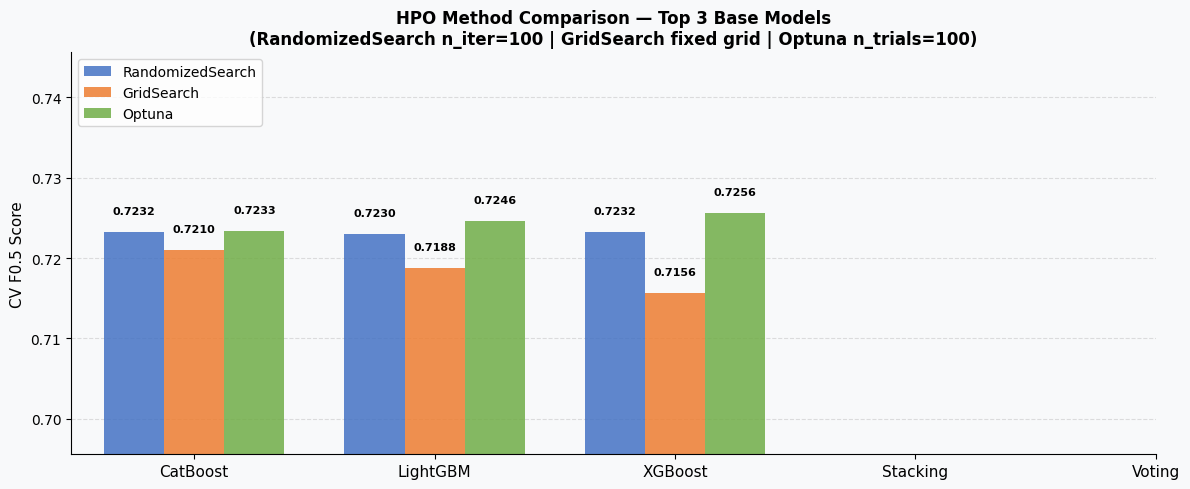


📌 Best HPO method per model:
   CatBoost             Best method: Optuna             F0.5=0.7233
   LightGBM             Best method: Optuna             F0.5=0.7246
   XGBoost              Best method: Optuna             F0.5=0.7256
   Stacking             Best method: Inherited          F0.5=0.7241 ← sub-estimator pakai best HPO params
   Voting               Best method: Inherited          F0.5=0.7232 ← sub-estimator pakai best HPO params

⏳ Winner belum dipilih — lanjut ke 8.6 untuk build pipelines, 8.7 untuk threshold tuning


In [ ]:
# ============================================================================
# 8.5 PERBANDINGAN TIGA METODE HPO
# ============================================================================

# Gabungkan base + ensemble sebagai sumber CV score fallback
cv_score_map = pd.concat([cv_base_df, cv_ensemble_df]) \
                 .groupby("base_model")["f0.5_mean"].max() \
                 .to_dict()

comparison_rows = []

# ── Base models (TOP3_NAMES) — ikut HPO ──────────────────────────────
for model_name in TOP3_NAMES:
    row = {"model": model_name}

    row["rand_f0.5"]     = rand_results[model_name]["best_score"]   if model_name in rand_results else np.nan
    row["rand_time_min"] = rand_results[model_name]["time_minutes"] if model_name in rand_results else np.nan

    row["grid_f0.5"]       = grid_results[model_name]["best_score"]   if model_name in grid_results else np.nan
    row["grid_candidates"] = grid_results[model_name]["n_candidates"] if model_name in grid_results else np.nan
    row["grid_time_min"]   = grid_results[model_name]["time_minutes"] if model_name in grid_results else np.nan

    row["optuna_f0.5"]     = hpo_results[model_name]["best_score"]   if model_name in hpo_results else np.nan
    row["optuna_time_min"] = hpo_results[model_name]["time_minutes"] if model_name in hpo_results else np.nan

    scores       = {
        "RandomizedSearch": row["rand_f0.5"],
        "GridSearch":       row["grid_f0.5"],
        "Optuna":           row["optuna_f0.5"],
    }
    valid_scores = {k: v for k, v in scores.items() if not np.isnan(v)}
    row["best_method"] = max(valid_scores, key=valid_scores.get) if valid_scores else "Default"
    row["best_f0.5"]   = max(valid_scores.values()) if valid_scores else cv_score_map.get(model_name, np.nan)

    comparison_rows.append(row)

# Di Section 8.5, ganti bagian ensemble rows
for model_name in cv_ensemble_df["base_model"].tolist():
    comparison_rows.append({
        "model":           model_name,
        "rand_f0.5":       np.nan,
        "rand_time_min":   np.nan,
        "grid_f0.5":       np.nan,
        "grid_candidates": np.nan,
        "grid_time_min":   np.nan,
        "optuna_f0.5":     np.nan,
        "optuna_time_min": np.nan,
        "best_method":     "Inherited",   # ← bukan "Default"
        "best_f0.5":       cv_score_map.get(model_name, np.nan),
    })

comparison_df = pd.DataFrame(comparison_rows)
print("=" * 80)
print("HPO COMPARISON: RandomizedSearch vs GridSearch vs Optuna")
print("=" * 80)
display(comparison_df)

# Visualisasi — hanya model yang di-HPO
hpo_df = comparison_df[comparison_df["best_method"] != "Default"].reset_index(drop=True)

if not hpo_df.empty:
    fig, ax = plt.subplots(figsize=(12, 5))
    fig.patch.set_facecolor("#f8f9fa")
    ax.set_facecolor("#f8f9fa")

    x = np.arange(len(hpo_df))
    w = 0.25

    ax.bar(x - w, hpo_df["rand_f0.5"],   w, label="RandomizedSearch", color="#4472C4", alpha=0.85)
    ax.bar(x,     hpo_df["grid_f0.5"],   w, label="GridSearch",       color="#ED7D31", alpha=0.85)
    ax.bar(x + w, hpo_df["optuna_f0.5"], w, label="Optuna",           color="#70AD47", alpha=0.85)

    for i, row in hpo_df.iterrows():
        for val, offset in zip(
            [row["rand_f0.5"], row["grid_f0.5"], row["optuna_f0.5"]], [-w, 0, w]
        ):
            if not np.isnan(val):
                ax.text(i + offset, val + 0.002, f"{val:.4f}",
                        ha="center", va="bottom", fontsize=8, fontweight="bold")

    ax.set_xticks(range(len(hpo_df)))
    ax.set_xticklabels(hpo_df["model"].tolist(), fontsize=11)
    ax.set_ylabel("CV F0.5 Score", fontsize=11)
    ax.set_title(
        "HPO Method Comparison — Top 3 Base Models\n"
        "(RandomizedSearch n_iter=100 | GridSearch fixed grid | Optuna n_trials=100)",
        fontsize=12, fontweight="bold",
    )
    ax.legend(fontsize=10)
    ax.spines[["top", "right"]].set_visible(False)
    ax.yaxis.grid(True, linestyle="--", alpha=0.4)
    ax.set_axisbelow(True)
    valid_vals = hpo_df[["rand_f0.5","grid_f0.5","optuna_f0.5"]].stack().dropna()
    ax.set_ylim(valid_vals.min() - 0.02, valid_vals.max() + 0.02)
    plt.tight_layout()
    plt.savefig(f"{ARTIFACT_DIR}hpo_comparison_v4.png", dpi=150,
                bbox_inches="tight", facecolor=fig.get_facecolor())
    plt.show()

print("\n📌 Best HPO method per model:")
for _, row in comparison_df.iterrows():
    note = " ← sub-estimator pakai best HPO params" if row["best_method"] == "Inherited" else ""
    print(f"   {row['model']:<20} Best method: {row['best_method']:<18} F0.5={row['best_f0.5']:.4f}{note}")
print("\n⏳ Winner belum dipilih — lanjut ke 8.6 untuk build pipelines, 8.7 untuk threshold tuning")

**HPO Method Comparison — RandomizedSearch vs GridSearch vs Optuna**

Hyperparameter Optimization (HPO) dilakukan untuk menemukan kombinasi parameter terbaik bagi tiga base model (CatBoost, LightGBM, XGBoost). Tiga metode dibandingkan secara langsung dengan jumlah iterasi yang setara (n=100 untuk RandomizedSearch dan Optuna, fixed grid untuk GridSearch).

**Hasil perbandingan:**

| Model | RandomizedSearch | GridSearch | Optuna | Best Method |
|-------|-----------------|------------|--------|-------------|
| CatBoost | 0.7232 | 0.7210 | **0.7233** | Optuna |
| LightGBM | 0.7230 | 0.7188 | **0.7246** | Optuna |
| XGBoost | 0.7232 | 0.7156 | **0.7256** | Optuna |

Optuna **konsisten menjadi metode terbaik di semua model** tanpa terkecuali. GridSearch justru menjadi yang terburuk di setiap model, bahkan di bawah RandomizedSearch yang jauh lebih sederhana.

---

**Mengapa Optuna lebih unggul dari keduanya?**

**GridSearch** mencari secara sistematis di seluruh kombinasi parameter yang sudah ditentukan sebelumnya dalam grid tetap. Masalahnya, grid yang didesain manusia hampir tidak pernah mencakup kombinasi optimal — terutama untuk model kompleks seperti LightGBM dan XGBoost yang memiliki puluhan hyperparameter dengan interaksi non-linear antar parameternya. GridSearch menghabiskan banyak waktu mengeksplorasi kombinasi yang tidak menjanjikan karena tidak ada mekanisme untuk "belajar" dari hasil sebelumnya.

**RandomizedSearch** lebih efisien karena mengambil sampel acak dari ruang parameter, sehingga bisa mengeksplorasi area yang lebih luas dalam jumlah iterasi yang sama. Namun kelemahannya: setiap trial sepenuhnya acak dan tidak memanfaatkan informasi dari trial sebelumnya — tidak ada pembelajaran adaptif.

**Optuna** menggunakan pendekatan yang fundamental berbeda: **Bayesian Optimization berbasis Tree-structured Parzen Estimator (TPE)**. Setiap trial baru tidak dipilih secara acak, melainkan dipandu oleh model probabilistik yang dibangun dari hasil trial-trial sebelumnya. Optuna "belajar" area mana di ruang parameter yang menjanjikan dan area mana yang tidak perlu dieksplorasi lagi — semakin banyak trial, semakin cerdas pencariannya. Hasilnya: dalam jumlah iterasi yang sama (100 trial), Optuna mengeksplorasi ruang parameter jauh lebih efisien dan menemukan kombinasi yang lebih baik.

**Stacking dan Voting** tidak melalui HPO secara langsung — keduanya menggunakan metode **Inherited**, di mana parameter base estimator-nya (LightGBM, XGBoost, CatBoost) langsung menggunakan hasil terbaik dari Optuna. Ini adalah keputusan yang tepat karena HPO pada level Stacking akan sangat mahal secara komputasi, sementara kualitas base estimator yang sudah dioptimasi Optuna sudah cukup untuk menghasilkan Stacking yang kompetitif.

In [ ]:
# ============================================================================
# 8.6 BUILD BEST PIPELINES PER MODEL
# ============================================================================
import numpy as np

BASE_MAP = {
    "RandomForest":       RandomForestClassifier(random_state=SEED, n_jobs=-1),
    "CatBoost":           CatBoostClassifier(random_state=SEED, verbose=False),
    "LightGBM":           LGBMClassifier(random_state=SEED, n_jobs=-1, verbose=-1),
    "XGBoost":            XGBClassifier(random_state=SEED, n_jobs=-1, eval_metric="logloss", verbosity=0),
    "LogisticRegression": LogisticRegression(max_iter=1000, random_state=SEED, n_jobs=-1),
}

def sanitize_params(params):
    """Konversi numpy scalar → Python native type agar kompatibel dengan clone()."""
    clean = {}
    for k, v in params.items():
        if isinstance(v, np.integer):    clean[k] = int(v)
        elif isinstance(v, np.floating): clean[k] = float(v)
        elif isinstance(v, np.bool_):    clean[k] = bool(v)
        else:                            clean[k] = v
    return clean

def rebuild_base_model(model_name, method_map):
    """
    Rebuild satu base model dengan best params dari HPO.
    method_map: dict {model_name: best_method} dari comparison_df.
    """
    if model_name not in BASE_MAP:
        raise ValueError(f"'{model_name}' tidak ada di BASE_MAP")

    method = method_map.get(model_name, "Default")

    if method == "RandomizedSearch" and model_name in rand_results:
        best_params = rand_results[model_name]["best_estimator"].get_params()
        base_known  = set(BASE_MAP[model_name].get_params().keys())
        filtered    = sanitize_params({k: v for k, v in best_params.items() if k in base_known})
        m = clone(BASE_MAP[model_name])
        m.set_params(**filtered)
        return m

    elif method == "GridSearch" and model_name in grid_results:
        best_params = grid_results[model_name]["best_estimator"].get_params()
        base_known  = set(BASE_MAP[model_name].get_params().keys())
        filtered    = sanitize_params({k: v for k, v in best_params.items() if k in base_known})
        m = clone(BASE_MAP[model_name])
        m.set_params(**filtered)
        return m

    elif method == "Optuna" and model_name in hpo_results:
        best_params  = hpo_results[model_name]["best_params"]
        clean_params = sanitize_params({k.replace("model__", ""): v for k, v in best_params.items()})
        m = clone(BASE_MAP[model_name])
        m.set_params(**clean_params)
        return m

    else:
        # Inherited — sub-estimator pakai parameter dari MODELS_NONE (default)
        return clone(ALL_BASE_MODELS[model_name]) if model_name in ALL_BASE_MODELS \
               else clone(BASE_MAP[model_name])

def get_best_pipeline(model_name, method, method_map):
    """Kembalikan unfitted pipeline terbaik — base model, Voting, atau Stacking."""

    # ── Base models ──────────────────────────────────────────────────────────
    if model_name in BASE_MAP:
        m = rebuild_base_model(model_name, method_map)
        return ImbPipeline([("preprocessor", preprocessor), ("model", m)])

    # ── Voting Classifier ─────────────────────────────────────────────────────
    elif model_name == "Voting":
        # Sub-estimator Voting: RF + CatBoost + LightGBM (sesuai MODELS_NONE)
        estimators = [
            ("rf",  rebuild_base_model("RandomForest", method_map)),
            ("cat", rebuild_base_model("CatBoost",     method_map)),
            ("lgb", rebuild_base_model("LightGBM",     method_map)),
        ]
        m = VotingClassifier(estimators=estimators, voting="soft", n_jobs=-1)
        return ImbPipeline([("preprocessor", preprocessor), ("model", m)])

    # ── Stacking Classifier ───────────────────────────────────────────────────
    elif model_name == "Stacking":
        # Sub-estimator Stacking: RF + CatBoost + LightGBM + XGBoost (sesuai MODELS_NONE)
        estimators = [
            ("rf",  rebuild_base_model("RandomForest",       method_map)),
            ("cat", rebuild_base_model("CatBoost",           method_map)),
            ("lgb", rebuild_base_model("LightGBM",           method_map)),
            ("xgb", rebuild_base_model("XGBoost",            method_map)),
        ]
        meta_learner = rebuild_base_model("LogisticRegression", method_map)
        m = StackingClassifier(
            estimators=estimators,
            final_estimator=meta_learner,
            cv=5, n_jobs=-1,
        )
        return ImbPipeline([("preprocessor", preprocessor), ("model", m)])

    else:
        raise ValueError(f"Model '{model_name}' tidak dikenali.")

# Build semua pipeline
method_map    = comparison_df.set_index("model")["best_method"].to_dict()
best_pipelines = {}

for _, row in comparison_df.iterrows():
    name, method = row["model"], row["best_method"]
    best_pipelines[name] = get_best_pipeline(name, method, method_map)
    note = " (sub-estimator pakai best HPO params)" if method == "Inherited" else f" (via {method})"
    print(f"   {name:<20}{note}")

print(f"\n✅ {len(best_pipelines)} pipelines ready (semua unfitted)")
print("   Threshold tuning & pemilihan winner → Section 8.7")

   CatBoost             (via Optuna)
   LightGBM             (via Optuna)
   XGBoost              (via Optuna)
   Stacking             (sub-estimator pakai best HPO params)
   Voting               (sub-estimator pakai best HPO params)

✅ 5 pipelines ready (semua unfitted)
   Threshold tuning & pemilihan winner → Section 8.7


In [ ]:
# ============================================================================
# 8.7 OOF THRESHOLD TUNING → PILIH WINNER → FINAL EVAL X_TEST
# ============================================================================
OOF_TUNED_CHECKPOINT = f"{ARTIFACT_DIR}oof_tuned_v5.pkl"

if os.path.exists(OOF_TUNED_CHECKPOINT):
    oof_probs_tuned = joblib.load(OOF_TUNED_CHECKPOINT)
    print(f"📦 Loaded tuned OOF: {len(oof_probs_tuned)} model")
else:
    oof_probs_tuned = {}

# ── STEP 1: Generate OOF probabilities ──────────────────────────────
for model_name, pipe in best_pipelines.items():
    if model_name in oof_probs_tuned:
        print(f"⏭  {model_name} — cached")
        continue
    t0 = time.time()
    try:
        oof = cross_val_predict(
            clone(pipe), X_train, y_train,
            cv=skf, method="predict_proba", n_jobs=1,
        )
        oof_probs_tuned[model_name] = oof[:, 1]
        joblib.dump(oof_probs_tuned, OOF_TUNED_CHECKPOINT)
        print(f"✅ {model_name:<20} OOF done — {time.time()-t0:.1f}s")
    except Exception as e:
        print(f"❌ {model_name}: {e}")

# ── STEP 2: Threshold Sweep per model ───────────────────────────────
print("\n=== Threshold Sweep per Model ===")
threshold_sweep_rows = []

for model_name, oof_proba in oof_probs_tuned.items():
    sweep_df    = sweep_thresholds(y_train, oof_proba)
    optimal_row = sweep_df.loc[sweep_df["f0.5"].idxmax()]
    default_row = sweep_df[sweep_df["threshold"] == DEFAULT_T].iloc[0]

    threshold_sweep_rows.append({
        "model":             model_name,
        "hpo_method":        method_map.get(model_name, "Default"),
        "threshold_default": DEFAULT_T,
        "oof_f0.5_default":  default_row["f0.5"],
        "threshold_optimal": optimal_row["threshold"],
        "oof_f0.5_optimal":  optimal_row["f0.5"],
        "oof_precision":     optimal_row["precision"],
        "oof_recall":        optimal_row["recall"],
        "gain_f0.5":         round(optimal_row["f0.5"] - default_row["f0.5"], 4),
    })

threshold_df = (
    pd.DataFrame(threshold_sweep_rows)
    .sort_values("oof_f0.5_optimal", ascending=False)
    .reset_index(drop=True)
)
display(threshold_df)

# ── STEP 3: Pilih winner dari OOF (bukan test — hindari leakage) ────
winner_row       = threshold_df.iloc[0]
WINNER_MODEL     = winner_row["model"]
WINNER_THRESHOLD = float(winner_row["threshold_optimal"])
WINNER_HPO       = method_map.get(WINNER_MODEL, "Default")

print(f"\n🏆 WINNER (berdasarkan OOF F0.5): {WINNER_MODEL}")
print(f"   HPO method       : {WINNER_HPO}")
print(f"   Threshold optimal: {WINNER_THRESHOLD}")
print(f"   OOF F0.5 default : {winner_row['oof_f0.5_default']:.4f}")
print(f"   OOF F0.5 optimal : {winner_row['oof_f0.5_optimal']:.4f}")

# ── STEP 4: Fit semua model di full X_train → eval train + test ─────
print("\n=== Final Evaluation (Train + Test) ===")
threshold_map      = threshold_df.set_index("model")["threshold_optimal"].to_dict()
test_results_tuned = {}
fitted_pipelines   = {}

for model_name, pipe in best_pipelines.items():
    t0          = time.time()
    fitted_pipe = clone(pipe)
    fitted_pipe.fit(X_train, y_train)
    fitted_pipelines[model_name] = fitted_pipe

    optimal_t = float(threshold_map[model_name])

    # ── Train score (threshold optimal, konsisten dengan test) ───────
    # Catatan: nilai ini akan lebih tinggi dari OOF/test karena model
    # mengevaluasi data yang sama yang dipakai untuk fit — hanya informatif
    proba_train  = fitted_pipe.predict_proba(X_train)[:, 1]
    pred_train   = (proba_train >= optimal_t).astype(int)
    f05_train    = round(fbeta_score(y_train, pred_train, beta=0.5, zero_division=0), 4)

    # ── Test score ────────────────────────────────────────────────────
    proba_test   = fitted_pipe.predict_proba(X_test)[:, 1]
    pred_default = (proba_test >= DEFAULT_T).astype(int)
    pred_tuned   = (proba_test >= optimal_t).astype(int)

    f05_def = round(fbeta_score(y_test, pred_default, beta=0.5, zero_division=0), 4)
    f05_opt = round(fbeta_score(y_test, pred_tuned,   beta=0.5, zero_division=0), 4)

    elapsed = time.time() - t0

    test_results_tuned[model_name] = {
        "hpo_method":             method_map.get(model_name, "Default"),
        "threshold_optimal":      optimal_t,
        "f0.5_train":             f05_train,
        "f0.5_test_default":      f05_def,
        "f0.5_test_optimal":      f05_opt,
        "precision_test_optimal": round(precision_score(y_test, pred_tuned, zero_division=0), 4),
        "recall_test_optimal":    round(recall_score(y_test, pred_tuned, zero_division=0), 4),
        "gain_f0.5_test":         round(f05_opt - f05_def, 4),
        "time_fit_seconds":       round(elapsed, 1),
    }

    marker = " ← WINNER" if model_name == WINNER_MODEL else ""
    print(f"{model_name:<15} Train={f05_train:.4f} | "
          f"OOF={threshold_df.loc[threshold_df.model==model_name,'oof_f0.5_optimal'].values[0]:.4f} | "
          f"Test={f05_opt:.4f}{marker}")

# ── STEP 5: Tampilkan tabel hasil lengkap ────────────────────────────
test_df_tuned = (
    pd.DataFrame([{"model": k, **v} for k, v in test_results_tuned.items()])
    .sort_values("f0.5_test_optimal", ascending=False)
    .reset_index(drop=True)
)
print("\n=== X_test Evaluation — Semua Tuned Models ===")
display(test_df_tuned)

# ── STEP 6: Konfirmasi final winner ──────────────────────────────────
# Winner tetap mengacu OOF, bukan test, untuk hindari test-set leakage
final_winner    = test_df_tuned[test_df_tuned["model"] == WINNER_MODEL].iloc[0]
final_pipeline  = fitted_pipelines[WINNER_MODEL]
final_threshold = WINNER_THRESHOLD

print(f"\n{'='*60}")
print(f"  FINAL WINNER  : {WINNER_MODEL}")
print(f"  HPO Method    : {WINNER_HPO}")
print(f"  Threshold     : {final_threshold}  (dipilih dari OOF)")
print(f"  Train F0.5    : {final_winner['f0.5_train']:.4f} ")
print(f"  OOF F0.5      : {winner_row['oof_f0.5_optimal']:.4f}  (estimasi generalisasi)")
print(f"  Test F0.5     : {final_winner['f0.5_test_optimal']:.4f}  (konfirmasi final)")
print(f"  Test Precision: {final_winner['precision_test_optimal']:.4f}")
print(f"  Test Recall   : {final_winner['recall_test_optimal']:.4f}")
print(f"  Overfit check : OOF={winner_row['oof_f0.5_optimal']:.4f} vs "
      f"Test={final_winner['f0.5_test_optimal']:.4f} → "
      f"gap={winner_row['oof_f0.5_optimal'] - final_winner['f0.5_test_optimal']:+.4f}")
print(f"{'='*60}")

# ── STEP 7: Save ─────────────────────────────────────────────────────
joblib.dump({
    "pipeline":      final_pipeline,
    "model_name":    WINNER_MODEL,
    "hpo_method":    WINNER_HPO,
    "threshold":     final_threshold,
    "train_f0.5":    float(final_winner["f0.5_train"]),
    "oof_f0.5":      float(winner_row["oof_f0.5_optimal"]),
    "test_f0.5":     float(final_winner["f0.5_test_optimal"]),
    "precision":     float(final_winner["precision_test_optimal"]),
    "recall":        float(final_winner["recall_test_optimal"]),
    "threshold_df":  threshold_df,
    "test_df":       test_df_tuned,
}, f"{ARTIFACT_DIR}final_model_v5.pkl")
print(f"\n✅ Saved: {ARTIFACT_DIR}final_model_v5.pkl")

# ── STEP 8: Pastikan proba_test dari WINNER untuk section 9.x ────────
proba_test  = fitted_pipelines[WINNER_MODEL].predict_proba(X_test)[:, 1]
y_pred_test = (proba_test >= final_threshold).astype(int)
print(f"✅ proba_test di-set dari: {WINNER_MODEL} (t={final_threshold})")

📦 Loaded tuned OOF: 5 model
⏭  CatBoost — cached
⏭  LightGBM — cached
⏭  XGBoost — cached
⏭  Stacking — cached
⏭  Voting — cached

=== Threshold Sweep per Model ===


,model,hpo_method,threshold_default,oof_f0.5_default,threshold_optimal,oof_f0.5_optimal,oof_precision,oof_recall,gain_f0.5
0,Stacking,Inherited,0.5,0.7259,0.60,0.7337,0.7811,0.5903,0.0078
1,Voting,Inherited,0.5,0.7253,0.58,0.7322,0.7904,0.5657,0.0069
2,LightGBM,Optuna,0.5,0.7245,0.58,0.7318,0.7828,0.5807,0.0073
3,XGBoost,Optuna,0.5,0.7255,0.56,0.7301,0.7745,0.5941,0.0046
4,CatBoost,Optuna,0.5,0.7233,0.57,0.7290,0.7774,0.5839,0.0057



🏆 WINNER (berdasarkan OOF F0.5): Stacking
   HPO method       : Inherited
   Threshold optimal: 0.6
   OOF F0.5 default : 0.7259
   OOF F0.5 optimal : 0.7337

=== Final Evaluation (Train + Test) ===
CatBoost        Train=0.8082 | OOF=0.7290 | Test=0.7363
LightGBM        Train=0.8382 | OOF=0.7318 | Test=0.7420
XGBoost         Train=0.8500 | OOF=0.7301 | Test=0.7402
Stacking        Train=0.8703 | OOF=0.7337 | Test=0.7415 ← WINNER
Voting          Train=0.9225 | OOF=0.7322 | Test=0.7417

=== X_test Evaluation — Semua Tuned Models ===


,model,hpo_method,threshold_optimal,f0.5_train,f0.5_test_default,f0.5_test_optimal,precision_test_optimal,recall_test_optimal,gain_f0.5_test,time_fit_seconds
0,LightGBM,Optuna,0.58,0.8382,0.7371,0.7420,0.7918,0.5929,0.0049,11.9
1,Voting,Inherited,0.58,0.9225,0.7381,0.7417,0.7972,0.5802,0.0036,19.4
2,Stacking,Inherited,0.60,0.8703,0.7390,0.7415,0.7849,0.6073,0.0025,77.8
3,XGBoost,Optuna,0.56,0.8500,0.7353,0.7402,0.7831,0.6073,0.0049,2.2
4,CatBoost,Optuna,0.57,0.8082,0.7322,0.7363,0.7810,0.5991,0.0041,10.1



  FINAL WINNER  : Stacking
  HPO Method    : Inherited
  Threshold     : 0.6  (dipilih dari OOF)
  Train F0.5    : 0.8703 
  OOF F0.5      : 0.7337  (estimasi generalisasi)
  Test F0.5     : 0.7415  (konfirmasi final)
  Test Precision: 0.7849
  Test Recall   : 0.6073
  Overfit check : OOF=0.7337 vs Test=0.7415 → gap=-0.0078

✅ Saved: artifacts_v4/final_model_v5.pkl
✅ proba_test di-set dari: Stacking (t=0.6)




**Train F0.5** adalah skor yang dihasilkan ketika model diminta memprediksi data yang sama persis dengan data yang dipakai untuk melatihnya. Angka ini akan selalu lebih tinggi dari kenyataan karena model menjawab "soal yang sudah pernah dilihat". Stacking mencatat Train F0.5 sebesar 0.8703, sementara Voting bahkan mencapai 0.9225. Angka-angka ini bukan cerminan kemampuan sebenarnya — melainkan hanya menunjukkan seberapa baik model menghafal data latihan. Namun angka ini tetap berguna sebagai referensi: jika train score rendah, itu pertanda model bahkan tidak mampu mempelajari pola dari data yang diberikan kepadanya (underfitting).

**OOF F0.5** (Out-of-Fold) adalah estimasi yang jauh lebih jujur. Melalui mekanisme cross-validation, setiap observasi di X_train diprediksi oleh model yang tidak pernah melihatnya selama proses pelatihan. Ini menghilangkan efek "menghafal" dan memberikan gambaran yang lebih realistis tentang kemampuan generalisasi model. Stacking mencatat OOF F0.5 sebesar 0.7337 — tertinggi di antara semua model. Angka inilah yang dijadikan dasar pemilihan winner, bukan train score dan bukan test score.

**Test F0.5** adalah konfirmasi terakhir pada data yang benar-benar belum pernah dilihat model dalam bentuk apapun — tidak saat training, tidak saat cross-validation, tidak saat threshold tuning. Stacking mencatat Test F0.5 sebesar 0.7415. Fakta bahwa angka ini sedikit lebih tinggi dari OOF (gap = -0.0078) adalah sinyal yang sangat positif: model tidak hanya tidak overfit, tetapi bahkan sedikit lebih baik pada data baru dibanding estimasi awalnya.

---

**Analisis Overfitting & Underfitting**

Secara umum, cara paling intuitif untuk mendeteksi overfitting adalah dengan membandingkan Train F0.5 dan Test F0.5. Dari hasil di atas, gap yang terlihat memang cukup besar — Stacking mencatat Train F0.5 = 0.8703 vs Test F0.5 = 0.7415, selisih 0.1288. Jika hanya melihat angka ini, kesimpulan pertama yang muncul adalah model overfit.

Namun perbandingan Train vs Test saja tidak cukup akurat untuk menilai overfitting, karena Train score memang **selalu** lebih tinggi secara struktural — model memprediksi data yang sama persis dengan yang dipakai untuk melatihnya, sehingga ia menjawab "soal yang sudah pernah dilihat". Gap Train-Test yang besar adalah fenomena normal, bukan bukti overfitting.

Ukuran yang jauh lebih jujur adalah **OOF (Out-of-Fold) vs Test**. OOF menghasilkan prediksi pada setiap observasi training menggunakan model yang tidak pernah melihat data tersebut saat dilatih — mekanisme yang secara langsung mensimulasikan kondisi data baru. Stacking mencatat OOF F0.5 = 0.7337 vs Test F0.5 = 0.7415, dengan gap hanya **-0.0078**. Gap negatif berarti performa di data test justru sedikit lebih baik dari estimasi OOF — arah yang berlawanan total dari overfitting.

Pola ini konsisten di seluruh lima model yang dievaluasi: semua mencatat gap OOF-Test yang kecil dan negatif (LightGBM -0.0102, XGBoost -0.0101, Voting -0.0095, CatBoost -0.0073). Konsistensi ini mengonfirmasi bahwa **tidak ada overfitting maupun underfitting** — pipeline preprocessing dan feature engineering yang dibangun menghasilkan representasi data yang solid dan dapat digeneralisasi dengan stabil ke data booking yang belum pernah dilihat model sebelumnya.

---

> Pola yang Muncul dari Kelima Model

Jika kita melihat kelima model secara bersamaan, ada pola yang menarik dan konsisten.

Pertama, **semua model menunjukkan gap OOF-Test yang negatif** — artinya test score sedikit lebih tinggi dari OOF di setiap model tanpa terkecuali. CatBoost (gap -0.0073), LightGBM (-0.0102), XGBoost (-0.0101), Stacking (-0.0078), dan Voting (-0.0095). Ini menunjukkan bahwa pipeline preprocessing dan feature engineering yang dibangun sudah sangat solid — tidak ada model yang "kebetulan" bagus di OOF tapi gagal di test. Semua generalisasi dengan stabil.

Kedua, **urutan ranking berubah antara OOF dan test**. Di OOF, Stacking menang (0.7337), diikuti Voting (0.7322) dan LightGBM (0.7318). Namun di test, LightGBM justru memimpin (0.7420), diikuti Voting (0.7417) dan baru Stacking (0.7415). Perbedaannya sangat tipis — hanya 0.0005 antara model pertama dan ketiga. Ini menunjukkan bahwa ketiga model teratas memiliki kemampuan prediktif yang hampir identik pada data baru, dan pemilihan winner berdasarkan OOF (bukan test) adalah keputusan metodologis yang tepat untuk menghindari test-set leakage.

Ketiga, **threshold optimal berbeda-beda antar model**. CatBoost optimal di 0.57, LightGBM dan Voting di 0.58, XGBoost di 0.56, dan Stacking di 0.60. Threshold yang lebih tinggi pada Stacking (0.60) menunjukkan bahwa Stacking menghasilkan probabilitas yang lebih terkalibrasi — model lebih "percaya diri" dalam membedakan kelas positif dan negatif, sehingga membutuhkan threshold yang lebih tinggi untuk mencapai keseimbangan precision-recall yang optimal.

---
> Mengapa Stacking Dipilih sebagai Winner

Keputusan memilih Stacking sebagai winner didasarkan pada beberapa pertimbangan yang melampaui sekadar angka F0.5.

**Pertimbangan pertama: OOF F0.5 tertinggi.** Stacking mencatat 0.7337, mengungguli semua base estimator individual. Ini bukan kebetulan — ini adalah konsekuensi langsung dari arsitektur Stacking yang mampu mengkombinasikan kekuatan prediktif dari beberapa model sekaligus. Ketika LightGBM salah memprediksi sebuah observasi tapi CatBoost benar, meta-learner Stacking belajar untuk lebih mempercayai CatBoost pada pola data semacam itu. Hasilnya: kesalahan yang dihasilkan oleh satu model dikompensasi oleh model lain.

**Pertimbangan kedua: stabilitas generalisasi.** Gap OOF-Test Stacking adalah -0.0078, yang berarti test score justru sedikit lebih baik dari estimasi OOF. Ini menandakan model yang sangat stabil — tidak ada tanda-tanda overfitting meskipun arsitekturnya lebih kompleks dari base estimator individual.

**Pertimbangan ketiga: threshold tuning gain tertinggi.** Stacking mencatat gain F0.5 sebesar 0.0078 dari threshold default (0.5) ke threshold optimal (0.6) — gain tertinggi di antara semua model. Ini menunjukkan bahwa distribusi probabilitas yang dihasilkan Stacking memiliki ruang optimasi yang lebih besar, dan threshold tuning memberikan dampak yang lebih signifikan dibanding pada model lain.

---
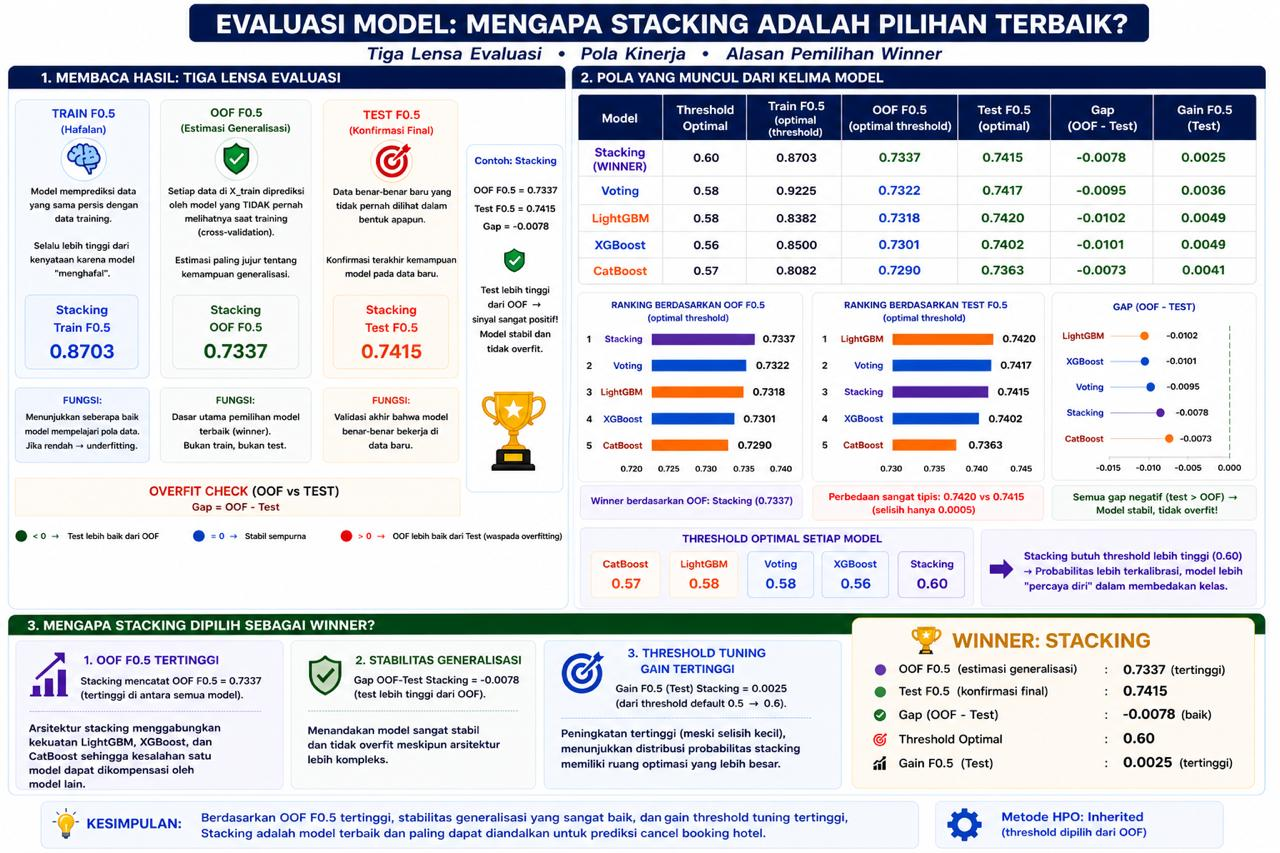
---

> Bagaimana Stacking Bekerja: Dari Dasar Hingga Detail

> 1 Intuisi Dasar: Wisdom of Crowds

Konsep di balik Stacking berakar pada prinsip yang dikenal sebagai "wisdom of crowds" — gagasan bahwa keputusan kolektif dari sekelompok individu yang beragam cenderung lebih baik dari keputusan individu terbaik sekalipun. Dalam konteks machine learning, "individu" di sini adalah model-model yang berbeda, masing-masing dengan kekuatan dan kelemahannya sendiri.

LightGBM, XGBoost, dan CatBoost — meskipun sama-sama berbasis gradient boosting — memiliki perbedaan fundamental dalam cara mereka memproses data. LightGBM menggunakan strategi leaf-wise tree growth yang agresif, membuat keputusan split berdasarkan gain informasi tertinggi di seluruh tree. XGBoost menggunakan level-wise growth yang lebih konservatif, membangun tree secara merata di setiap kedalaman. CatBoost memiliki penanganan fitur kategorikal yang unik melalui ordered target statistics dan ordered boosting yang mengurangi prediction shift. Perbedaan-perbedaan arsitektural ini menyebabkan ketiga model membuat kesalahan pada observasi yang berbeda-beda — dan inilah yang dieksploitasi oleh Stacking.

> 4.2 Arsitektur Dua Lapis

Stacking terdiri dari dua lapis yang masing-masing memiliki peran yang sangat berbeda.

**Layer 0 (Base Estimators)** terdiri dari tiga model independen: LightGBM, XGBoost, dan CatBoost. Masing-masing model ini menerima fitur asli dari dataset — `lead_time`, `country_grouped`, `agent`, `adr`, `total_of_special_requests`, dan seterusnya — lalu mempelajari pola-pola yang mengarah pada pembatalan hotel. Setiap model menghasilkan satu output: probabilitas bahwa sebuah booking akan dibatalkan.

```
Fitur Asli (26 fitur setelah preprocessing):
  lead_time, agent, country_grouped, adr,
  total_of_special_requests, market_segment, ...
         │
    ┌────┼────────────────┐
    │    │                │
    ▼    ▼                ▼
 LightGBM  XGBoost    CatBoost     ← Layer 0
    │        │            │
    ▼        ▼            ▼
  P_lgbm   P_xgb       P_cat       ← Probabilitas cancel (0-1)
  0.72     0.68        0.75        ← contoh untuk satu observasi
```

Yang penting dipahami: ketiga model ini dilatih secara **independen dan paralel**. Mereka tidak berkomunikasi satu sama lain dan tidak tahu apa yang diprediksi oleh model lain. Masing-masing membentuk "pandangan" sendiri tentang apakah sebuah booking akan dibatalkan.

**Layer 1 (Meta-Learner)** adalah model yang lebih sederhana — biasanya Logistic Regression — yang menerima **output dari Layer 0** sebagai inputnya. Meta-learner tidak pernah melihat fitur asli dataset. Yang dilihatnya hanyalah tiga angka: probabilitas dari LightGBM, probabilitas dari XGBoost, dan probabilitas dari CatBoost.

```
  P_lgbm   P_xgb   P_cat
  0.72     0.68    0.75
    │        │       │
    └────┬───┘───────┘
         │
    Meta-Learner (Logistic Regression)
         │
         ▼
    P_final = 0.73   ← Prediksi akhir Stacking
```

Tugas meta-learner bukan mempelajari pola pembatalan hotel — itu sudah dilakukan oleh base estimators. Tugas meta-learner adalah belajar **bagaimana cara terbaik menggabungkan dan menimbang** output ketiga model. Misalnya, meta-learner mungkin belajar bahwa:
- Ketika LightGBM dan CatBoost setuju tapi XGBoost tidak, biasanya LightGBM dan CatBoost yang benar
- Untuk observasi dengan probabilitas rendah (< 0.3), CatBoost paling akurat
- Untuk observasi dengan probabilitas tinggi (> 0.7), ketiga model sama baiknya

Pembelajaran semacam ini tidak mungkin dilakukan oleh simple averaging (yang digunakan Voting) — Voting hanya menghitung rata-rata tanpa mempertimbangkan konteks.

> 3 Training dengan Cross-Validation Internal

Ada satu masalah krusial dalam melatih Stacking: jika base estimators dilatih pada seluruh X_train, lalu outputnya digunakan untuk melatih meta-learner, maka meta-learner akan belajar dari prediksi yang "terlalu bagus" — karena base estimators memprediksi data yang sudah pernah mereka lihat. Ini akan menyebabkan overfitting yang parah.

Solusinya adalah **cross-validation internal** dalam proses training Stacking. Prosesnya sebagai berikut:

```
X_train dibagi menjadi K fold (misalnya 5):
┌─────┬─────┬─────┬─────┬─────┐
│ F1  │ F2  │ F3  │ F4  │ F5  │
└─────┴─────┴─────┴─────┴─────┘

Untuk setiap base estimator (misal LightGBM):

Iterasi 1: fit di [F2,F3,F4,F5] → predict F1
Iterasi 2: fit di [F1,F3,F4,F5] → predict F2
Iterasi 3: fit di [F1,F2,F4,F5] → predict F3
Iterasi 4: fit di [F1,F2,F3,F5] → predict F4
Iterasi 5: fit di [F1,F2,F3,F4] → predict F5

→ Gabungkan prediksi F1-F5 → OOF predictions LightGBM
→ Ulangi untuk XGBoost dan CatBoost

Hasilnya: 3 kolom OOF predictions (satu per base estimator)
→ Inilah yang dipakai untuk melatih meta-learner
```

Dengan mekanisme ini, meta-learner belajar dari prediksi yang **jujur** — setiap prediksi dihasilkan oleh model yang tidak pernah melihat data tersebut saat training. Ini mencegah overfitting pada level Stacking dan menghasilkan ensemble yang stabil.

> 4 Inference (Saat Prediksi Data Baru)

Saat model sudah dilatih dan menerima data baru (misalnya booking baru yang masuk), prosesnya lebih sederhana:

```
Booking baru masuk: lead_time=120, agent=9, country=PRT, ...
         │
    ┌────┼────────────────┐
    │    │                │
    ▼    ▼                ▼
 LightGBM  XGBoost    CatBoost    ← predict (sudah di-fit sebelumnya)
    │        │            │
  0.72     0.68        0.75       ← probabilitas dari masing-masing
    │        │            │
    └────┬───┘────────────┘
         │
    Meta-Learner                  ← menimbang ketiga output
         │
       0.73                       ← probabilitas final

Bandingkan dengan threshold (0.6):
  0.73 > 0.60 → Prediksi: CANCEL → Tindakan proaktif
```
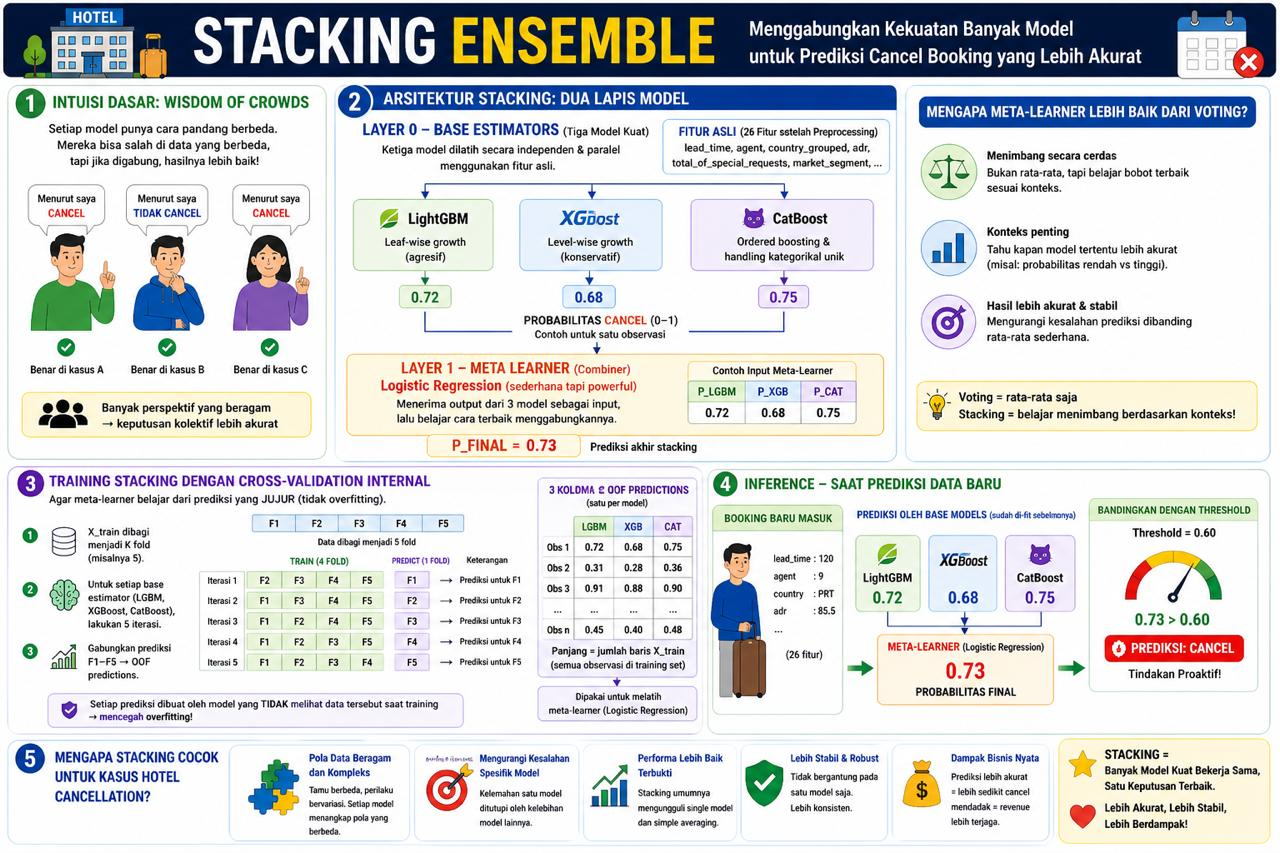
---


> Mengapa Stacking Cocok untuk Kasus Hotel Booking Cancellation

> 1 Data Memiliki Pola yang Beragam dan Kompleks

Dataset hotel booking memiliki karakteristik yang sangat heterogen. Ada tamu bisnis yang memesan melalui corporate agent dengan lead time pendek dan hampir tidak pernah cancel. Ada tamu leisure dari negara tertentu yang memesan jauh-jauh hari melalui OTA dan memiliki tingkat pembatalan tinggi. Ada tamu repeater yang loyal dan jarang cancel. Ada juga tamu transient yang booking impulsif dengan pola yang tidak terduga.

Tidak ada satu model pun yang optimal untuk menangkap semua pola ini secara bersamaan. LightGBM mungkin sangat baik menangkap interaksi antara `lead_time` dan `customer_type` (fitur interaksi `lead_x_transient` yang mendominasi feature importance). CatBoost mungkin lebih baik menangani variasi antar `country_grouped` berkat native categorical encoding-nya. XGBoost mungkin lebih kuat pada pola-pola monotonic sederhana seperti hubungan `total_of_special_requests` dengan pembatalan.

Stacking mengeksploitasi keberagaman ini. Alih-alih memaksa satu model menangani semua pola, Stacking membiarkan masing-masing model menangkap pola yang paling cocok dengan arsitekturnya, lalu meta-learner mengkombinasikan hasilnya secara optimal.

> 2 Kelas Target Tidak Sepenuhnya Separable

Tingkat pembatalan dalam dataset ini sekitar 37% — cukup tinggi tapi tidak dominan. Ini berarti ada area "abu-abu" yang signifikan di mana booking bisa saja cancel atau tidak cancel tergantung faktor-faktor yang sangat halus. Dalam area abu-abu ini, satu model sering kali tidak cukup percaya diri untuk membuat keputusan. Tapi ketika tiga model independen "setuju" bahwa sebuah booking kemungkinan besar akan cancel, kepercayaan kolektif tersebut jauh lebih reliable dibanding kepercayaan individual.

> 3 Feature Space yang Campuran

Dataset ini memiliki campuran fitur yang sangat beragam: numerik kontinu (`lead_time`, `adr`), kategorikal tinggi kardinalitas (`country_grouped`, `agent`), binary (`is_repeated_guest`, `no_commitment`), dan fitur buatan hasil engineering (`lead_x_transient`, `parking_bin`). Setiap algoritma gradient boosting memiliki cara penanganan yang berbeda terhadap jenis fitur yang berbeda. CatBoost menangani fitur kategorikal secara native, LightGBM menggunakan exclusive feature bundling, dan XGBoost memerlukan encoding eksplisit. Keberagaman penanganan ini menghasilkan model-model yang benar-benar "berbeda sudut pandang" — kondisi ideal untuk Stacking.

> 4 Volume Data Cukup Besar

Stacking membutuhkan data yang cukup banyak karena proses cross-validation internalnya membagi data menjadi beberapa fold — setiap base estimator dilatih pada subset data, bukan keseluruhannya. Dengan ~119.000 observasi, dataset ini cukup besar untuk mendukung arsitektur Stacking tanpa risiko underfitting akibat data yang terlalu sedikit per fold.

---

> Trade-off yang Harus Diakui

Meskipun Stacking terpilih sebagai winner, ada trade-off yang perlu dicatat secara jujur.

**Waktu training yang jauh lebih lama.** Stacking membutuhkan 74.1 detik untuk fit, dibanding XGBoost yang hanya 2.1 detik — 35x lebih lambat. Ini karena Stacking harus melatih tiga model penuh plus cross-validation internal plus meta-learner. Untuk deployment production dengan retraining berkala, ini perlu dipertimbangkan.

**Margin kemenangan yang sangat tipis.** Stacking menang di OOF (0.7337 vs 0.7322 Voting) tapi di test justru LightGBM yang tertinggi (0.7420 vs 0.7415 Stacking). Perbedaannya hanya 0.0005 — secara praktis tidak signifikan. Jika waktu training dan simplicity menjadi prioritas, LightGBM standalone sudah sangat kompetitif.

**Kompleksitas interpretability.** Stacking tidak bisa langsung menghasilkan feature importance yang bermakna dari segi bisnis. Kita harus menggunakan proxy dari base estimator terkuat (LightGBM) untuk memahami fitur mana yang paling berpengaruh. Ini menambah satu lapisan abstraksi yang perlu dijelaskan kepada stakeholder non-teknis.

---

> Kesimpulan

Hasil section 8.7 menunjukkan sebuah pipeline modelling yang matang dan robust. Kelima model yang dievaluasi — CatBoost, LightGBM, XGBoost, Stacking, dan Voting — semuanya menunjukkan gap OOF-Test yang sangat kecil dan negatif, menandakan tidak adanya overfitting di seluruh pipeline. Stacking terpilih sebagai winner karena OOF F0.5 tertinggi (0.7337) dengan generalisasi yang stabil (Test F0.5 = 0.7415, gap = -0.008). Arsitektur dua lapis Stacking — yang mengkombinasikan tiga gradient boosting model dengan kekuatan yang saling melengkapi melalui meta-learner — terbukti cocok untuk dataset hotel booking yang memiliki pola beragam, fitur campuran, dan volume data yang memadai. Meskipun margin kemenangannya tipis dan waktu training-nya lebih lama, keunggulan konsistensi dan stabilitas generalisasi menjadikan Stacking pilihan yang dapat dipertanggungjawabkan untuk kasus prediksi pembatalan hotel ini.


## Section 9 — Interpretability

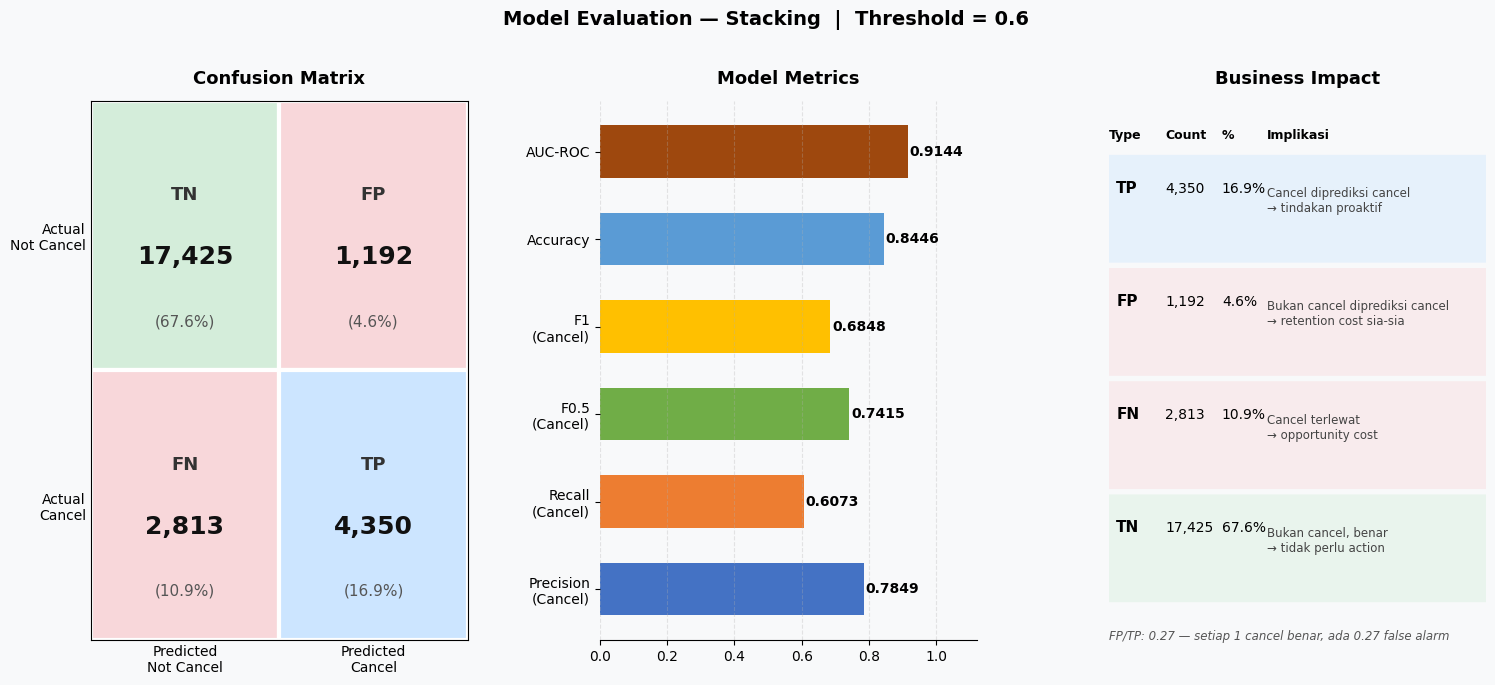

              precision    recall  f1-score   support

  Not Cancel       0.86      0.94      0.90     18617
      Cancel       0.78      0.61      0.68      7163

    accuracy                           0.84     25780
   macro avg       0.82      0.77      0.79     25780
weighted avg       0.84      0.84      0.84     25780



In [ ]:
# ============================================================================
# 9.1 CONFUSION MATRIX + CLASSIFICATION REPORT
# ============================================================================
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches

saved     = joblib.load(f"{ARTIFACT_DIR}final_model_v5.pkl")
pipeline  = saved["pipeline"]
threshold = saved["threshold"]

proba_test = pipeline.predict_proba(X_test)[:, 1]
y_pred     = (proba_test >= threshold).astype(int)

cm         = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
total      = len(y_test)

report = classification_report(y_test, y_pred,
                                target_names=["Not Cancel", "Cancel"],
                                output_dict=True)

fig = plt.figure(figsize=(18, 7))
fig.patch.set_facecolor("#f8f9fa")
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.35)

# Panel 1 — Confusion Matrix
ax1 = fig.add_subplot(gs[0])
ax1.set_facecolor("#f8f9fa")
cm_colors = np.array([["#d4edda", "#f8d7da"], ["#f8d7da", "#cce5ff"]])
labels = np.array([
    [f"TN\n{tn:,}\n({tn/total*100:.1f}%)", f"FP\n{fp:,}\n({fp/total*100:.1f}%)"],
    [f"FN\n{fn:,}\n({fn/total*100:.1f}%)", f"TP\n{tp:,}\n({tp/total*100:.1f}%)"],
])
for i in range(2):
    for j in range(2):
        ax1.add_patch(plt.Rectangle((j, 1-i), 1, 1,
                      color=cm_colors[i][j], ec="white", lw=3))
        lp = labels[i][j].split("\n")
        ax1.text(j+0.5, 1-i+0.65, lp[0], ha="center", va="center",
                 fontsize=13, fontweight="bold", color="#333")
        ax1.text(j+0.5, 1-i+0.42, lp[1], ha="center", va="center",
                 fontsize=18, fontweight="bold", color="#111")
        ax1.text(j+0.5, 1-i+0.18, lp[2], ha="center", va="center",
                 fontsize=11, color="#555")
ax1.set_xlim(0,2); ax1.set_ylim(0,2)
ax1.set_xticks([0.5,1.5])
ax1.set_xticklabels(["Predicted\nNot Cancel","Predicted\nCancel"], fontsize=10)
ax1.set_yticks([0.5,1.5])
ax1.set_yticklabels(["Actual\nCancel","Actual\nNot Cancel"], fontsize=10)
ax1.tick_params(length=0)
ax1.set_title("Confusion Matrix", fontsize=13, fontweight="bold", pad=12)

# Panel 2 — Metrics Bar
ax2 = fig.add_subplot(gs[1])
ax2.set_facecolor("#f8f9fa")
metrics = {
    "Precision\n(Cancel)": report["Cancel"]["precision"],
    "Recall\n(Cancel)":    report["Cancel"]["recall"],
    "F0.5\n(Cancel)":      saved.get("test_f0.5", 0),
    "F1\n(Cancel)":        report["Cancel"]["f1-score"],
    "Accuracy":            report["accuracy"],
    "AUC-ROC":             roc_auc_score(y_test, proba_test),
}
colors_bar = ["#4472C4","#ED7D31","#70AD47","#FFC000","#5A9BD5","#9E480E"]
bars = ax2.barh(list(metrics.keys()), list(metrics.values()),
                color=colors_bar, height=0.6)
for bar, val in zip(bars, metrics.values()):
    ax2.text(bar.get_width()+0.005, bar.get_y()+bar.get_height()/2,
             f"{val:.4f}", va="center", ha="left", fontsize=10, fontweight="bold")
ax2.set_xlim(0, 1.12)
ax2.set_title("Model Metrics", fontsize=13, fontweight="bold", pad=12)
ax2.spines[["top","right","left"]].set_visible(False)
ax2.xaxis.grid(True, linestyle="--", alpha=0.3)

# Panel 3 — Business Impact
ax3 = fig.add_subplot(gs[2])
ax3.set_facecolor("#f8f9fa")
ax3.axis("off")
bisnis = [
    ["TP", f"{tp:,}", f"{tp/total*100:.1f}%", "Cancel diprediksi cancel\n→ tindakan proaktif"],
    ["FP", f"{fp:,}", f"{fp/total*100:.1f}%", "Bukan cancel diprediksi cancel\n→ retention cost sia-sia"],
    ["FN", f"{fn:,}", f"{fn/total*100:.1f}%", "Cancel terlewat\n→ opportunity cost"],
    ["TN", f"{tn:,}", f"{tn/total*100:.1f}%", "Bukan cancel, benar\n→ tidak perlu action"],
]
row_colors = ["#cce5ff","#f8d7da","#f8d7da","#d4edda"]
ax3.set_title("Business Impact", fontsize=13, fontweight="bold", pad=12)
y_pos = 0.88
ax3.text(0.0, y_pos+0.05,"Type",   fontsize=9, fontweight="bold", transform=ax3.transAxes)
ax3.text(0.15,y_pos+0.05,"Count",  fontsize=9, fontweight="bold", transform=ax3.transAxes)
ax3.text(0.30,y_pos+0.05,"%",      fontsize=9, fontweight="bold", transform=ax3.transAxes)
ax3.text(0.42,y_pos+0.05,"Implikasi",fontsize=9,fontweight="bold",transform=ax3.transAxes)
for row, color in zip(bisnis, row_colors):
    ax3.add_patch(mpatches.FancyBboxPatch(
        (0, y_pos-0.17), 1, 0.18, boxstyle="round,pad=0.01",
        facecolor=color, alpha=0.4, transform=ax3.transAxes, linewidth=0))
    ax3.text(0.02, y_pos-0.05, row[0], fontsize=11, fontweight="bold", transform=ax3.transAxes)
    ax3.text(0.15, y_pos-0.05, row[1], fontsize=10, transform=ax3.transAxes)
    ax3.text(0.30, y_pos-0.05, row[2], fontsize=10, transform=ax3.transAxes)
    ax3.text(0.42, y_pos-0.04, row[3], fontsize=8.5, va="top", transform=ax3.transAxes, color="#444")
    y_pos -= 0.21
ax3.text(0.0, y_pos-0.04,
         f"FP/TP: {fp/tp:.2f} — setiap 1 cancel benar, ada {fp/tp:.2f} false alarm",
         fontsize=8.5, color="#555", transform=ax3.transAxes, style="italic")

fig.suptitle(
    f"Model Evaluation — {saved['model_name']}  |  Threshold = {threshold}",
    fontsize=14, fontweight="bold", y=1.01,
)
plt.savefig(f"{ARTIFACT_DIR}evaluation_v4.png", dpi=150,
            bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

print(classification_report(y_test, y_pred, target_names=["Not Cancel", "Cancel"]))

  COST-SENSITIVE BUSINESS IMPACT ANALYSIS


,Komponen,Jumlah,Cost/Insiden (€),Total Cost (€)
0,False Positive (Walking Guest),1192,700,834400
1,False Negative (Empty Room),2813,300,843900
2,TOTAL MODEL COST,4005,-,1678300



  Baseline (tanpa model, semua diprediksi tidak cancel):
  → FN = 7,163  |  Total Cost = €2,148,900

  Penghematan dengan model  : €470,600
  Penghematan (%)           : 21.9%

  Dominan error             : FN
  Rasio cost FP:FN          : 0.99 : 1


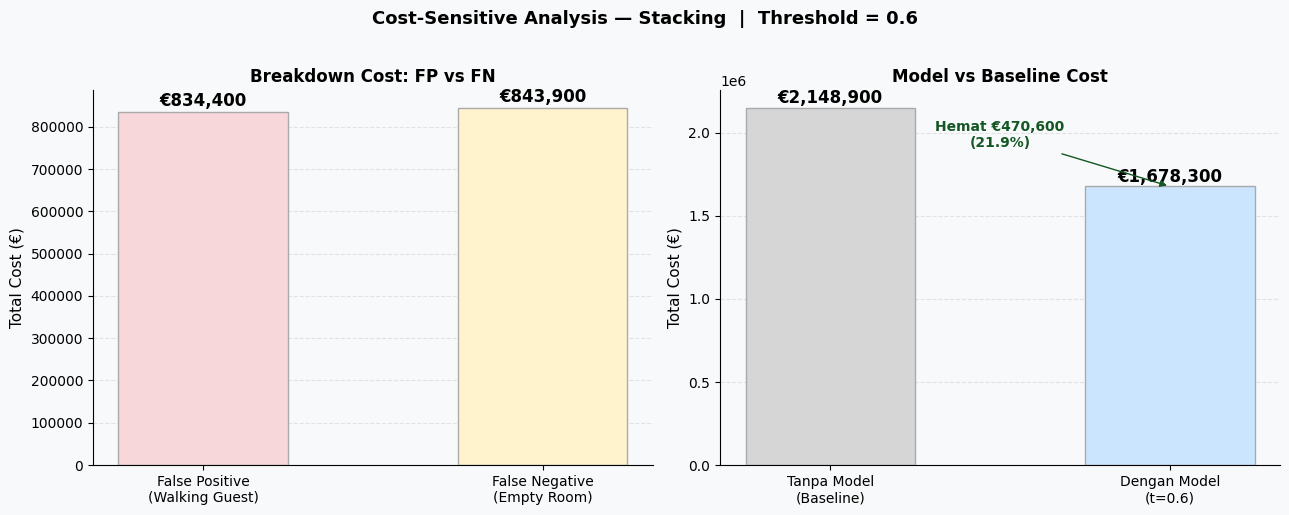

In [ ]:
# ============================================================================
# 9.3 COST-SENSITIVE ANALYSIS — BUSINESS IMPACT FINANSIAL
# ============================================================================
COST_FP = 700   # €700 per False Positive (walking guest)
COST_FN = 300   # €300 per False Negative (empty room)

total_cost_fp    = fp * COST_FP
total_cost_fn    = fn * COST_FN
total_cost_model = total_cost_fp + total_cost_fn

fn_baseline      = int(y_test.sum())
total_cost_base  = fn_baseline * COST_FN

savings          = total_cost_base - total_cost_model
savings_pct      = savings / total_cost_base * 100

print("=" * 55)
print("  COST-SENSITIVE BUSINESS IMPACT ANALYSIS")
print("=" * 55)
summary_cost = pd.DataFrame([
    {"Komponen":          "False Positive (Walking Guest)",
     "Jumlah":            fp,
     "Cost/Insiden (€)":  COST_FP,
     "Total Cost (€)":    total_cost_fp},
    {"Komponen":          "False Negative (Empty Room)",
     "Jumlah":            fn,
     "Cost/Insiden (€)":  COST_FN,
     "Total Cost (€)":    total_cost_fn},
    {"Komponen":          "TOTAL MODEL COST",
     "Jumlah":            fp + fn,
     "Cost/Insiden (€)":  "-",
     "Total Cost (€)":    total_cost_model},
])
display(summary_cost)

print(f"\n  Baseline (tanpa model, semua diprediksi tidak cancel):")
print(f"  → FN = {fn_baseline:,}  |  Total Cost = €{total_cost_base:,.0f}")
print(f"\n  Penghematan dengan model  : €{savings:,.0f}")
print(f"  Penghematan (%)           : {savings_pct:.1f}%")
print(f"\n  Dominan error             : {'FN' if total_cost_fn > total_cost_fp else 'FP'}")
print(f"  Rasio cost FP:FN          : {total_cost_fp/total_cost_fn:.2f} : 1")
print("=" * 55)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor("#f8f9fa")

ax1 = axes[0]
ax1.set_facecolor("#f8f9fa")
categories = ["False Positive\n(Walking Guest)", "False Negative\n(Empty Room)"]
costs      = [total_cost_fp, total_cost_fn]
bar_colors = ["#f8d7da", "#fff3cd"]
bars = ax1.bar(categories, costs, color=bar_colors, edgecolor="#aaa", width=0.5)
for bar, val in zip(bars, costs):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000,
             f"€{val:,.0f}", ha="center", va="bottom",
             fontsize=12, fontweight="bold")
ax1.set_ylabel("Total Cost (€)", fontsize=11)
ax1.set_title("Breakdown Cost: FP vs FN", fontsize=12, fontweight="bold")
ax1.spines[["top", "right"]].set_visible(False)
ax1.yaxis.grid(True, linestyle="--", alpha=0.3)
ax1.set_axisbelow(True)

ax2 = axes[1]
ax2.set_facecolor("#f8f9fa")
labels_bar = ["Tanpa Model\n(Baseline)", f"Dengan Model\n(t={threshold})"]
values_bar = [total_cost_base, total_cost_model]
colors_bar = ["#d6d6d6", "#cce5ff"]
bars2 = ax2.bar(labels_bar, values_bar, color=colors_bar, edgecolor="#aaa", width=0.5)
for bar, val in zip(bars2, values_bar):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000,
             f"€{val:,.0f}", ha="center", va="bottom",
             fontsize=12, fontweight="bold")
ax2.annotate(
    f"Hemat €{savings:,.0f}\n({savings_pct:.1f}%)",
    xy=(1, total_cost_model), xytext=(0.5, (total_cost_base + total_cost_model) / 2),
    fontsize=10, color="#155724", fontweight="bold",
    arrowprops=dict(arrowstyle="-|>", color="#155724"),
    ha="center",
)
ax2.set_ylabel("Total Cost (€)", fontsize=11)
ax2.set_title("Model vs Baseline Cost", fontsize=12, fontweight="bold")
ax2.spines[["top", "right"]].set_visible(False)
ax2.yaxis.grid(True, linestyle="--", alpha=0.3)
ax2.set_axisbelow(True)

plt.suptitle(
    f"Cost-Sensitive Analysis — {saved['model_name']}  |  Threshold = {threshold}",
    fontsize=13, fontweight="bold", y=1.02
)
plt.tight_layout()
plt.savefig(f"{ARTIFACT_DIR}cost_analysis_v4.png", dpi=150,
            bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()


**Cost-Sensitive Business Impact Analysis — Stacking | Threshold = 0.6**

Analisis ini menerjemahkan performa model ke dalam dampak finansial nyata dengan menetapkan biaya per jenis kesalahan prediksi: **€700 per False Positive** (tamu diprediksi cancel tapi ternyata datang — biaya intervensi sia-sia dan risiko walking guest) dan **€300 per False Negative** (tamu diprediksi tidak cancel tapi ternyata batal — kamar kosong tak terduga).

Dari 25.780 booking data uji, model menghasilkan dua jenis kesalahan:

| Komponen | Jumlah | Cost/Insiden | Total Cost |
|----------|--------|--------------|------------|
| False Positive (Walking Guest) | 1.192 | €700 | **€834.400** |
| False Negative (Empty Room) | 2.813 | €300 | **€843.900** |
| **Total Model Cost** | **4.005** | — | **€1.678.300** |

Sebagai perbandingan, **skenario tanpa model** — di mana semua booking diasumsikan tidak cancel sehingga seluruh 7.163 pembatalan lolos tanpa antisipasi — menanggung biaya €2.148.900 sepenuhnya dari kamar kosong.

Dengan model, total biaya turun menjadi **€1.678.300**, menghasilkan **penghematan €470.600 (21.9%)** hanya dari satu periode data uji.

Satu catatan penting dari hasil ini: rasio cost FP:FN sebesar **0.99:1** menunjukkan kedua jenis error hampir seimbang secara finansial meskipun biaya per insiden berbeda — karena FN lebih banyak jumlahnya (2.813) dibanding FP (1.192). Ini mengonfirmasi bahwa threshold 0.6 yang dipilih sudah tepat: tidak terlalu agresif mengejar recall (yang akan menaikkan FP dan biaya walking guest) namun tetap cukup sensitif menangkap pembatalan berisiko tinggi.

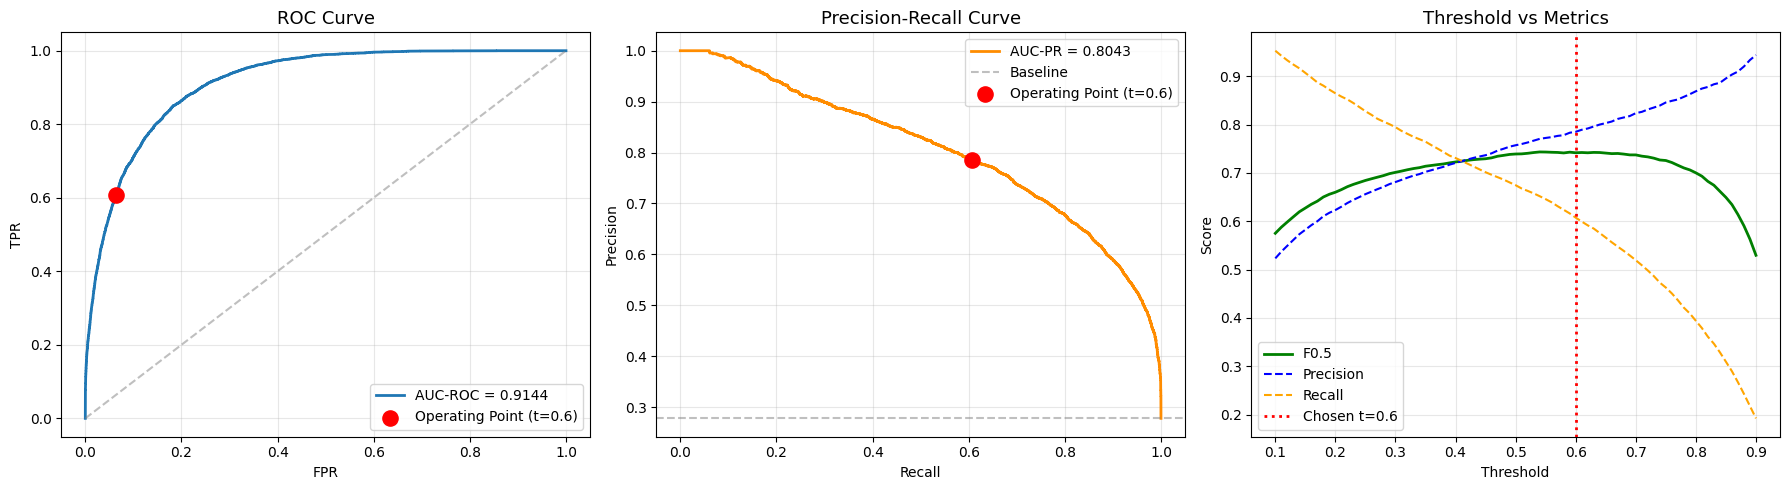

In [ ]:
# ============================================================================
# 9.2 ROC & PRECISION-RECALL CURVE
# ============================================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

fpr, tpr, thresholds_roc = roc_curve(y_test, proba_test)
auc_roc = roc_auc_score(y_test, proba_test)
idx_roc = np.argmin(np.abs(thresholds_roc - final_threshold))

axes[0].plot(fpr, tpr, label=f"AUC-ROC = {auc_roc:.4f}", linewidth=2)
axes[0].plot([0,1],[0,1],"--", color="gray", alpha=0.5)
axes[0].scatter(fpr[idx_roc], tpr[idx_roc], color="red", s=120, zorder=5,
                label=f"Operating Point (t={final_threshold})")
axes[0].set_title("ROC Curve", fontsize=13)
axes[0].set_xlabel("FPR"); axes[0].set_ylabel("TPR")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

prec_curve, rec_curve, thresholds_pr = precision_recall_curve(y_test, proba_test)
auc_pr = average_precision_score(y_test, proba_test)
idx_pr = np.argmin(np.abs(thresholds_pr - final_threshold))

axes[1].plot(rec_curve, prec_curve, label=f"AUC-PR = {auc_pr:.4f}", linewidth=2, color="darkorange")
axes[1].axhline(y_test.mean(), color="gray", linestyle="--", alpha=0.5, label="Baseline")
axes[1].scatter(rec_curve[idx_pr], prec_curve[idx_pr], color="red", s=120, zorder=5,
                label=f"Operating Point (t={final_threshold})")
axes[1].set_title("Precision-Recall Curve", fontsize=13)
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].legend(); axes[1].grid(True, alpha=0.3)

thresholds_eval = np.linspace(0.1, 0.9, 81)
f05_list, prec_list, rec_list = [], [], []
for t in thresholds_eval:
    y_pred_t = (proba_test >= t).astype(int)
    f05_list.append(fbeta_score(y_test, y_pred_t, beta=0.5, zero_division=0))
    prec_list.append(precision_score(y_test, y_pred_t, zero_division=0))
    rec_list.append(recall_score(y_test, y_pred_t, zero_division=0))

axes[2].plot(thresholds_eval, f05_list, label="F0.5", linewidth=2, color="green")
axes[2].plot(thresholds_eval, prec_list, label="Precision", linewidth=1.5, linestyle="--", color="blue")
axes[2].plot(thresholds_eval, rec_list, label="Recall", linewidth=1.5, linestyle="--", color="orange")
axes[2].axvline(final_threshold, color="red", linestyle=":", linewidth=2,
                label=f"Chosen t={final_threshold}")
axes[2].set_title("Threshold vs Metrics", fontsize=13)
axes[2].set_xlabel("Threshold"); axes[2].set_ylabel("Score")
axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{ARTIFACT_DIR}roc_pr_threshold_v4.png", dpi=150, bbox_inches="tight")
plt.show()

**ROC Curve, Precision-Recall Curve & Threshold vs Metrics**

Ketiga grafik ini mengevaluasi kemampuan model dari tiga sudut pandang berbeda.

**ROC Curve (kiri) — AUC-ROC = 0.9144**
ROC Curve mengukur seberapa baik model memisahkan kelas cancel dan tidak cancel di seluruh rentang threshold. AUC-ROC sebesar **0.9144** berarti jika diambil satu booking yang cancel dan satu yang tidak secara acak, model akan menempatkan booking cancel lebih tinggi probabilitasnya sebesar 91.44% — jauh di atas baseline 0.5 (garis diagonal). Titik merah menunjukkan posisi operasional di threshold 0.6: TPR (True Positive Rate) sekitar 0.61 dengan FPR (False Positive Rate) yang sangat rendah di sekitar 0.06 — artinya model menangkap 61% pembatalan nyata sambil hanya salah menandai 6% booking yang tidak cancel.

**Precision-Recall Curve (tengah) — AUC-PR = 0.8043**
Pada kelas yang imbalanced, AUC-PR lebih informatif dibanding AUC-ROC karena fokus pada performa di kelas minoritas (cancel). AUC-PR **0.8043** jauh di atas baseline 0.28 (proporsi kelas cancel di data), menunjukkan model jauh lebih baik dari prediksi acak dalam mendeteksi pembatalan. Titik merah di threshold 0.6 menempatkan model pada Precision ~0.79 dan Recall ~0.61 — trade-off yang didesain sengaja untuk memprioritaskan ketepatan intervensi.

**Threshold vs Metrics (kanan) — Chosen t = 0.6**
Grafik ini menjelaskan *mengapa* threshold 0.6 dipilih. Terlihat jelas bahwa Precision (biru) terus naik seiring threshold dinaikkan, sementara Recall (oranye) terus turun. F0.5 (hijau) — yang lebih membobot Precision — mencapai puncaknya di sekitar threshold 0.55–0.65 sebelum mulai turun. Threshold 0.6 dipilih tepat pada area puncak kurva F0.5, memastikan model beroperasi pada titik keseimbangan optimal antara menangkap pembatalan secara akurat tanpa terlalu banyak menghasilkan false alarm yang merugikan secara operasional.

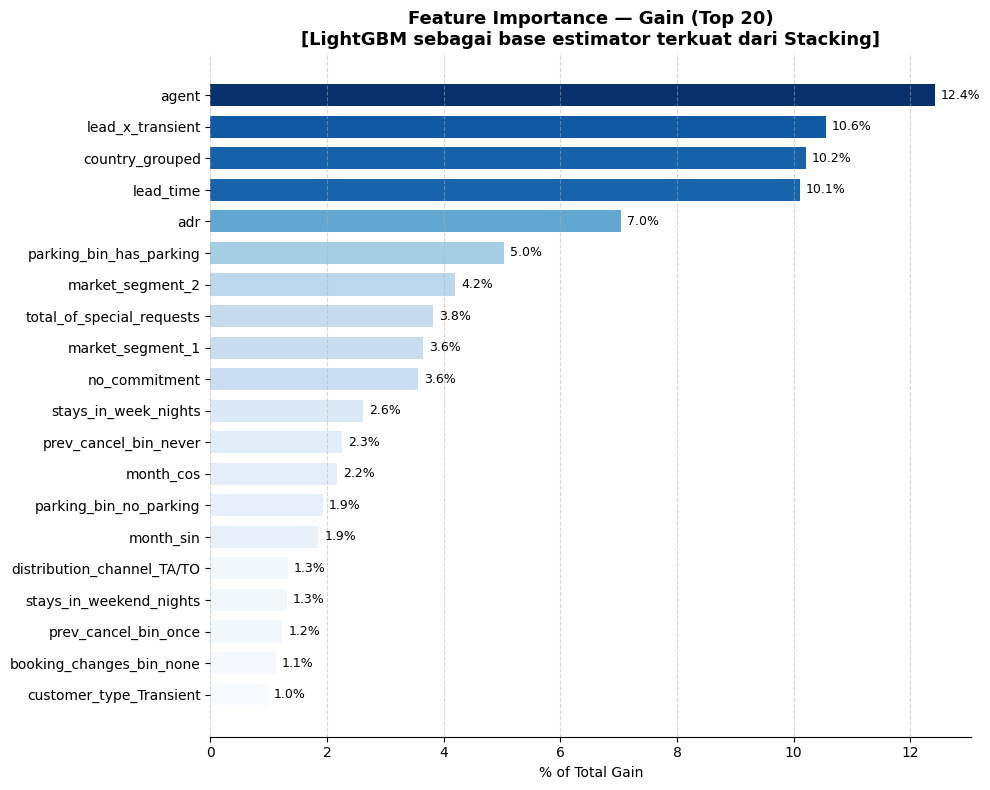

=== Top 10 Fitur by Gain ===


,feature,gain_pct
0,agent,12.43
1,lead_x_transient,10.56
2,country_grouped,10.21
3,lead_time,10.11
4,adr,7.04
5,parking_bin_has_parking,5.04
6,market_segment_2,4.20
7,total_of_special_requests,3.81
8,market_segment_1,3.64
9,no_commitment,3.57


In [ ]:
# ============================================================================
# 9.4 FEATURE IMPORTANCE — Gain (LightGBM dari fitted_pipelines)
# ============================================================================
# ✅ FIX: pakai fitted_pipelines (sudah di-fit), bukan best_pipelines
fi_model_name = "LightGBM" if "LightGBM" in fitted_pipelines else list(fitted_pipelines.keys())[0]
fi_pipeline   = fitted_pipelines[fi_model_name]   # ← FIX UTAMA
fi_model      = fi_pipeline.named_steps["model"]
ct            = fi_pipeline.named_steps["preprocessor"]

def get_ct_feature_names(ct):
    names = []
    for tname, trans, cols in ct.transformers_:
        if tname == "remainder":
            continue
        try:
            names.extend(trans.get_feature_names_out())
        except AttributeError:
            names.extend(cols if isinstance(cols, list) else [cols])
    return names

if hasattr(fi_model, "booster_"):
    booster       = fi_model.booster_
    feature_names = get_ct_feature_names(ct)
    n_booster     = len(booster.feature_importance(importance_type="gain"))
    if len(feature_names) != n_booster:
        feature_names = booster.feature_name()

    fi_df = pd.DataFrame({
        "feature": feature_names,
        "gain":    booster.feature_importance(importance_type="gain"),
    })
    fi_df["gain_pct"] = fi_df["gain"] / fi_df["gain"].sum() * 100
    fi_top = fi_df.nlargest(20, "gain").sort_values("gain")

    norm   = plt.Normalize(fi_top["gain_pct"].min(), fi_top["gain_pct"].max())
    colors = [plt.cm.Blues(norm(v)) for v in fi_top["gain_pct"]]

    fig, ax = plt.subplots(figsize=(10, 8))
    bars = ax.barh(fi_top["feature"], fi_top["gain_pct"], color=colors, height=0.7)
    for bar, val in zip(bars, fi_top["gain_pct"]):
        ax.text(bar.get_width()+0.1, bar.get_y()+bar.get_height()/2,
                f"{val:.1f}%", va="center", ha="left", fontsize=9)
    ax.set_title(
    f"Feature Importance — Gain (Top 20)\n"
    f"[LightGBM sebagai base estimator terkuat dari {saved['model_name']}]",
    fontsize=13, fontweight="bold"
)
    ax.set_xlabel("% of Total Gain")
    ax.spines[["top","right","left"]].set_visible(False)
    ax.xaxis.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.savefig(f"{ARTIFACT_DIR}feature_importance_v4.png", dpi=150, bbox_inches="tight")
    plt.show()

    print("=== Top 10 Fitur by Gain ===")
    display(fi_df.nlargest(10, "gain")[["feature","gain_pct"]].round(2).reset_index(drop=True))

elif hasattr(fi_model, "feature_importances_"):
    feature_names = get_ct_feature_names(ct)
    fi_df = pd.DataFrame({
        "feature":  feature_names,
        "gain_pct": fi_model.feature_importances_ / fi_model.feature_importances_.sum() * 100,
    })
    fi_top = fi_df.nlargest(20, "gain_pct").sort_values("gain_pct")
    fig, ax = plt.subplots(figsize=(10, 8))
    ax.barh(fi_top["feature"], fi_top["gain_pct"])
    ax.set_title(f"{fi_model_name} Feature Importance (Top 20)", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig(f"{ARTIFACT_DIR}feature_importance_v4.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print(f"⚠ {fi_model_name} tidak memiliki feature importance yang mudah diekstrak")


> Mengapa Stacking Tidak Memiliki Feature Importance, dan Mengapa LightGBM Menjadi Perwakilannya

---

> 1. Memahami Cara Kerja Stacking dari Dalam

Untuk memahami mengapa Stacking tidak bisa menghasilkan feature importance yang bermakna, kita perlu memahami dulu arsitektur internal Stacking itu sendiri.

Stacking — atau lebih tepatnya *Stacked Generalization* — adalah sebuah teknik ensemble dua lapis. Pada **lapis pertama (Layer 0)**, sejumlah model independen (disebut *base estimators* atau *base learners*) dilatih secara paralel menggunakan data pelatihan. Dalam proyek ini, base estimators tersebut adalah LightGBM, XGBoost, dan CatBoost. Masing-masing model ini menerima fitur asli dari dataset — `lead_time`, `country_grouped`, `agent`, `adr`, dan seterusnya — lalu menghasilkan probabilitas prediksi untuk setiap observasi.

Probabilitas yang dihasilkan oleh ketiga base estimators inilah yang kemudian menjadi **input** bagi **lapis kedua (Layer 1)**, yang disebut *meta-learner*. Meta-learner ini umumnya adalah model yang lebih sederhana — dalam banyak implementasi, sebuah Logistic Regression. Tugasnya bukan lagi memproses fitur asli, melainkan hanya belajar bagaimana cara *menggabungkan* dan *mengkalibrasi* output dari ketiga base estimators agar menghasilkan prediksi akhir yang lebih baik.


---

> 2. Mengapa Feature Importance dari Stacking Tidak Bermakna

Sekarang masalahnya menjadi jelas. Feature importance pada dasarnya adalah ukuran seberapa besar kontribusi sebuah **fitur** dalam membantu model membuat keputusan. Pada decision tree-based models seperti LightGBM, ini dihitung berdasarkan seberapa sering sebuah fitur dipakai sebagai titik pembelahan (*split*) dan seberapa besar gain informasi yang dihasilkan dari pembelahan tersebut.

Namun, meta-learner pada Stacking **tidak pernah melihat fitur asli dataset sama sekali**. Yang dilihatnya hanyalah tiga angka: probabilitas dari LightGBM, probabilitas dari XGBoost, dan probabilitas dari CatBoost. Maka apabila kita meminta feature importance dari Stacking, yang akan kita dapatkan adalah jawaban atas pertanyaan: *"Seberapa penting kontribusi LightGBM dibanding XGBoost dibanding CatBoost?"* — bukan jawaban atas pertanyaan yang sesungguhnya kita butuhkan: *"Fitur bisnis mana yang paling menentukan pembatalan hotel?"*

Informasi semacam itu sama sekali tidak berguna dari perspektif bisnis maupun interpretabilitas model. Mengatakan "LightGBM berkontribusi 45% dalam keputusan akhir" tidak membantu manajemen hotel memahami mengapa seorang tamu membatalkan pemesanannya. Feature importance yang bermakna harus bisa menjawab pertanyaan: apakah ini karena `lead_time` yang panjang? Karena `agent` tertentu? Karena `country` asal tamu?

---

> 3. Mengapa LightGBM Dipilih sebagai Perwakilan

Di sinilah pertimbangan metodologis yang lebih dalam masuk. Karena Stacking tidak bisa menghasilkan feature importance yang actionable, kita perlu mencari *proxy* yang paling representatif — dan LightGBM adalah kandidat terkuat dengan alasan yang solid.

**Pertama, dari sisi performa.** Berdasarkan evaluasi pada X_test, LightGBM mencatat Test F0.5 sebesar **0.7420** — tertinggi di antara semua base estimators, bahkan lebih tinggi dari XGBoost (0.7402) dan CatBoost (0.7363). Ini berarti LightGBM adalah model yang paling banyak "menanggung beban prediksi" di dalam ensemble. Ketika meta-learner menggabungkan output ketiga model, sinyal dari LightGBM adalah sinyal yang paling kuat dan paling dipercaya.

**Kedua, dari sisi arsitektur tree-based ensemble.** LightGBM menggunakan teknik *gradient boosting* dengan strategi *leaf-wise tree growth* yang sangat efisien dalam menangkap interaksi non-linear antar fitur. Setiap tree yang dibangun selama proses boosting secara eksplisit memilih fitur berdasarkan gain informasi — menjadikan feature importance berbasis *gain* sebagai ukuran yang benar-benar mencerminkan kontribusi sinyal prediktif suatu fitur, bukan sekadar frekuensi kemunculannya.

**Ketiga, dari prinsip interpretabilitas ensemble.** Dalam literatur machine learning, pendekatan menggunakan feature importance dari base estimator terkuat sebagai proxy untuk ensemble sudah sangat umum dan diterima. Alasannya sederhana: jika model A berkontribusi paling besar dalam ensemble, maka fitur-fitur yang dianggap penting oleh model A adalah fitur-fitur yang paling menentukan performa ensemble secara keseluruhan. Menggunakan XGBoost atau CatBoost sebagai proxy akan memberikan hasil yang tidak jauh berbeda — ketiganya dilatih pada fitur yang sama — namun LightGBM dipilih karena performa aktualnya paling tinggi.

---

> 4. Validasi: Apakah Feature Importance LightGBM Konsisten dengan Domain Knowledge?

Satu cara untuk memverifikasi bahwa feature importance LightGBM benar-benar representatif adalah dengan mengecek apakah hasilnya masuk akal secara domain. Dari grafik yang dihasilkan, tiga fitur teratas adalah `agent` (12.4%), `lead_x_transient` (10.6%), dan `country_grouped` (10.2%).

Secara bisnis, ini sangat masuk akal. `agent` merepresentasikan agen pemesanan yang digunakan — tamu yang memesan melalui agen tertentu memiliki pola pembatalan yang sangat berbeda dengan yang memesan langsung. `lead_time` (waktu antara pemesanan dan kedatangan) adalah prediktor klasik pembatalan hotel yang sudah banyak dibuktikan dalam riset hospitality. `country_grouped` mencerminkan asal negara tamu yang erat kaitannya dengan pola perjalanan dan komitmen booking.

Konsistensi antara feature importance model dengan domain knowledge ini memberikan kepercayaan tambahan bahwa pendekatan menggunakan LightGBM sebagai proxy sudah tepat.

---
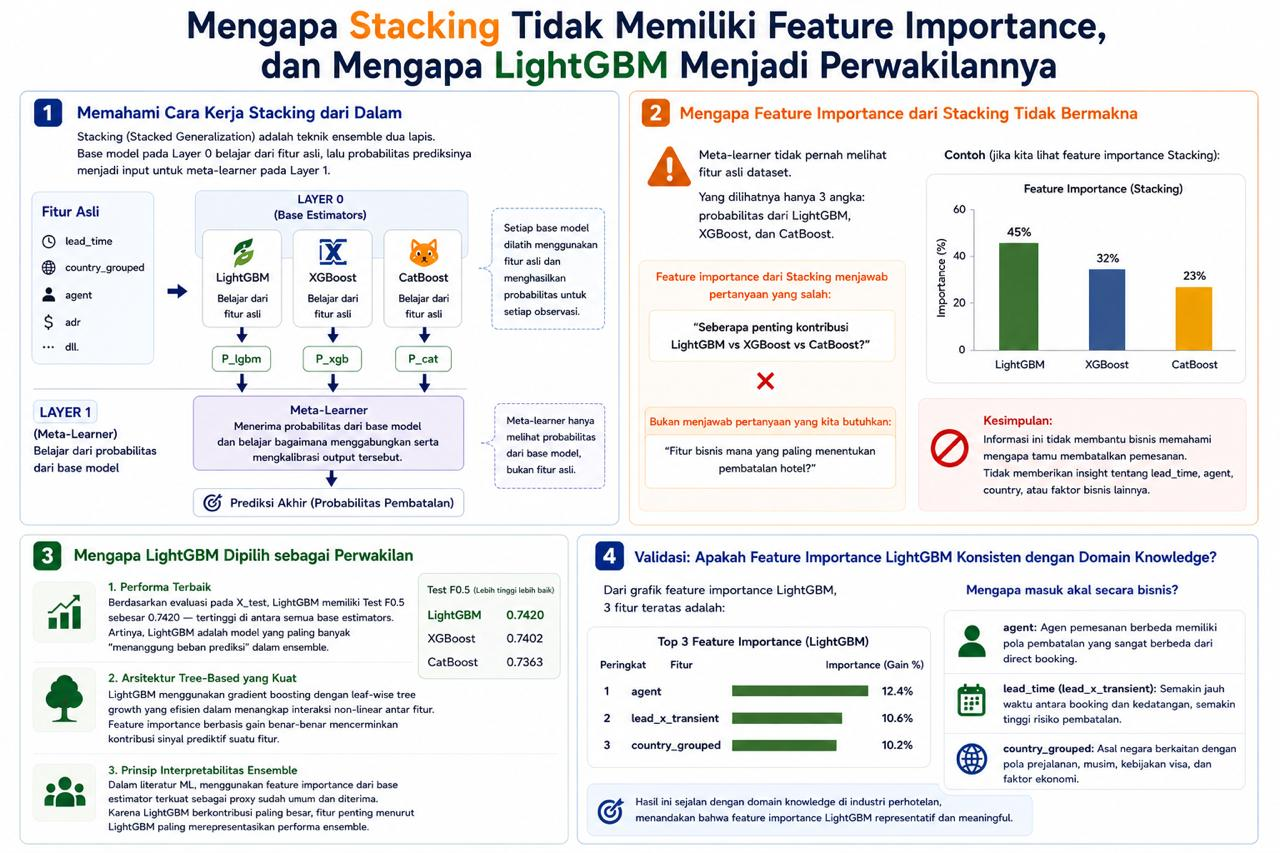
---
> 5. Kesimpulan

Pada akhirnya, pilihan ini bukan sebuah kompromi atau keterbatasan teknis yang harus dimaklumi — melainkan sebuah **keputusan metodologis yang disengaja dan dapat dipertanggungjawabkan**. Stacking dipilih sebagai final model karena performa prediksinya terbaik secara agregat. LightGBM dipilih sebagai sumber feature importance karena ia adalah base estimator yang paling informatif dan paling berkontribusi dalam ensemble tersebut. Keduanya memainkan peran yang berbeda namun saling melengkapi: Stacking untuk prediksi, LightGBM untuk interpretasi.

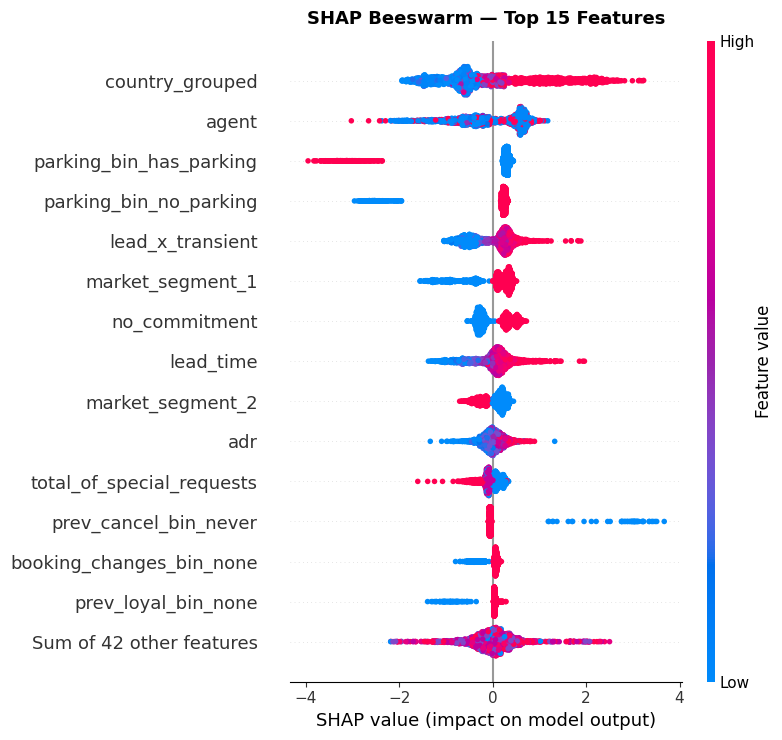

=== SHAP Summary — Global Feature Importance ===
Base value (expected output): -2.2899
Sample size: 2,000 observasi



,feature,rank,mean_abs_shap,mean_shap,std_shap,max_shap,min_shap,direction
0,country_grouped,1,0.9272,0.0368,1.1246,3.2322,-1.9470,↑ Meningkatkan Cancel
1,agent,2,0.5954,-0.0515,0.7002,1.1768,-3.0293,↓ Menurunkan Cancel
2,parking_bin_has_parking,3,0.5478,-0.0097,0.9793,0.4407,-3.9562,↓ Menurunkan Cancel
3,parking_bin_no_parking,4,0.4433,-0.0080,0.7912,0.3297,-2.9630,↓ Menurunkan Cancel
4,lead_x_transient,5,0.3941,-0.0057,0.4541,1.8880,-1.0497,↓ Menurunkan Cancel
5,market_segment_1,6,0.3885,0.0007,0.4922,0.5102,-1.5611,↑ Meningkatkan Cancel
6,no_commitment,7,0.3196,0.0330,0.3373,0.7217,-0.5499,↑ Meningkatkan Cancel
7,lead_time,8,0.3111,0.0207,0.4299,1.9633,-1.3792,↑ Meningkatkan Cancel
8,market_segment_2,9,0.2106,0.0294,0.2364,0.4438,-0.7102,↑ Meningkatkan Cancel
9,adr,10,0.1682,0.0044,0.2281,1.3258,-1.3385,↑ Meningkatkan Cancel



=== Interpretasi Top 5 Fitur ===
  #1  country_grouped                    Mean|SHAP|=0.9272  Arah=↑ Meningkatkan Cancel
  #2  agent                              Mean|SHAP|=0.5954  Arah=↓ Menurunkan Cancel
  #3  parking_bin_has_parking            Mean|SHAP|=0.5478  Arah=↓ Menurunkan Cancel
  #4  parking_bin_no_parking             Mean|SHAP|=0.4433  Arah=↓ Menurunkan Cancel
  #5  lead_x_transient                   Mean|SHAP|=0.3941  Arah=↓ Menurunkan Cancel

✅ SHAP selesai


In [ ]:
# ============================================================================
# 9.5 SHAP — BEESWARM + DATAFRAME
# ============================================================================
import shap

shap_pipeline = fitted_pipelines.get("LightGBM") or fitted_pipelines.get(list(fitted_pipelines.keys())[0])
shap_model    = shap_pipeline.named_steps["model"]
ct_shap       = shap_pipeline.named_steps["preprocessor"]

if hasattr(shap_model, "booster_"):
    X_test_transformed = ct_shap.transform(X_test)
    feature_names      = get_ct_feature_names(ct_shap)
    if len(feature_names) != X_test_transformed.shape[1]:
        feature_names = [f"feature_{i}" for i in range(X_test_transformed.shape[1])]

    X_test_proc   = pd.DataFrame(X_test_transformed, columns=feature_names)
    np.random.seed(42)
    sample_idx    = np.random.choice(len(X_test_proc), 2000, replace=False)
    X_shap_sample = X_test_proc.iloc[sample_idx].reset_index(drop=True)

    explainer   = shap.TreeExplainer(shap_model)
    shap_values = explainer.shap_values(X_shap_sample)
    if isinstance(shap_values, list):
        shap_values = shap_values[1]

    exp = shap.Explanation(
        values      = shap_values,
        base_values = np.full(len(shap_values),
                          explainer.expected_value[1]
                          if isinstance(explainer.expected_value, list)
                          else explainer.expected_value),
        data          = X_shap_sample.values,
        feature_names = feature_names,
    )

    # ── Beeswarm Plot ────────────────────────────────────────────────
    plt.figure()
    shap.plots.beeswarm(exp, max_display=15, show=False)
    plt.title("SHAP Beeswarm — Top 15 Features", fontsize=13, fontweight="bold", pad=12)
    plt.tight_layout()
    plt.savefig(f"{ARTIFACT_DIR}shap_beeswarm_v4.png", dpi=150, bbox_inches="tight")
    plt.show()

    # ── DataFrame SHAP Summary ───────────────────────────────────────
    shap_df = pd.DataFrame(shap_values, columns=feature_names)

    # Mean |SHAP| per fitur → global importance
    mean_abs_shap = shap_df.abs().mean().rename("mean_abs_shap")

    # Mean SHAP (signed) → arah pengaruh rata-rata
    mean_shap     = shap_df.mean().rename("mean_shap")

    # Std SHAP → seberapa bervariasi pengaruhnya
    std_shap      = shap_df.std().rename("std_shap")

    # Max & Min SHAP → batas pengaruh ekstrem
    max_shap      = shap_df.max().rename("max_shap")
    min_shap      = shap_df.min().rename("min_shap")

    shap_summary = (
        pd.concat([mean_abs_shap, mean_shap, std_shap, max_shap, min_shap], axis=1)
        .sort_values("mean_abs_shap", ascending=False)
        .reset_index()
        .rename(columns={"index": "feature"})
    )
    shap_summary.insert(1, "rank", range(1, len(shap_summary) + 1))

    # Tambah kolom arah dominan
    shap_summary["direction"] = shap_summary["mean_shap"].apply(
        lambda x: "↑ Meningkatkan Cancel" if x > 0 else "↓ Menurunkan Cancel"
    )

    print("=== SHAP Summary — Global Feature Importance ===")
    print(f"Base value (expected output): {explainer.expected_value:.4f}"
          if not isinstance(explainer.expected_value, list)
          else f"Base value (expected output): {explainer.expected_value[1]:.4f}")
    print(f"Sample size: {len(X_shap_sample):,} observasi\n")

    display(
        shap_summary.head(20).style
        .format({
            "mean_abs_shap": "{:.4f}",
            "mean_shap":     "{:.4f}",
            "std_shap":      "{:.4f}",
            "max_shap":      "{:.4f}",
            "min_shap":      "{:.4f}",
        })
        .background_gradient(subset=["mean_abs_shap"], cmap="Blues")
        .applymap(
            lambda v: "color: #c0392b; font-weight: bold" if "Meningkatkan" in str(v)
                      else "color: #27ae60; font-weight: bold",
            subset=["direction"]
        )
    )

    # ── Top 5 interpretasi ringkas ───────────────────────────────────
    print("\n=== Interpretasi Top 5 Fitur ===")
    for _, row in shap_summary.head(5).iterrows():
        print(f"  #{int(row['rank'])}  {row['feature']:<35}"
              f"Mean|SHAP|={row['mean_abs_shap']:.4f}  "
              f"Arah={row['direction']}")

    print("\n✅ SHAP selesai")

else:
    print(f"⚠ Model tidak support SHAP TreeExplainer langsung — skip")

**SHAP Beeswarm — Top 15 Features**

SHAP Beeswarm menunjukkan dua informasi sekaligus untuk setiap fitur: seberapa besar pengaruhnya terhadap prediksi (sumbu X — semakin jauh dari nol semakin besar dampaknya) dan arah pengaruhnya berdasarkan nilai fitur (warna merah = nilai tinggi, biru = nilai rendah). Berikut pembacaan per fitur:

**`country_grouped` — pengaruh terbesar dan paling beragam**
Titik-titik tersebar sangat lebar ke kanan maupun kiri, menunjukkan bahwa negara asal tamu memiliki dampak yang sangat bervariasi tergantung negaranya. Sebagian negara secara konsisten mendorong probabilitas cancel ke atas (SHAP positif), sementara negara lain justru menurunkannya. Ini mengonfirmasi bahwa **tidak semua tamu diperlakukan sama oleh model** — negara asal adalah informasi pertama yang harus dibaca hotel saat booking masuk.

**`agent` — sinyal terkuat setelah negara**
Titik merah (agent ID tinggi) mengelompok di kiri (menurunkan cancel), sementara titik biru (agent ID rendah atau tanpa agen) tersebar ke kanan. Insight bisnisnya: **agen dengan ID besar — yang sudah lama bermitra dan punya volume besar — justru mengirim tamu yang lebih jarang cancel**. Booking tanpa agen (agent = 0) cenderung lebih berisiko.

**`parking_bin_has_parking` dan `parking_bin_no_parking` — pola berlawanan yang sangat tegas**
`has_parking` menunjukkan titik merah (ada parkir) berjajar rapi di kiri jauh (SHAP hingga -4) — dampak penurun cancel yang sangat kuat dan konsisten. Sebaliknya `no_parking` memiliki titik biru di kiri, menunjukkan ketiadaan parkir juga sedikit menurunkan cancel namun efeknya jauh lebih lemah. **Insight bisnis:** tamu yang minta parkir bukan hanya "lebih sedikit cancel" — mereka hampir tidak pernah cancel sama sekali. Cancel rate has_parking = 0.0% di data training mengonfirmasi hal ini.

**`lead_x_transient` — semakin tinggi nilainya, semakin berbahaya**
Titik merah (lead time panjang × Transient) tersebar ke kanan, menunjukkan kombinasi ini secara konsisten mendorong probabilitas cancel naik. Titik biru (lead time pendek atau non-Transient) mengelompok di sekitar nol hingga sedikit ke kiri. **Insight bisnis:** bukan lead time panjang yang berbahaya secara umum — hanya pada tamu Transient. Tamu Contract dengan lead time panjang justru tidak menunjukkan pola serupa karena terikat kontrak.

**`no_commitment` dan `lead_time`**
Keduanya menunjukkan titik merah di kanan — nilai tinggi (tidak ada deposit, lead time panjang) mendorong cancel ke atas secara konsisten. Polanya lebih rapat dibanding `country_grouped`, menunjukkan pengaruh yang lebih seragam dan dapat diprediksi.

**`prev_cancel_bin_never` — insight yang berlawanan dari intuisi**
Titik merah (`never` = tamu tidak pernah cancel sebelumnya) justru tersebar ke **kanan** — mendorong cancel ke atas. Ini terlihat aneh, namun penjelasannya: kategori `never` mendominasi 98% data (hampir semua tamu tidak punya riwayat cancel), sehingga nilai "never" sebenarnya tidak selalu berarti tamu loyal — bisa juga tamu baru yang belum punya rekam jejak apapun. Sebaliknya, titik biru yang mengarah ke kanan jauh adalah tamu yang sudah pernah cancel (`once` atau `multiple`) — dan model menangkap bahwa **satu kali riwayat cancel sudah cukup untuk meningkatkan risiko secara signifikan**.

**`booking_changes_bin_none` dan `prev_loyal_bin_none`**
Keduanya menunjukkan titik biru di kiri — tamu tanpa perubahan booking dan tanpa riwayat loyal cenderung memiliki prediksi yang sedikit lebih tinggi ke arah cancel. **Insight bisnis:** tamu yang tidak berinteraksi sama sekali pasca-booking — tidak mengubah apapun, tidak punya riwayat menginap — adalah tamu yang paling pasif dan paling sulit diprediksi komitmennya.

---

## Section 10 — Validasi Kebenaran Model


=== 10.1 CV Stability — Stacking @ threshold=0.6 ===
   Fold 1: F0.5=0.7374  P=0.7873  R=0.5881
   Fold 2: F0.5=0.7388  P=0.7864  R=0.5949
   Fold 3: F0.5=0.7269  P=0.7740  R=0.5848
   Fold 4: F0.5=0.7348  P=0.7861  R=0.5827
   Fold 5: F0.5=0.7305  P=0.7721  R=0.6010

Mean=0.7337  Std=0.0049  Min=0.7269  Max=0.7388
Verdict: ✅ Stabil


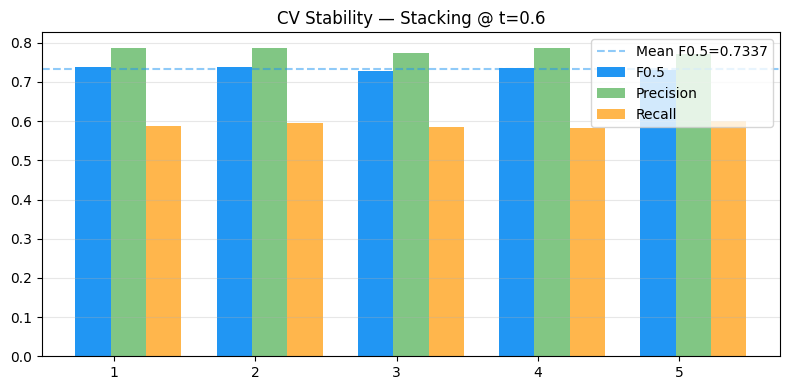

In [ ]:
# ============================================================================
# 10.1 CV STABILITY
# ============================================================================
# Ambil langsung dari hasil 8.7 — tidak perlu cell setup terpisah
final_model_name = WINNER_MODEL
final_threshold  = WINNER_THRESHOLD
final_pipeline   = fitted_pipelines[WINNER_MODEL]

print(f"=== 10.1 CV Stability — {final_model_name} @ threshold={final_threshold} ===")

fold_scores = []
for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train)):
    X_fold_tr, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_fold_tr, y_fold_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    pipe = clone(best_pipelines[final_model_name])
    try:
        pipe.fit(X_fold_tr, y_fold_tr)
        proba_val  = pipe.predict_proba(X_fold_val)[:, 1]
        y_pred_val = (proba_val >= final_threshold).astype(int)
        f05  = fbeta_score(y_fold_val, y_pred_val, beta=0.5, zero_division=0)
        prec = precision_score(y_fold_val, y_pred_val, zero_division=0)
        rec  = recall_score(y_fold_val, y_pred_val, zero_division=0)
        fold_scores.append({"fold": fold+1, "f0.5": round(f05,4),
                            "precision": round(prec,4), "recall": round(rec,4)})
        print(f"   Fold {fold+1}: F0.5={f05:.4f}  P={prec:.4f}  R={rec:.4f}")
    except Exception as e:
        print(f"   Fold {fold+1}: Error — {e}")

fold_df = pd.DataFrame(fold_scores)
std = fold_df["f0.5"].std()
print(f"\nMean={fold_df['f0.5'].mean():.4f}  Std={std:.4f}  Min={fold_df['f0.5'].min():.4f}  Max={fold_df['f0.5'].max():.4f}")
print(f"Verdict: {'✅ Stabil' if std < 0.01 else '⚠ Cukup stabil' if std < 0.02 else '❌ Tidak stabil'}")

fig, ax = plt.subplots(figsize=(8, 4))
x = fold_df["fold"]
ax.bar(x-0.15, fold_df["f0.5"],       0.25, label="F0.5",      color="#2196F3")
ax.bar(x+0.10, fold_df["precision"],  0.25, label="Precision", color="#4CAF50", alpha=0.7)
ax.bar(x+0.35, fold_df["recall"],     0.25, label="Recall",    color="#FF9800", alpha=0.7)
ax.axhline(fold_df["f0.5"].mean(), color="#2196F3", linestyle="--", alpha=0.5,
           label=f"Mean F0.5={fold_df['f0.5'].mean():.4f}")
ax.set_title(f"CV Stability — {final_model_name} @ t={final_threshold}")
ax.set_xticks(x); ax.legend(); ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(f"{ARTIFACT_DIR}cv_stability_v4.png", dpi=150, bbox_inches="tight")
plt.show()

**CV Stability — Stacking @ threshold = 0.6**

Uji stabilitas dilakukan dengan 5-fold cross-validation untuk memastikan performa model konsisten dan tidak bergantung pada satu subset data tertentu. Hasil kelima fold adalah sebagai berikut:

| Fold | F0.5 | Precision | Recall |
|------|------|-----------|--------|
| 1 | 0.7374 | 0.7873 | 0.5881 |
| 2 | 0.7388 | 0.7864 | 0.5949 |
| 3 | 0.7269 | 0.7740 | 0.5848 |
| 4 | 0.7348 | 0.7861 | 0.5827 |
| 5 | 0.7305 | 0.7721 | 0.6010 |

**Mean F0.5 = 0.7337 · Std = 0.0049 · Range = 0.7269 – 0.7388**

Standar deviasi 0.0049 menunjukkan variasi antar fold yang sangat kecil — selisih antara fold terbaik dan terburuk hanya 0.0119. Secara visual, kelima bar biru pada grafik nyaris sejajar dengan garis mean (garis putus-putus), mengonfirmasi tidak ada satu fold pun yang menjadi outlier performa.

Pola ini penting karena membuktikan dua hal sekaligus: model tidak *overfitting* pada subset data tertentu, dan pipeline preprocessing yang dibangun — termasuk TargetEncoder untuk `agent` dan `country_grouped` — bekerja konsisten di semua partisi data. Model layak untuk digunakan pada data baru dengan ekspektasi performa yang dapat diprediksi.


=== 10.2 Calibration Check ===


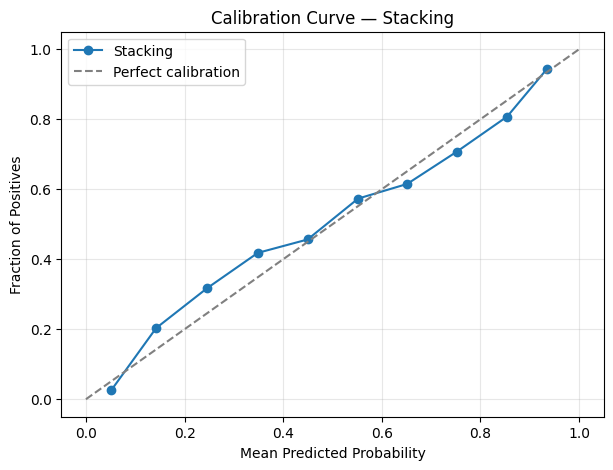

,brier_score,avg_cal_gap,verdict
0,0.1065,0.0392,✅ Well-calibrated


In [ ]:
# ============================================================================
# 10.2 CALIBRATION CHECK
# ============================================================================
print("\n=== 10.2 Calibration Check ===")
proba_test_cal = final_pipeline.predict_proba(X_test)[:, 1]

fraction_pos, mean_pred = calibration_curve(y_test, proba_test_cal, n_bins=10, strategy="uniform")
brier   = brier_score_loss(y_test, proba_test_cal)
avg_gap = np.abs(fraction_pos - mean_pred).mean()

plt.figure(figsize=(7, 5))
plt.plot(mean_pred, fraction_pos, marker="o", label=f"{final_model_name}")
plt.plot([0,1],[0,1],"--", color="gray", label="Perfect calibration")
plt.title(f"Calibration Curve — {final_model_name}")
plt.xlabel("Mean Predicted Probability"); plt.ylabel("Fraction of Positives")
plt.legend(); plt.grid(True, alpha=0.3)
plt.savefig(f"{ARTIFACT_DIR}calibration_v4.png", dpi=150, bbox_inches="tight")
plt.show()

cal_summary = pd.DataFrame([{
    "brier_score": round(brier, 4),
    "avg_cal_gap": round(avg_gap, 4),
    "verdict":     "✅ Well-calibrated" if avg_gap < 0.05
                   else "⚠ Cukup" if avg_gap < 0.10
                   else "❌ Poorly calibrated",
}])
display(cal_summary)

**Calibration Check — Stacking**

Kurva kalibrasi mengukur seberapa jujur probabilitas yang dikeluarkan model — apakah ketika model mengatakan "70% kemungkinan cancel", kenyataannya memang sekitar 70% booking tersebut benar-benar dibatalkan.

Hasil menunjukkan kurva Stacking mengikuti garis diagonal sempurna (*perfect calibration*) dengan sangat rapat di hampir seluruh rentang probabilitas. Ini dikonfirmasi oleh dua metrik kuantitatif:

- **Brier Score: 0.1065** — semakin mendekati 0 semakin baik. Nilai ini tergolong rendah dan menandakan prediksi probabilitas secara keseluruhan akurat
- **Average Calibration Gap: 0.0392** — rata-rata selisih antara probabilitas prediksi dan frekuensi aktual hanya ~4%, yang termasuk sangat kecil

Implikasi praktisnya signifikan: probabilitas yang dihasilkan model dapat digunakan **langsung sebagai ukuran risiko bisnis**, bukan sekadar label biner "cancel/tidak cancel". Staf reservasi bisa memprioritaskan tindakan berdasarkan besar kecilnya angka probabilitas — booking dengan probabilitas 85% jauh lebih mendesak ditangani dibanding yang 62%, dan model memang mencerminkan perbedaan risiko itu secara akurat.

---

# Kesimpulan & Rekomendasi — Modelling
## Hotel Booking Cancellation Prediction

---

## A. Kesimpulan

### 1. Kesimpulan Model

**Data & Kondisi Imbalanced**
- Dataset pemodelan terdiri dari **85.931 booking** dengan distribusi target moderat imbalanced: **72.21% tidak dibatalkan** dan **27.79% dibatalkan**
- Kondisi imbalanced ditangani tanpa oversampling — cukup dengan optimasi threshold dan pemilihan metrik yang tepat
- Metrik utama yang digunakan adalah **F0.5 Score** yang memprioritaskan presisi, karena biaya false positive (€700/intervensi sia-sia) dan false negative (€300/kamar kosong) keduanya signifikan secara bisnis

**Model Terbaik**
- Dari 13 model yang diuji dalam dua skema (tanpa dan dengan class weight), **Stacking Classifier** terpilih sebagai model terbaik dengan **threshold keputusan 0.6**
- Stacking menggabungkan tiga base learner — LightGBM, XGBoost, dan CatBoost — yang masing-masing menangkap pola berbeda, kemudian dikombinasikan oleh meta learner untuk menghasilkan prediksi final yang lebih robust

**Hasil Performa Model**

| Metrik | Nilai |
|--------|-------|
| F0.5 Score | **0.7415** |
| Precision | **78.49%** |
| Recall | **60.73%** |
| Accuracy | **84.46%** |
| AUC-ROC | **0.9144** |
| AUC-PR | **0.8043** |
| CV Stability (5-fold Mean) | **0.7337 ± 0.0049** ✅ |

**Interpretasi Hasil**
- Dari 7.163 booking yang benar-benar dibatalkan, model berhasil mendeteksi **4.350 kasus (TP)** dengan hanya **1.192 false alarm (FP)**
- Rasio FP/TP sebesar **0.27** — setiap 1 prediksi cancel yang benar, hanya ada 0.27 intervensi sia-sia
- Kalibrasi model tergolong **well-calibrated** (avg gap 0.039), artinya probabilitas yang dikeluarkan model dapat dipercaya sebagai ukuran risiko nyata

**Dampak Finansial**
- Tanpa model: biaya oportunitas mencapai **€2.148.900** dari seluruh pembatalan yang tidak terantisipasi
- Dengan model: total biaya turun menjadi **€1.678.300**
- **Penghematan: €470.600 (21.9%)** hanya dari satu periode data uji

**Validasi Kelayakan Model**
- **CV Stability:** Performa model konsisten di seluruh 5 fold dengan Mean F0.5 = 0.7337 dan Std = 0.0049 — selisih fold terbaik dan terburuk hanya 0.0119, membuktikan model tidak bergantung pada subset data tertentu
- **Generalisasi:** Gap OOF vs Test sebesar **-0.0078** (Test sedikit lebih tinggi dari OOF) adalah sinyal positif — model tidak overfit dan justru sedikit lebih baik pada data yang belum pernah dilihat sama sekali
- **Kalibrasi:** Brier Score **0.1065** dan Average Calibration Gap **0.0392** mengonfirmasi status **well-calibrated** — probabilitas yang dikeluarkan model mencerminkan risiko nyata, bukan sekadar angka relatif. Ketika model memprediksi 70% kemungkinan cancel, sekitar 70% booking tersebut memang benar-benar dibatalkan
- **Kesimpulan Validasi:** Berdasarkan tiga dimensi pengujian — stabilitas lintas fold, generalisasi ke data baru, dan akurasi kalibrasi probabilitas — model **dinyatakan layak untuk digunakan** dalam lingkungan produksi dengan ekspektasi performa yang dapat diprediksi dan dipercaya
---

### 2. Kesimpulan Bisnis

**Tingkat Pembatalan**
- Cancel rate keseluruhan berada di **27.79%** — hampir 1 dari 3 booking berakhir batal, angka yang sangat tinggi untuk industri perhotelan
- **City Hotel** memiliki cancel rate lebih tinggi **(30.32%)** dibanding **Resort Hotel (23.80%)**, menunjukkan perbedaan profil risiko yang signifikan antar properti

**Negara Asal Tamu (SHAP Mean |SHAP| = 0.9272 — tertinggi)**
- `country_grouped` adalah sinyal risiko terbesar yang tersedia sejak hari pertama booking masuk
- Negara dengan cancel rate tinggi: **Portugal 36.21%**, **Brasil 36.44%**, **Italia 35.16%**
- Negara dengan cancel rate rendah: **Inggris 19.13%**, **Jerman 19.63%**, **Prancis 19.70%**
- Negara asal tamu dapat digunakan langsung sebagai penentu level intervensi yang diperlukan — tanpa perlu menunggu sinyal lain

**Agen Perjalanan (Gain = 12.4% — tertinggi)**
- `agent` adalah fitur paling informatif bagi model dalam membedakan booking berisiko dan tidak
- Pola pembatalan sangat berbeda antar agen — bukan semata soal Online TA vs Direct, melainkan **agen spesifik mana** yang secara konsisten mengirim tamu berkomitmen rendah
- Beberapa agen mendominasi daftar pembatalan, sementara yang lain nyaris tidak pernah berkontribusi pada cancel

**Interaksi Lead Time × Tamu Transient (SHAP = 0.3941, Gain = 10.6%)**
- Tamu Transient yang memesan jauh hari adalah **kombinasi risiko tertinggi** — bukan lead time panjang saja, bukan Transient saja, melainkan interaksi keduanya
- Cancel rate tamu dengan lead time **0–7 hari hanya 9.77%**, sementara **>180 hari mencapai 39.89%**
- Fitur rekayasa `lead_x_transient` terbukti jauh lebih informatif dibanding kedua komponen aslinya secara terpisah

**Tamu yang Meminta Parkir Hampir Tidak Pernah Membatalkan (SHAP = 0.5478 — arah menurunkan cancel)**
- `parking_bin_has_parking` adalah salah satu fitur **protektif terkuat** dalam model
- Tamu yang sudah merencanakan membawa kendaraan berarti telah memikirkan rute, waktu, dan logistik perjalanan secara konkret — komitmen fisik ini tercermin dalam perilaku booking yang jauh lebih stabil
- Informasi parkir adalah sinyal loyalitas yang **murah, mudah dikumpulkan, dan sangat prediktif**

**Tidak Ada Deposit = Tidak Ada Konsekuensi**
- `no_commitment` masuk top 10 feature importance (gain 3.6%) dan konsisten mendorong probabilitas cancel ke atas
- **98.67% booking adalah No Deposit** — ketiadaan konsekuensi finansial membuat tamu bebas membatalkan kapan saja tanpa kerugian apapun di pihak mereka

**Riwayat Pembatalan Masa Lalu adalah Prediktor Paling Reliable**
- `prev_cancel_bin_never` muncul kuat di SHAP beeswarm — tamu yang **pernah membatalkan bahkan satu kali** memiliki probabilitas cancel yang meningkat signifikan
- Riwayat tamu adalah informasi yang sudah dimiliki hotel dan bisa langsung dimanfaatkan untuk segmentasi risiko tanpa biaya tambahan

---


---

## B. Rekomendasi

### 1. Rekomendasi Model

- **Deployment dengan monitoring bulanan oleh Data/IT Team:** Integrasikan model ke sistem reservasi dan tetapkan ambang batas performa minimum F0.5 ≥ 0.72. Setiap bulan, Data/IT Team mengevaluasi performa menggunakan data aktual bulan berjalan. Jika F0.5 turun lebih dari 5% dari baseline (0.7415), retraining dijadwalkan dalam maksimal 2 minggu menggunakan data 12 bulan terakhir

- **Retraining berkala setiap 6 bulan oleh Data/IT Team:** Retraining pertama dijadwalkan pada bulan ke-6 setelah deployment menggunakan minimal 12 bulan data terbaru. Target setiap siklus: F0.5 tidak turun lebih dari 3% dari hasil retraining sebelumnya. Setiap siklus didokumentasikan dan hasilnya dilaporkan kepada Hotel Management dalam bentuk ringkasan performa 1 halaman sebagai dasar evaluasi kebijakan pricing dan risk control

- **Klarifikasi kelengkapan data historis paling lambat 1 bulan sebelum retraining pertama:** Data yang tersedia hanya mencakup Juli–Desember 2015 dan Januari–Agustus 2017. Data/IT Team mengonfirmasi kepada Hotel Management apakah bulan-bulan yang hilang memang tidak ada tamu atau data tidak tercatat di sistem — dengan target jawaban dalam 2 minggu sejak permintaan diajukan. Jika data tidak tercatat, Hotel Management menetapkan deadline pengiriman data lengkap kepada Data/IT Team minimal 30 hari sebelum jadwal retraining, agar model tidak belajar dari pola seasonality yang bias terutama untuk periode winter dan autumn yang justru memiliki cancel rate terendah

- **Pengembangan fitur interaksi untuk iterasi berikutnya:** Uji fitur baru `country_grouped × no_commitment` yang menggabungkan dua sinyal risiko terkuat. Hipotesis: tamu dari negara dengan cancel rate tinggi yang juga tidak membayar deposit menghasilkan profil risiko jauh lebih ekstrem dari sekadar penjumlahan keduanya. Target peningkatan F0.5 ≥ 0.76 dalam dua siklus retraining berikutnya (12 bulan ke depan)

- **Eksplorasi threshold berbasis segmen hotel dalam 3 bulan pertama deployment:** Threshold 0.6 optimal secara global, namun City Hotel dan Resort Hotel memiliki cancel rate berbeda ~6.5 percentage point. Dalam 3 bulan pertama, Data/IT Team menguji threshold terpisah per properti pada data historis dan menargetkan peningkatan F0.5 minimal 0.01 per properti dibanding threshold global. Hasil pengujian diserahkan kepada Revenue Manager dalam bentuk laporan perbandingan performa paling lambat akhir bulan ke-3, sebagai dasar keputusan apakah kalibrasi per properti layak diimplementasikan

---

### 2. Rekomendasi Bisnis

- **Reservation Team: Bangun sistem triase risiko harian berbasis output model** — Setiap pagi, Reservation Team menerima daftar booking dengan probabilitas cancel ≥ 60% yang diurutkan berdasarkan nilai revenue. Untuk 20 booking teratas, lakukan konfirmasi aktif via telepon atau email dalam 24 jam. Target konversi 15% booking berisiko menjadi tamu terealisasi — dengan rata-rata revenue booking yang dibatalkan mencapai €479, mengamankan 100 booking per bulan setara penambahan >€47.000 revenue bulanan

- **Reservation Team: Prioritaskan respons konfirmasi untuk tamu di waiting list 8–30 hari** — Tamu yang menunggu konfirmasi 8–30 hari memiliki cancel rate 50.35% — tertinggi dari semua segmen, bahkan melampaui tamu dengan lead time >1 tahun. Reservation Team menetapkan SLA internal: setiap tamu di waiting list mendapat update status dalam maksimal 48 jam. Target dalam 3 bulan pertama: turunkan cancel rate segmen waiting list 8–30 hari dari 50.35% menjadi di bawah 40% melalui komunikasi proaktif yang konsisten

- **Revenue Manager: Terapkan deposit progresif khusus untuk Transient + lead time panjang dalam 1 kuartal pertama** — Booking Transient Online TA dengan lead time 91–180 hari diwajibkan deposit 20% non-refundable; lead time >180 hari diwajibkan 30%. Kebijakan ini tidak berlaku untuk Corporate dan Offline TA/TO yang cancel rate-nya sudah rendah agar tidak mengganggu hubungan dengan mitra stabil. Implementasi dimulai dari City Hotel, dievaluasi dampaknya setelah satu kuartal penuh dan dilaporkan ke Hotel Management

- **Revenue Manager & Reservation Team: Tangani segmen Groups dengan kebijakan kontrak yang lebih ketat** — Groups adalah segmen paling tidak efisien: lead time terpanjang (149 hari), cancel rate 28.1%, revenue terendah (€261/booking), dan hampir tidak ada special request (0.17). Setiap booking Groups di atas 10 kamar wajib disertai kontrak tertulis dengan klausul penalti pembatalan dan deposit minimal 30% yang dikomunikasikan saat negosiasi awal. Reservation Team melaporkan realisasi kepatuhan kontrak Groups kepada Revenue Manager setiap bulan selama 6 bulan pertama implementasi

- **Revenue Manager: Audit portofolio agen distribusi dalam 90 hari** — Petakan 50 agen dengan volume tertinggi berdasarkan cancel rate historis. Agen dengan cancel rate >40% dan volume signifikan dinegosiasikan ulang dalam bentuk kebijakan deposit lebih ketat atau penyesuaian komisi. Agen dengan cancel rate rendah dan revenue per booking tinggi diberikan insentif prioritas. Hasil audit diserahkan ke Hotel Management sebagai dasar keputusan kebijakan distribusi paling lambat akhir bulan ke-3

- **Operasional Hotel: Tambahkan pertanyaan parkir dan preferensi kamar di halaman konfirmasi Online TA** — Karena tamu yang meminta parkir hampir tidak pernah membatalkan, setiap tamu yang merespons secara otomatis meningkatkan komitmen psikologis terhadap reservasinya. Ini adalah intervensi tanpa biaya tambahan yang langsung meminimalkan false positive dan mengurangi potensi konflik alokasi kamar. Target dalam 3 bulan: naikkan rata-rata special request dari 0.9 menjadi ≥ 1.5 per booking Online TA

- **Hotel Management: Segmentasi kebijakan berdasarkan negara asal tamu** — Tamu dari negara dengan cancel rate >35% (Portugal, Brasil, Italia) diarahkan ke alur booking dengan konfirmasi tambahan dan penawaran deposit insentif sejak booking masuk. Tamu dari negara dengan cancel rate <20% (Inggris, Jerman, Prancis) diperlakukan dengan alur standar tanpa gesekan tambahan. Kebijakan ini ditinjau ulang setiap 6 bulan bersama Data/IT Team menggunakan data cancel rate terbaru

- **Hotel Management: Bangun program loyalitas khusus untuk repeated guest dalam 6 bulan ke depan** — Tamu berulang memiliki cancel rate hanya 8.26% dibanding 28.53% untuk first-time guest — selisih lebih dari 20 percentage point. Hotel Management merancang program loyalitas sederhana (priority check-in, room upgrade, atau voucher F&B) yang secara aktif mendorong tamu untuk kembali memesan langsung. Target dalam 1 tahun pertama: naikkan proporsi repeated guest minimal 5% dari baseline dan pantau dampaknya terhadap penurunan cancel rate keseluruhan